## 1.0 Environment Set Up 

In [2]:
import pandas as pd
from mappings import MAPPINGS
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy.stats import chi2_contingency

# ----------------- Utility Functions -----------------
def sanitize_filename(name):
    """Replace unsafe characters in filenames."""
    return re.sub(r'[^\w\-_. ]', '_', name)

def save_plot(fig, folder, filename):
    """Save plot to folder with safe filename."""
    os.makedirs(folder, exist_ok=True)
    safe_name = sanitize_filename(filename)
    fig.savefig(os.path.join(folder, safe_name))
    

# Create directories for plots
os.makedirs("eda_plots/distributions", exist_ok=True)
os.makedirs("eda_plots/outliers", exist_ok=True)
os.makedirs("eda_plots/class_balance", exist_ok=True)
os.makedirs("eda_plots/correlation", exist_ok=True)
os.makedirs("eda_plots/categorical", exist_ok=True)

## 2.0 Preprocessing and Understanding

### 2.1 Dataset Loading

In [3]:
df = pd.read_csv("Original-dataset.csv")
print(f"Dataset loaded. Shape: {df.shape}")

Dataset loaded. Shape: (4424, 35)


### 2.2 Mapping

In [4]:
COLUMN_MAPPING = {
    'Marital status': 'Marital Status',
    'Nacionality': 'Nationality',  # CSV has typo
    'Application mode': 'Application Mode', 
    'Course': 'Course Name',
    'Previous qualification': 'Previous Qualification',
    "Mother's qualification": 'Parent Qualification',
    "Father's qualification": 'Parent Qualification',
    "Mother's occupation": 'Occupation',
    "Father's occupation": 'Occupation',
    'Gender': 'Gender',
    'Daytime/evening attendance': 'Attendance Regime'
}

for csv_col, mapping_key in COLUMN_MAPPING.items():
    if csv_col in df.columns and mapping_key in MAPPINGS:
        print(f"Mapping column: {csv_col} -> {mapping_key}")
        df[csv_col] = df[csv_col].map(MAPPINGS[mapping_key]).fillna(df[csv_col]).astype(str)
    elif csv_col in df.columns:
        print(f"Warning: No mapping found for {csv_col}")

binary_columns = [
    'Displaced', 'Educational special needs', 'Debtor', 
    'Tuition fees up to date', 'Scholarship holder', 'International'
]

for col in binary_columns:
    if col in df.columns:
        df[col] = df[col].map({0: 'No', 1: 'Yes'}).fillna(df[col]).astype(str)

print("Applied mappings for categorical and binary columns.")

Mapping column: Marital status -> Marital Status
Mapping column: Application mode -> Application Mode
Mapping column: Course -> Course Name
Mapping column: Previous qualification -> Previous Qualification
Mapping column: Mother's qualification -> Parent Qualification
Mapping column: Father's qualification -> Parent Qualification
Mapping column: Mother's occupation -> Occupation
Mapping column: Father's occupation -> Occupation
Mapping column: Gender -> Gender
Mapping column: Daytime/evening attendance -> Attendance Regime
Applied mappings for categorical and binary columns.


## 3.0 Data Understanding

In [5]:
# DATA UNDERSTANDING
print("\n" + "="*80)
print("DATA UNDERSTANDING")
print("="*80)

# Quick overview
print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Column types
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nColumn Types:")
print(f"  - Numeric: {len(numeric_cols)}")
print(f"  - Categorical: {len(categorical_cols)}")

# Data types and missing values
print(f"\nColumn Details:")
print("-" * 80)
summary_df = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.values,
    'Non-Null': df.count().values,
    'Null': df.isnull().sum().values,
    'Null %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Unique': [df[col].nunique() for col in df.columns]
})
print(summary_df.to_string(index=False))

# Numeric summary statistics
if len(numeric_cols) > 0:
    print(f"\nNumeric Features - Summary Statistics:")
    print("-" * 80)
    print(df[numeric_cols].describe().round(2).to_string())

# Categorical features overview
if len(categorical_cols) > 0:
    print(f"\nCategorical Features - Unique Value Counts:")
    print("-" * 80)
    for col in categorical_cols:
        unique_count = df[col].nunique()
        print(f"  {col}: {unique_count} unique values")

# Target distribution
target_col = 'Target'
if target_col in df.columns:
    print(f"\nTarget Variable Distribution ('{target_col}'):")
    print("-" * 80)
    target_dist = pd.DataFrame({
        'Class': df[target_col].value_counts().index,
        'Count': df[target_col].value_counts().values,
        'Percentage': (df[target_col].value_counts(normalize=True) * 100).round(2).values
    })
    print(target_dist.to_string(index=False))

print("\n" + "="*80)


DATA UNDERSTANDING

Dataset Shape: 4,424 rows × 35 columns

Column Types:
  - Numeric: 18
  - Categorical: 17

Column Details:
--------------------------------------------------------------------------------
                                        Column    Type  Non-Null  Null  Null %  Unique
                                Marital status  object      4424     0     0.0       6
                              Application mode  object      4424     0     0.0      18
                             Application order   int64      4424     0     0.0       8
                                        Course  object      4424     0     0.0      17
                    Daytime/evening attendance  object      4424     0     0.0       2
                        Previous qualification  object      4424     0     0.0      17
                                   Nationality   int64      4424     0     0.0      21
                        Mother's qualification  object      4424     0     0.0      29
        

### 3.1 Missing and Duplicate Value Check

In [6]:
missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()
print("\nMissing Values Check")
print(missing_counts[missing_counts > 0] if total_missing > 0 else "No missing values found.")
print(f"Total missing values: {total_missing}")

duplicate_count = df.duplicated().sum()
print("\nDuplicate Check")
print(f"Total duplicates found: {duplicate_count}")


Missing Values Check
No missing values found.
Total missing values: 0

Duplicate Check
Total duplicates found: 0


### 3.2 Outlier Detection

In [7]:
# Outlier Detection using IQR
numeric_df = df.select_dtypes(include=['number'])
outlier_summary = []

for col in numeric_df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = round((outlier_count / len(df) * 100), 2)
    
    outlier_summary.append({
        "Feature": col,
        "Outlier Count": outlier_count,
        "Outlier %": outlier_pct,
        "Lower Bound": lower_bound.round(2),
        "Upper Bound": upper_bound.round(2)
    })
    
    if outlier_count > 0:
        print(f"\n{col}:")
        print(f"  Outliers detected: {outlier_count} ({outlier_pct}%)")
        print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Sample outlier values:")
        print(f"    {outliers[col].head(5).tolist()}")

# Summary table
print("\n" + "-" * 80)
print("Outlier Summary Table:")
print("-" * 80)
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

total_outliers = sum([item['Outlier Count'] for item in outlier_summary])
print(f"\nTotal outlier records across all features: {total_outliers}")
print(f"Features with outliers: {sum([1 for item in outlier_summary if item['Outlier Count'] > 0])}/{len(numeric_df.columns)}")
print("="*80)


Application order:
  Outliers detected: 541 (12.23%)
  Bounds: [-0.50, 3.50]
  Sample outlier values:
    [5, 5, 4, 4, 4]

Nationality:
  Outliers detected: 110 (2.49%)
  Bounds: [1.00, 1.00]
  Sample outlier values:
    [15, 3, 14, 14, 12]

Age at enrollment:
  Outliers detected: 441 (9.97%)
  Bounds: [10.00, 34.00]
  Sample outlier values:
    [45, 50, 37, 43, 55]

Curricular units 1st sem (credited):
  Outliers detected: 577 (13.04%)
  Bounds: [0.00, 0.00]
  Sample outlier values:
    [2, 2, 3, 3, 2]

Curricular units 1st sem (enrolled):
  Outliers detected: 424 (9.58%)
  Bounds: [2.00, 10.00]
  Sample outlier values:
    [0, 0, 0, 0, 0]

Curricular units 1st sem (evaluations):
  Outliers detected: 158 (3.57%)
  Bounds: [0.00, 16.00]
  Sample outlier values:
    [17, 18, 19, 21, 18]

Curricular units 1st sem (approved):
  Outliers detected: 180 (4.07%)
  Bounds: [-1.50, 10.50]
  Sample outlier values:
    [18, 21, 11, 13, 11]

Curricular units 1st sem (grade):
  Outliers detected: 

### 3.3 Outlier-Target Relationship Analysis

In [8]:
numeric_cols_viz = df.select_dtypes(include=['number']).columns.tolist()
for col in numeric_cols_viz:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Create outlier flag
    df_temp = df.copy()
    df_temp['is_outlier'] = ((df_temp[col] < lower_bound) | (df_temp[col] > upper_bound))
    
    # Contingency table
    contingency_table = pd.crosstab(df_temp['is_outlier'], df_temp[target_col])
    
    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    print(f"\n{col}:")
    print("-" * 60)
    print("Outlier vs Target Distribution:")
    print(contingency_table)
    print(f"\nChi-square statistic: {chi2:.4f}")
    print(f"P-value: {p:.4f}")
    
    if p < 0.05:
        print("✓ Significant relationship between outliers and target (p < 0.05)")
    else:
        print("✗ No significant relationship between outliers and target")

print("\n" + "="*80)


Application order:
------------------------------------------------------------
Outlier vs Target Distribution:
Target      Dropout  Enrolled  Graduate
is_outlier                             
False          1279       721      1883
True            142        73       326

Chi-square statistic: 26.5947
P-value: 0.0000
✓ Significant relationship between outliers and target (p < 0.05)

Nationality:
------------------------------------------------------------
Outlier vs Target Distribution:
Target      Dropout  Enrolled  Graduate
is_outlier                             
False          1389       770      2155
True             32        24        54

Chi-square statistic: 1.2799
P-value: 0.5273
✗ No significant relationship between outliers and target

Age at enrollment:
------------------------------------------------------------
Outlier vs Target Distribution:
Target      Dropout  Enrolled  Graduate
is_outlier                             
False          1184       742      2057
True      

### 3.4 Chi-square Test: Categorical vs Target

In [9]:
chi_square_results = []

categorical_cols_viz = df.select_dtypes(include=['object']).columns.tolist()
target_col = 'Target'

# Remove target from categorical columns
categorical_cols_no_target = [col for col in categorical_cols_viz if col != target_col]

for col in categorical_cols_no_target:
    contingency = pd.crosstab(df[col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    chi_square_results.append({
        'Feature': col,
        'Chi-square': chi2.round(4),
        'P-value': p,
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

chi_square_df = pd.DataFrame(chi_square_results)
chi_square_df = chi_square_df.sort_values('P-value')

print(chi_square_df.to_string(index=False))

print("\n" + "-" * 80)
significant_count = (chi_square_df['Significant'] == 'Yes').sum()
print(f"Significant features (p < 0.05): {significant_count}/{len(chi_square_df)}")
print("="*80)

                   Feature  Chi-square       P-value Significant
   Tuition fees up to date    823.5527 1.471628e-179         Yes
                    Course    558.2845  2.316571e-97         Yes
        Scholarship holder    409.9431  9.593930e-90         Yes
          Application mode    466.5137  1.964657e-77         Yes
                    Debtor    259.3332  4.858552e-57         Yes
                    Gender    233.2664  2.222480e-51         Yes
       Mother's occupation    291.9217  1.630859e-31         Yes
    Previous qualification    219.6807  7.160305e-30         Yes
    Mother's qualification    217.9521  5.823844e-21         Yes
    Father's qualification    225.0008  3.175007e-19         Yes
       Father's occupation    264.4998  4.515439e-19         Yes
                 Displaced     57.7542  2.876311e-13         Yes
            Marital status     63.4385  8.054280e-10         Yes
Daytime/evening attendance     28.7399  5.743834e-07         Yes
             Internationa

### 3.5 Numeric Distributions - Histograms

<Figure size 1400x1000 with 0 Axes>

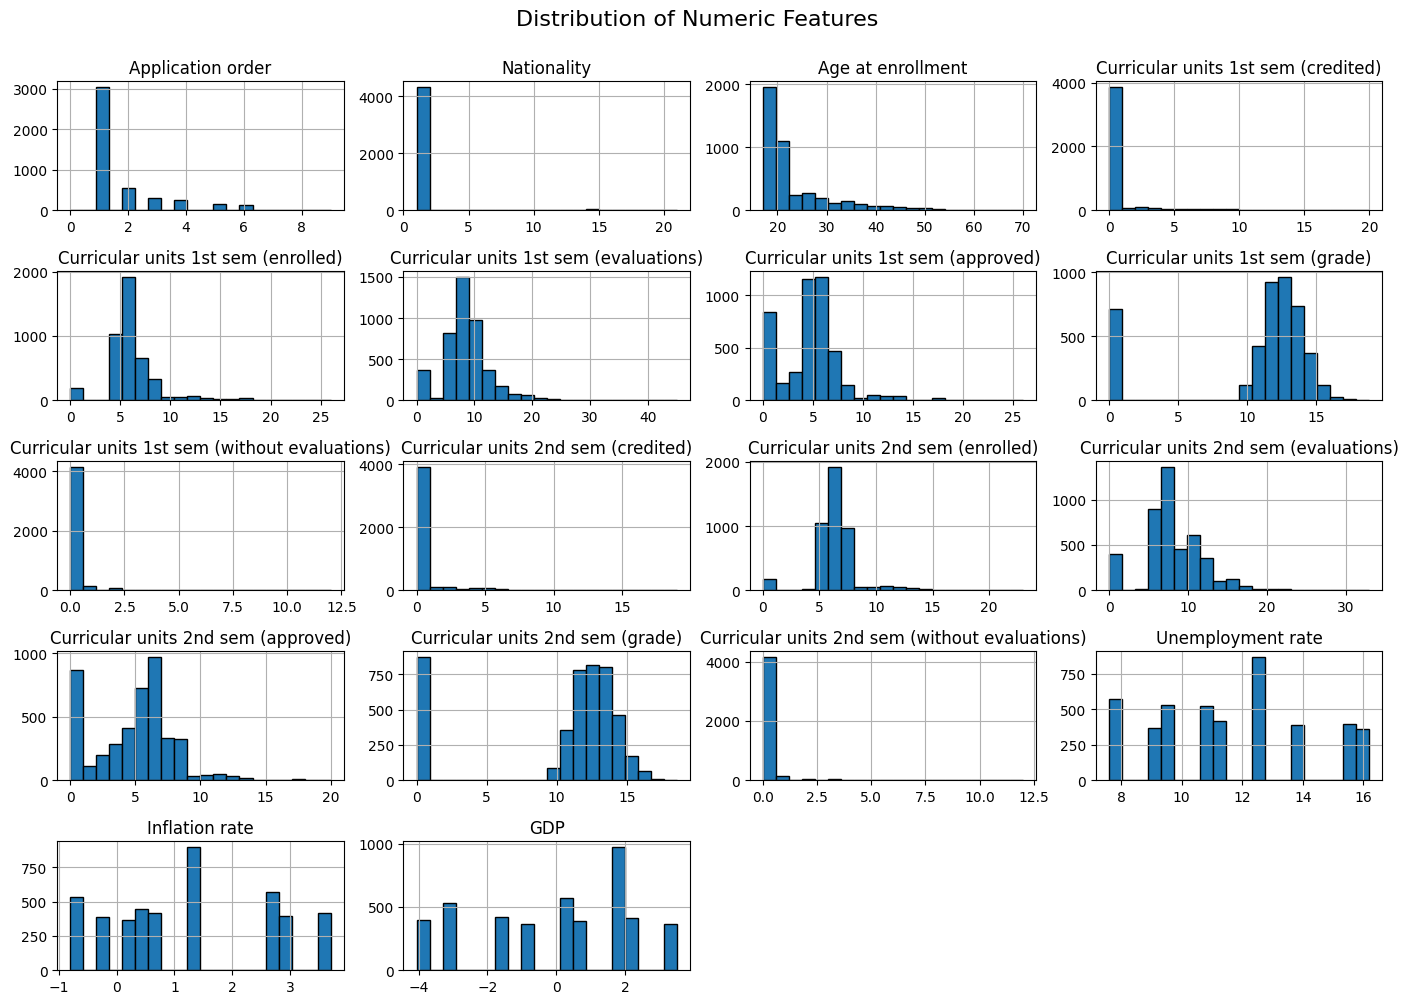

✓ Numeric distributions saved and displayed


In [10]:
numeric_cols_viz = df.select_dtypes(include=['number']).columns.tolist()

if len(numeric_cols_viz) > 0:
    fig = plt.figure(figsize=(14, 10))
    df[numeric_cols_viz].hist(bins=20, figsize=(14, 10), edgecolor='black')
    plt.suptitle('Distribution of Numeric Features', fontsize=16, y=1.00)
    plt.tight_layout()
    save_plot(fig, "eda_plots/distributions", "numeric_histograms.png")
    plt.show()  # Display in notebook
    print("✓ Numeric distributions saved and displayed")
else:
    print("No numeric columns available for histograms")

### 3.6 Correlation Heatmap

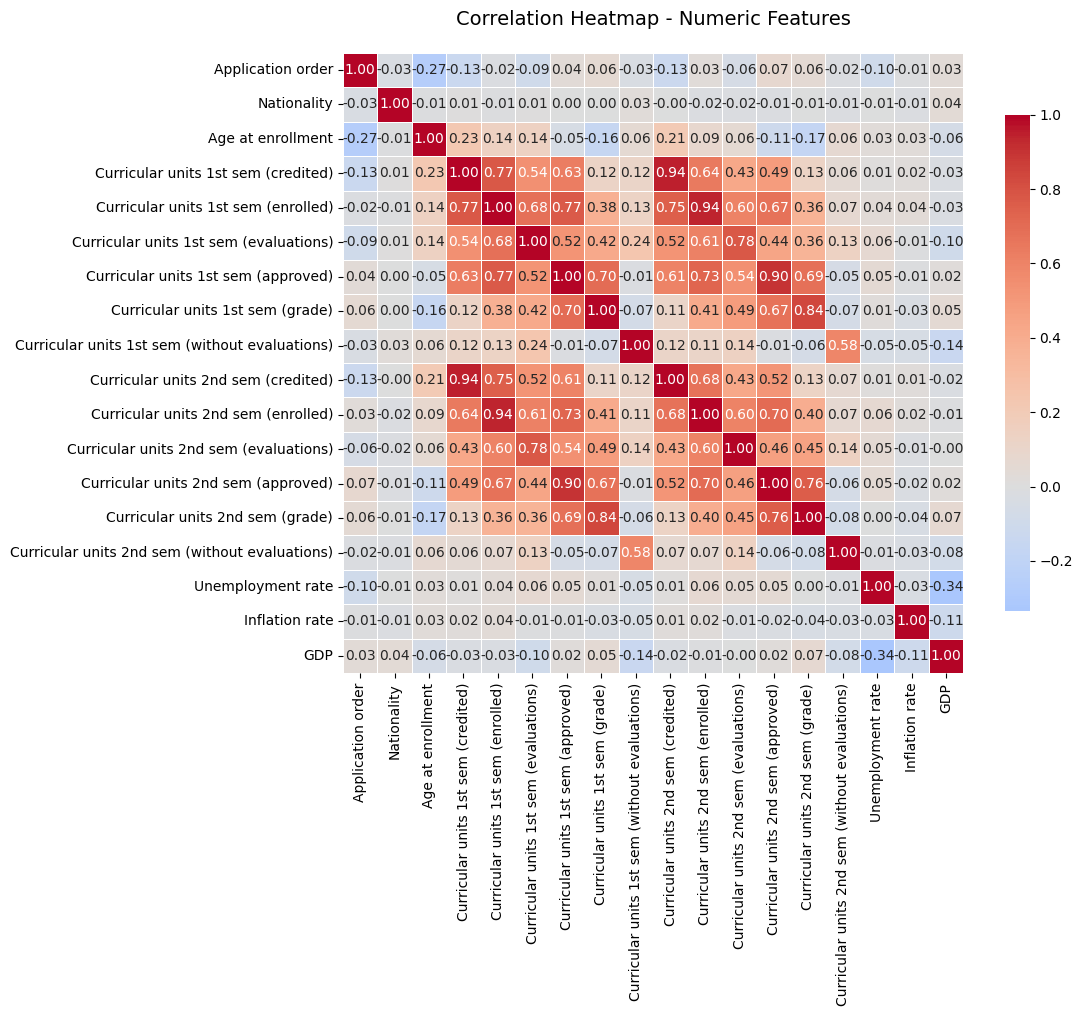


Highly Correlated Feature Pairs (|correlation| > 0.7):
--------------------------------------------------------------------------------
                             Feature 1                              Feature 2  Correlation
   Curricular units 1st sem (credited)    Curricular units 1st sem (enrolled)     0.774344
   Curricular units 1st sem (credited)    Curricular units 2nd sem (credited)     0.944811
   Curricular units 1st sem (enrolled)    Curricular units 1st sem (approved)     0.769083
   Curricular units 1st sem (enrolled)    Curricular units 2nd sem (credited)     0.753747
   Curricular units 1st sem (enrolled)    Curricular units 2nd sem (enrolled)     0.942627
Curricular units 1st sem (evaluations) Curricular units 2nd sem (evaluations)     0.778863
   Curricular units 1st sem (approved)    Curricular units 2nd sem (enrolled)     0.733772
   Curricular units 1st sem (approved)    Curricular units 2nd sem (approved)     0.904002
      Curricular units 1st sem (grade)      

In [11]:
if len(numeric_cols_viz) > 1:
    # Calculate correlation
    correlation_matrix = df[numeric_cols_viz].corr()
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap="coolwarm", 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    ax.set_title("Correlation Heatmap - Numeric Features", fontsize=14, pad=20)
    plt.tight_layout()
    save_plot(fig, "eda_plots/correlation", "numeric_heatmap.png")
    plt.show()  # Display in notebook
    
    # Print highly correlated pairs
    print("\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
    print("-" * 80)
    high_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                high_corr.append({
                    'Feature 1': correlation_matrix.columns[i],
                    'Feature 2': correlation_matrix.columns[j],
                    'Correlation': correlation_matrix.iloc[i, j]
                })
    
    if high_corr:
        high_corr_df = pd.DataFrame(high_corr)
        print(high_corr_df.to_string(index=False))
    else:
        print("No highly correlated pairs found")
    
    print("\n✓ Correlation heatmap saved and displayed")
else:
    print("Not enough numeric columns for correlation analysis")

### 3.7 Categorical Features - Top 5 Categories

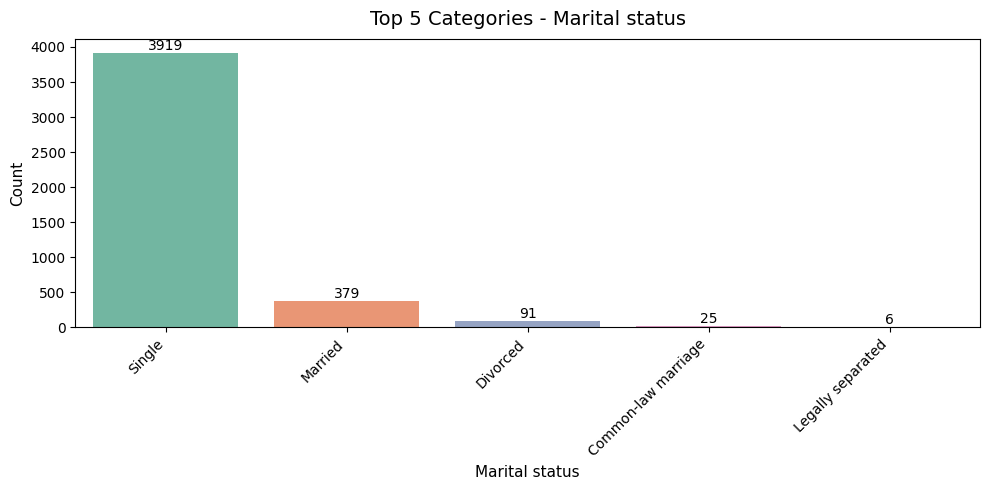

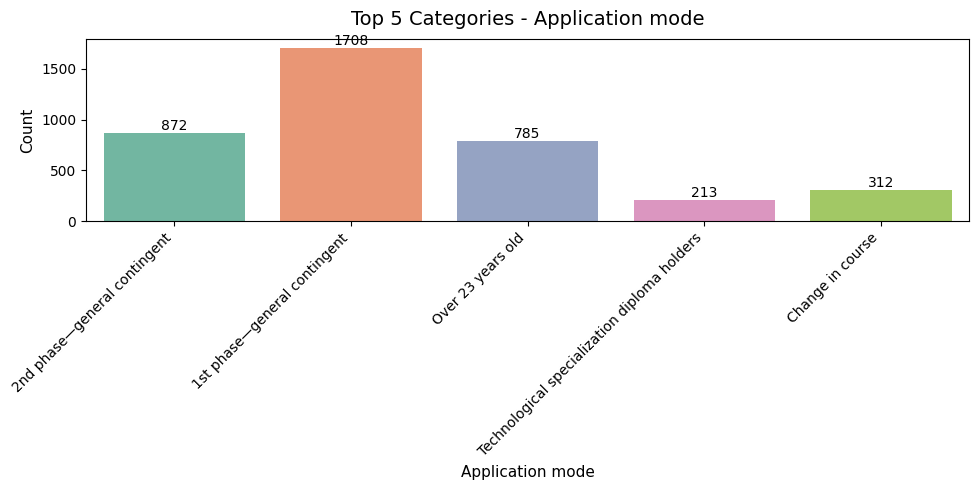

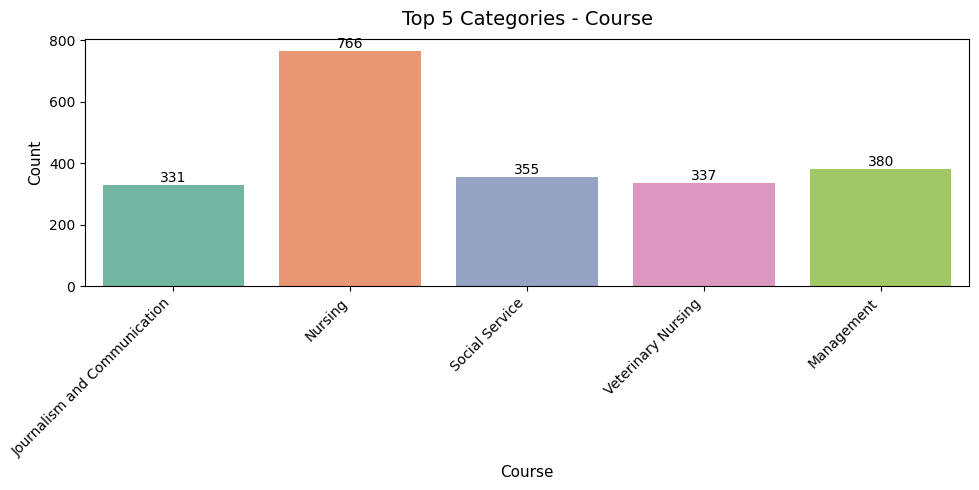

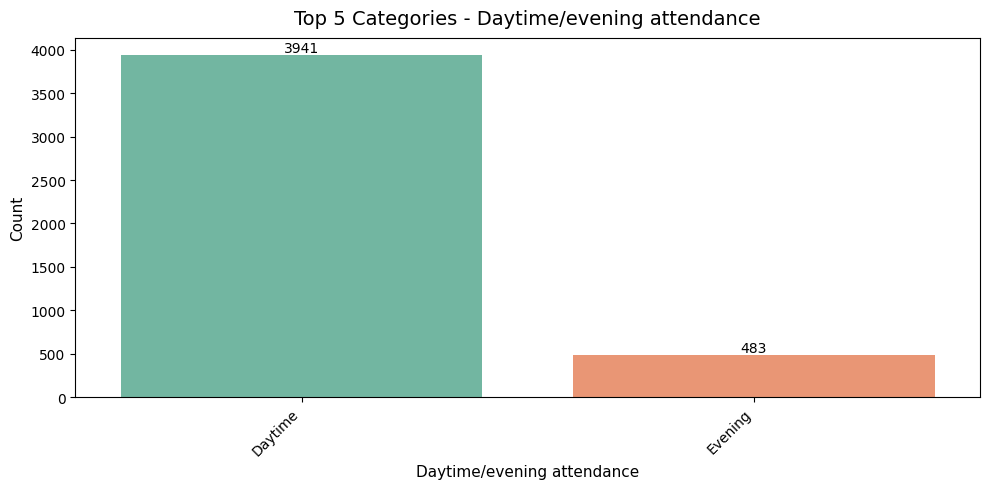

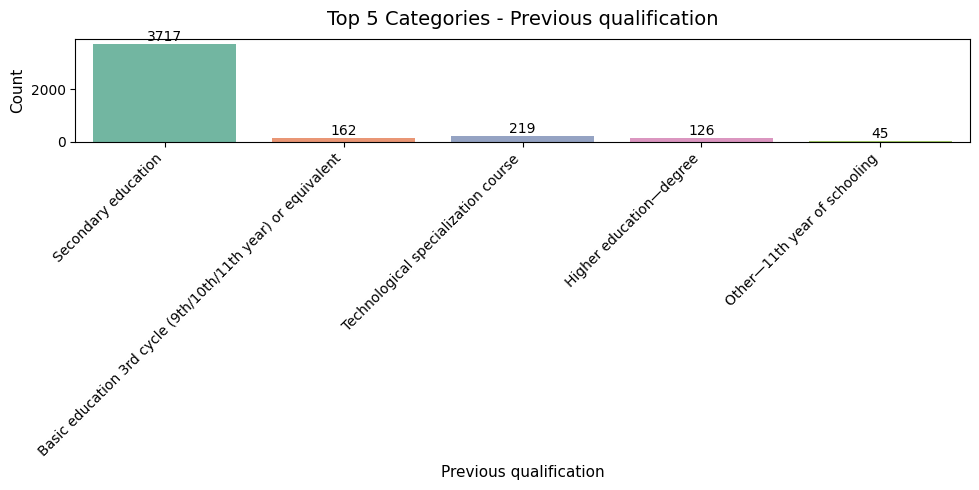

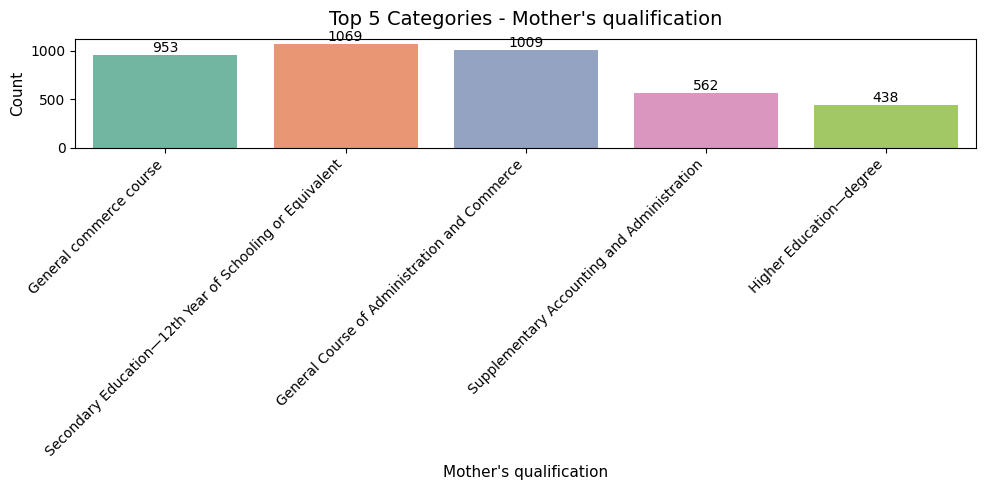

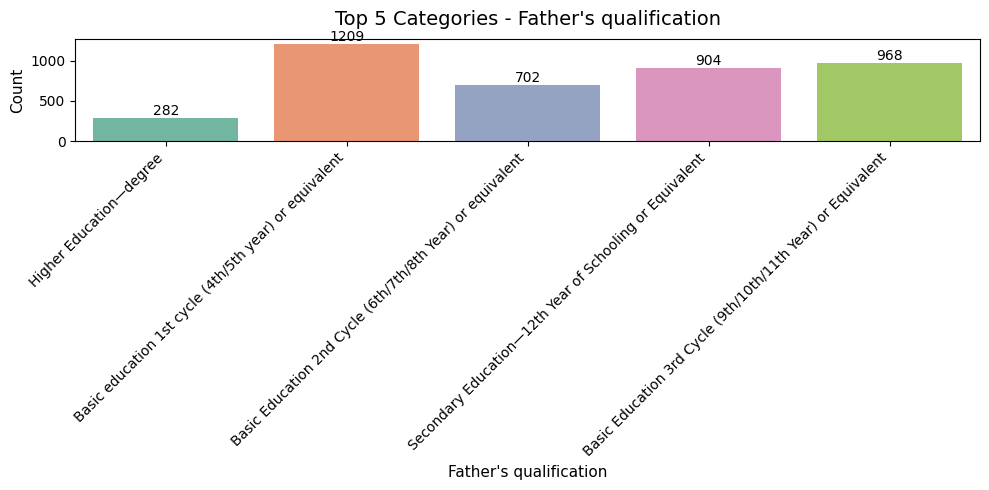

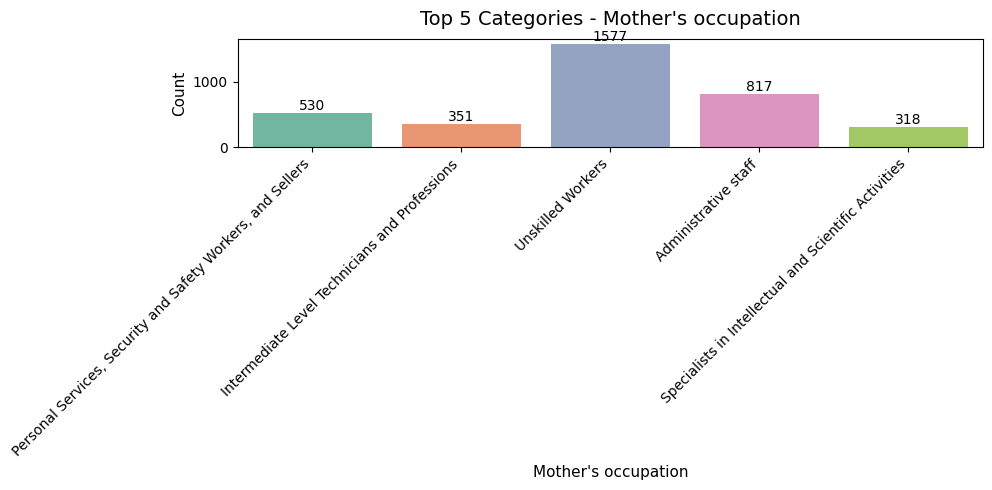

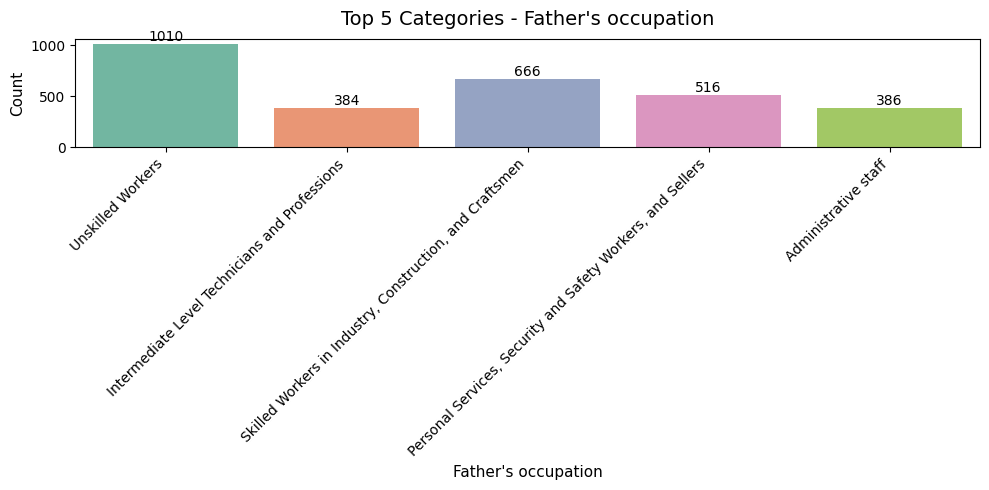

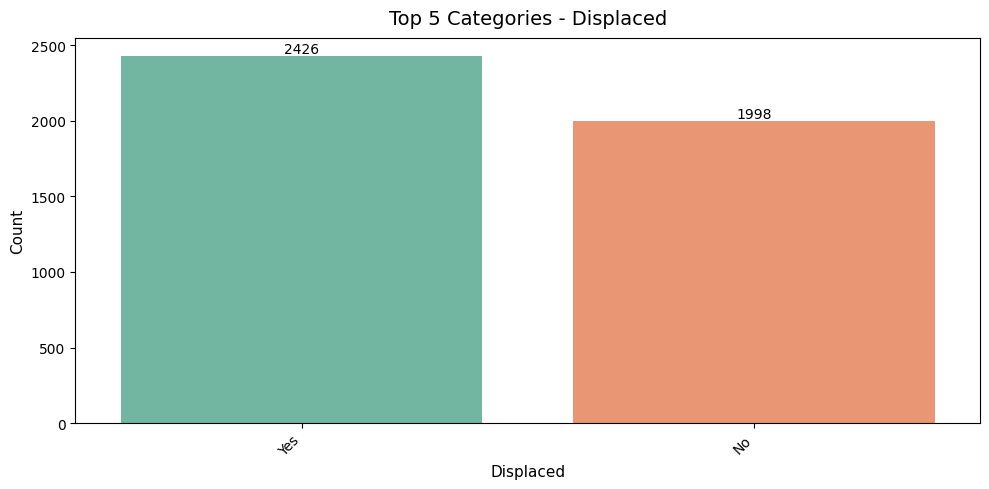

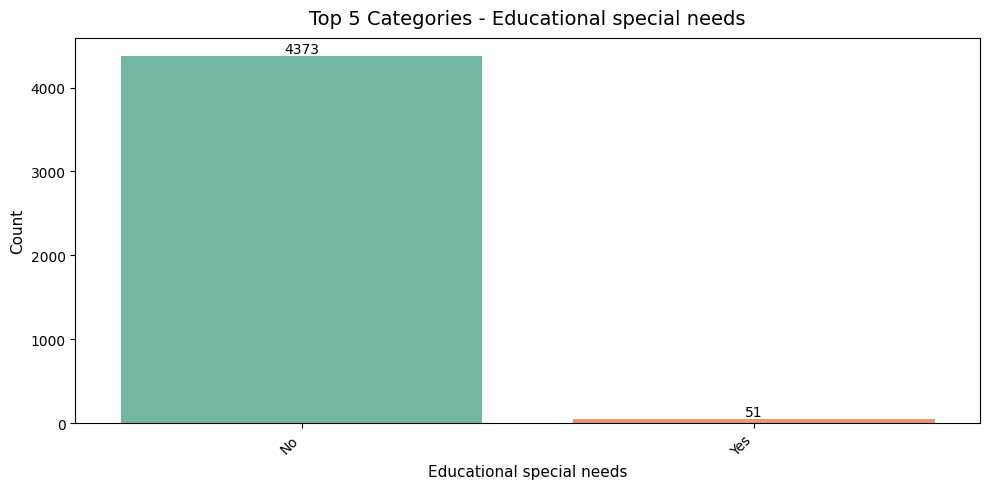

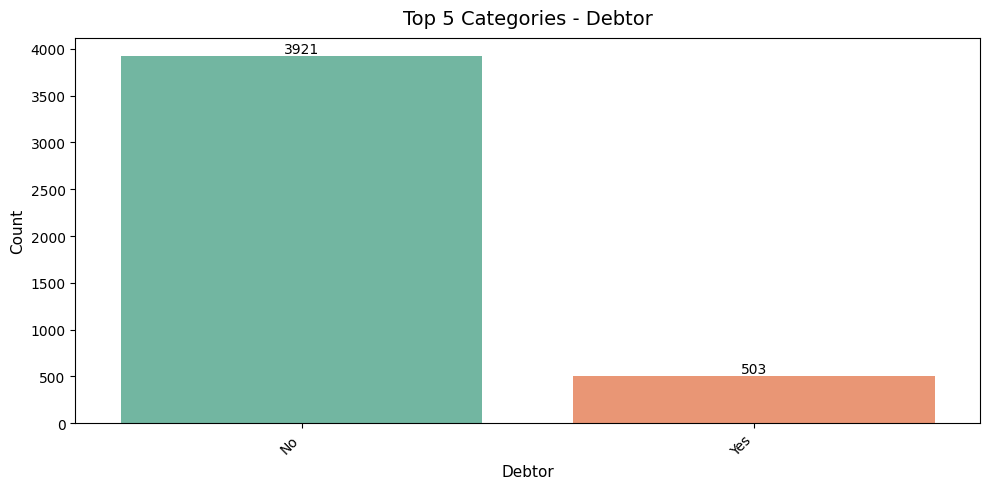

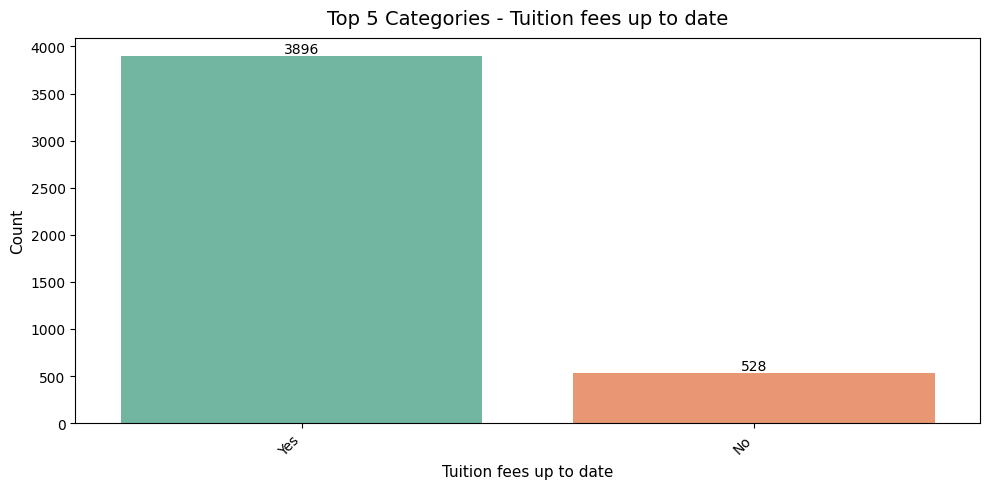

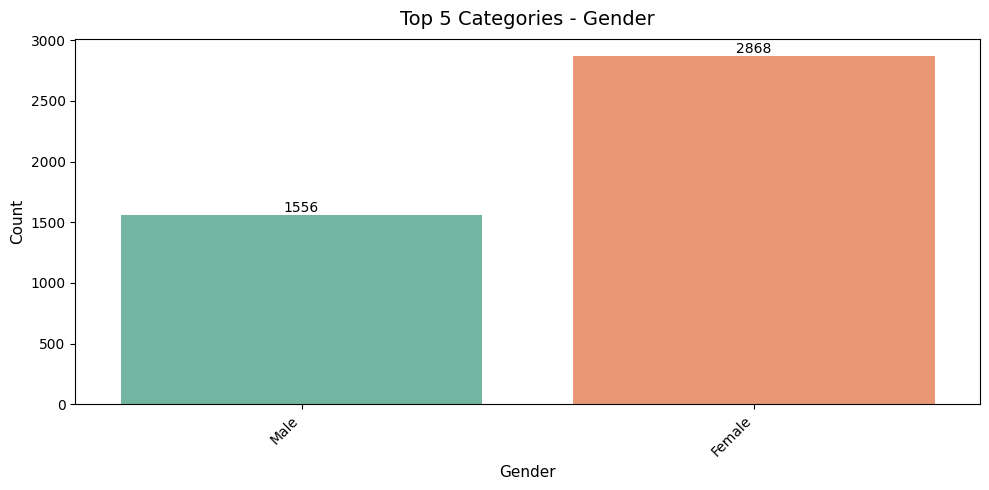

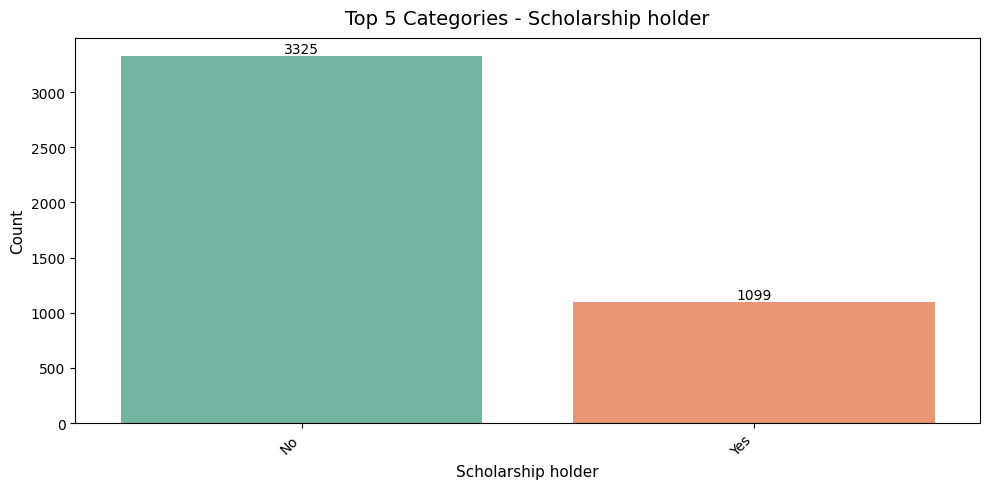

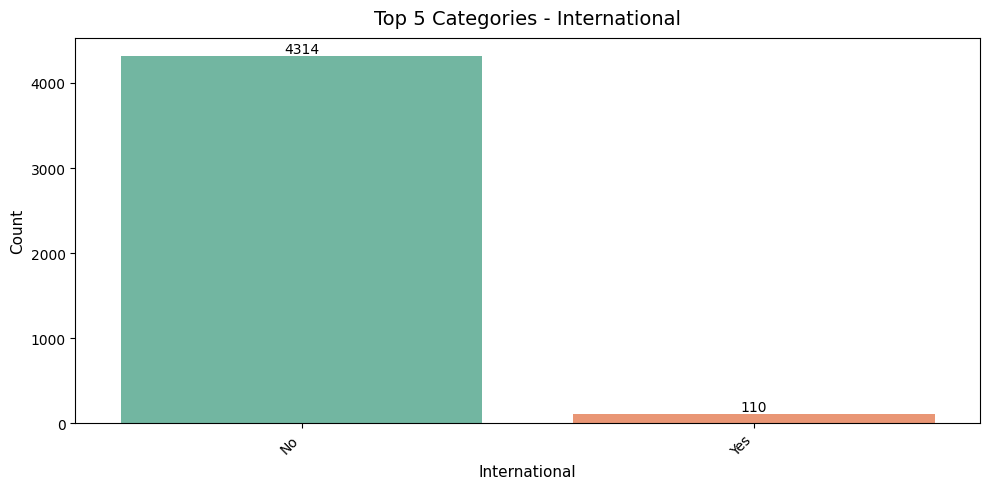


✓ Saved and displayed 16 categorical distribution plots


In [12]:
for col in categorical_cols_no_target:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Get top 5 categories
    top_categories = df[col].value_counts().nlargest(5).index
    filtered_df = df[df[col].isin(top_categories)]
    
    # Create countplot
    sns.countplot(data=filtered_df, x=col, hue=col, palette="Set2", 
                 dodge=False, ax=ax, legend=False)
    
    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge')
    
    ax.set_title(f"Top 5 Categories - {col}", fontsize=14, pad=10)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Save plot
    safe_filename = col.replace("'", "").replace(" ", "_").replace("/", "_")
    save_plot(fig, "eda_plots/categorical", f"{safe_filename}_top5.png")
    plt.show()  # Display in notebook

print(f"\n✓ Saved and displayed {len(categorical_cols_no_target)} categorical distribution plots")

### 3.8 Class Balance Visualization

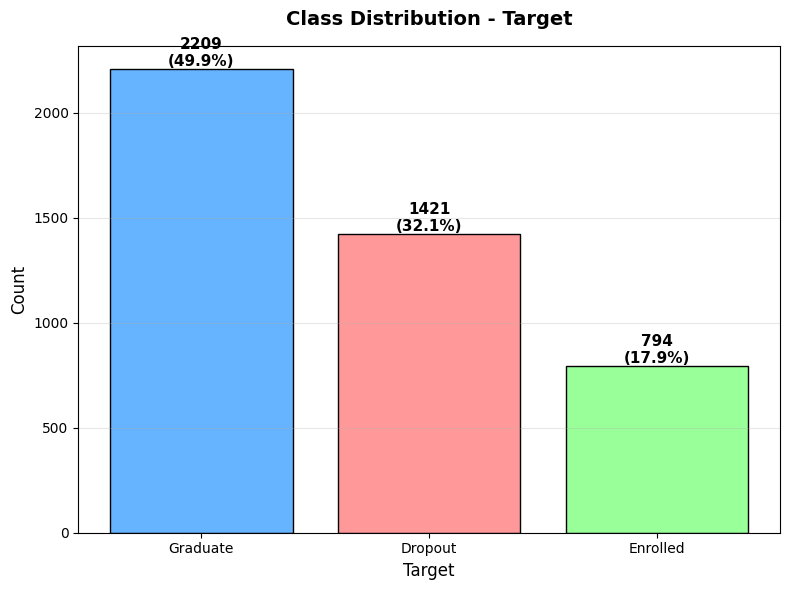


Class Distribution:
--------------------------------------------------------------------------------
   Class  Count  Percentage
Graduate   2209       49.93
 Dropout   1421       32.12
Enrolled    794       17.95

Imbalance Ratio: 2.78:1
⚠️  Moderately imbalanced

✓ Class distribution plot saved and displayed


In [13]:
if target_col in df.columns:
    # Create countplot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    target_counts = df[target_col].value_counts()
    colors = ['#66b3ff', '#ff9999', '#99ff99'][:len(target_counts)]
    
    bars = ax.bar(target_counts.index, target_counts.values, color=colors, edgecolor='black')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({int(height)/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    ax.set_title(f"Class Distribution - {target_col}", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(target_col, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    save_plot(fig, "eda_plots/class_balance", "target_distribution.png")
    plt.show()  # Display in notebook
    
    # Print distribution
    print("\nClass Distribution:")
    print("-" * 80)
    target_dist = pd.DataFrame({
        'Class': target_counts.index,
        'Count': target_counts.values,
        'Percentage': (target_counts.values / len(df) * 100).round(2)
    })
    print(target_dist.to_string(index=False))
    
    # Calculate imbalance ratio
    if len(target_counts) > 1:
        imbalance_ratio = target_counts.max() / target_counts.min()
        print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")
        if imbalance_ratio > 3:
            print("⚠️  Highly imbalanced - consider resampling techniques")
        elif imbalance_ratio > 1.5:
            print("⚠️  Moderately imbalanced")
        else:
            print("✓ Balanced dataset")
    
    print("\n✓ Class distribution plot saved and displayed")

### 3.9 Outlier Visualizations (boxplots/histograms)

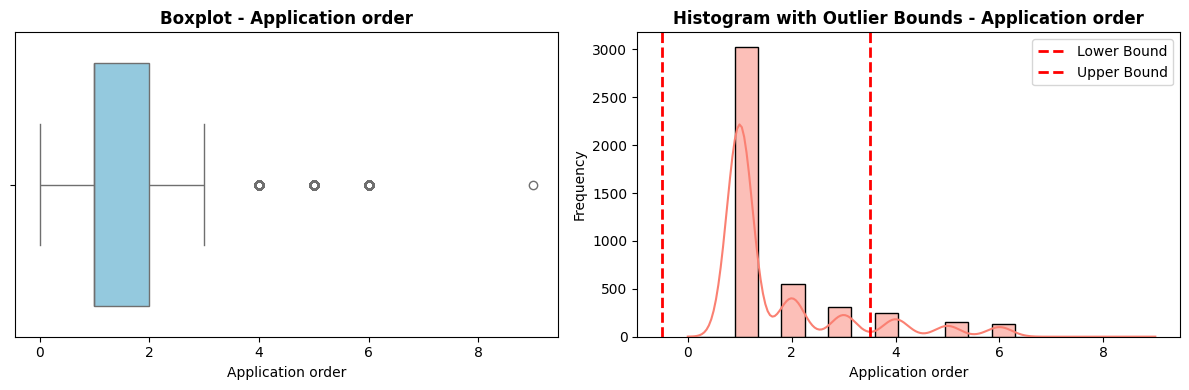

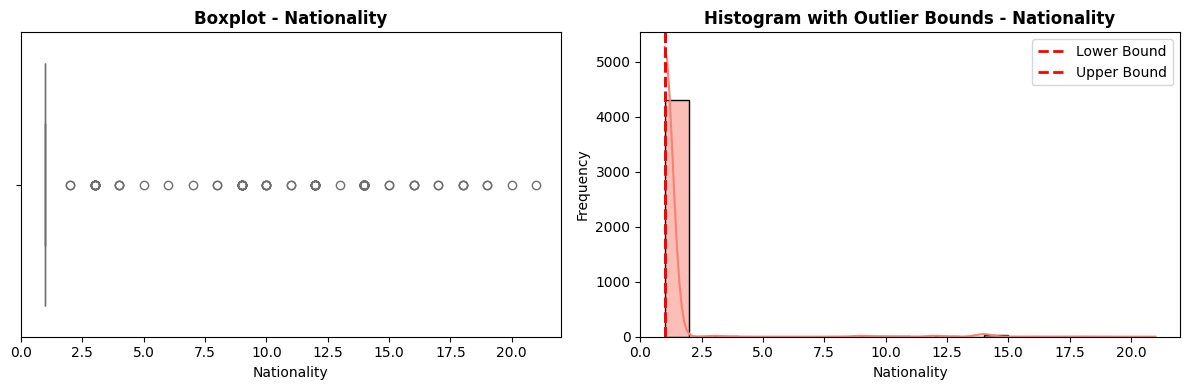

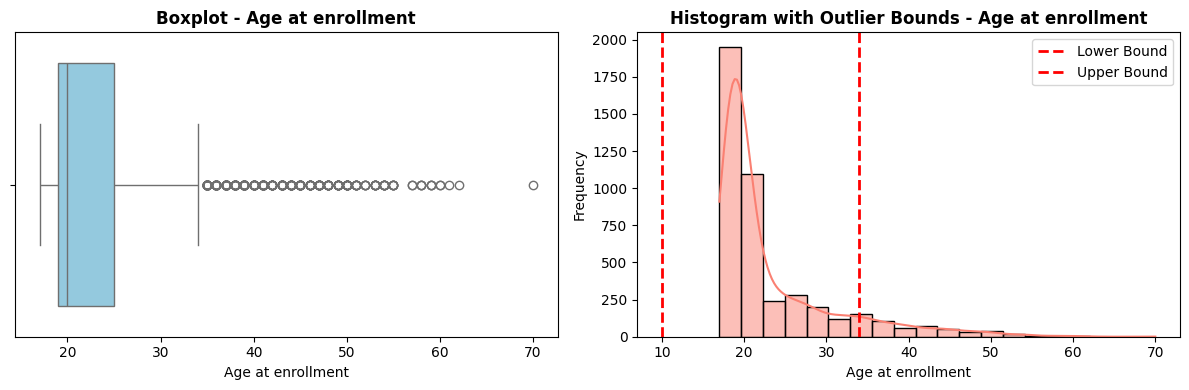

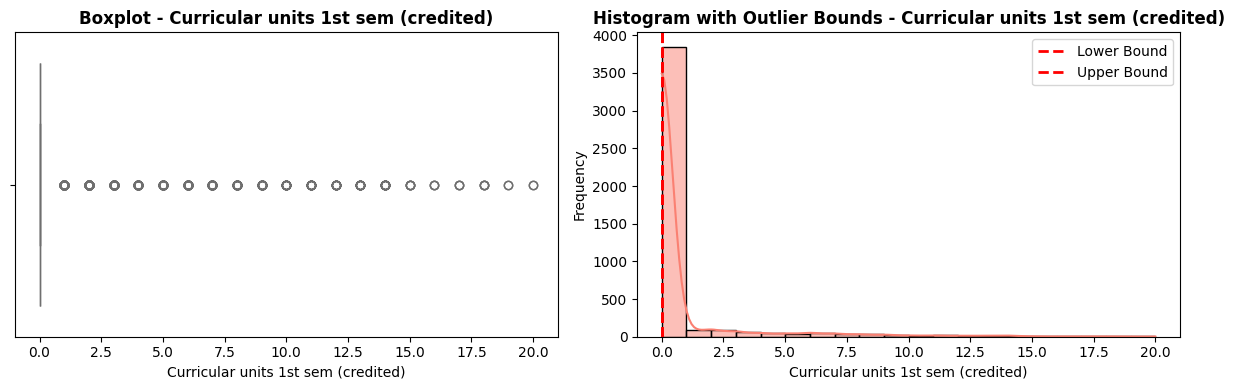

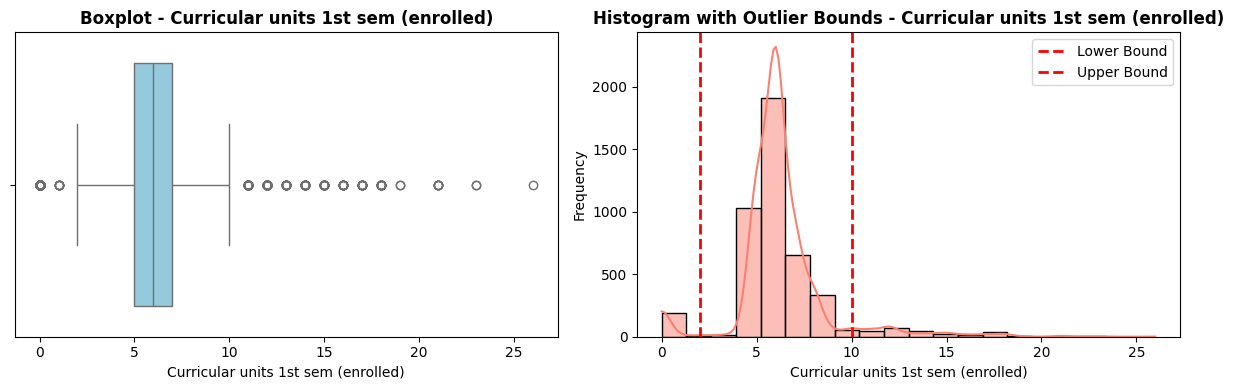

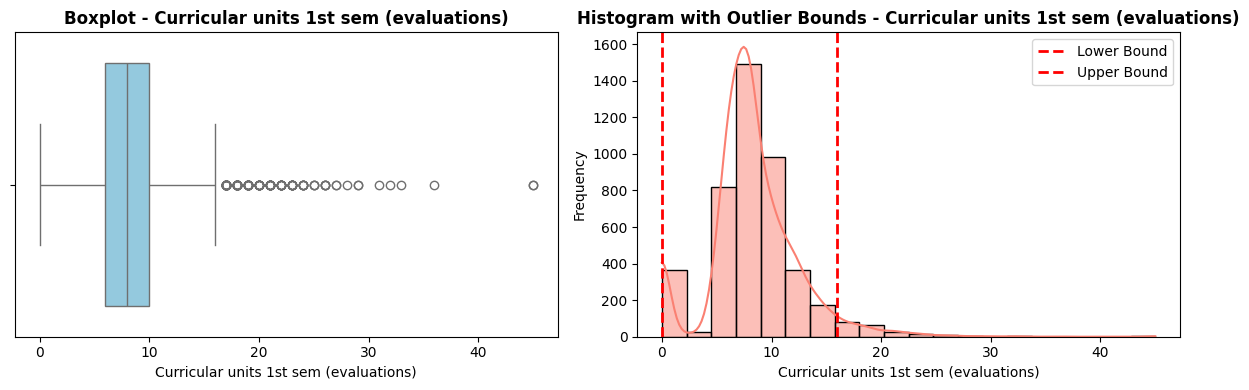

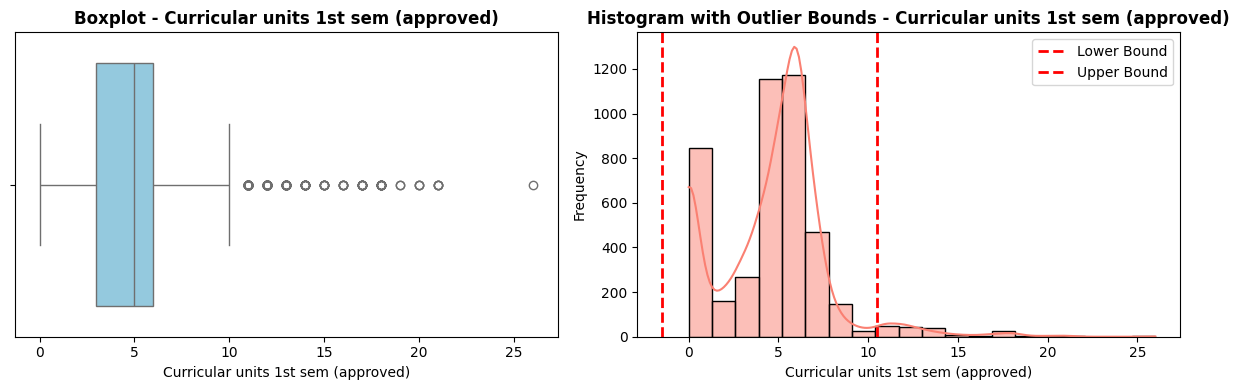

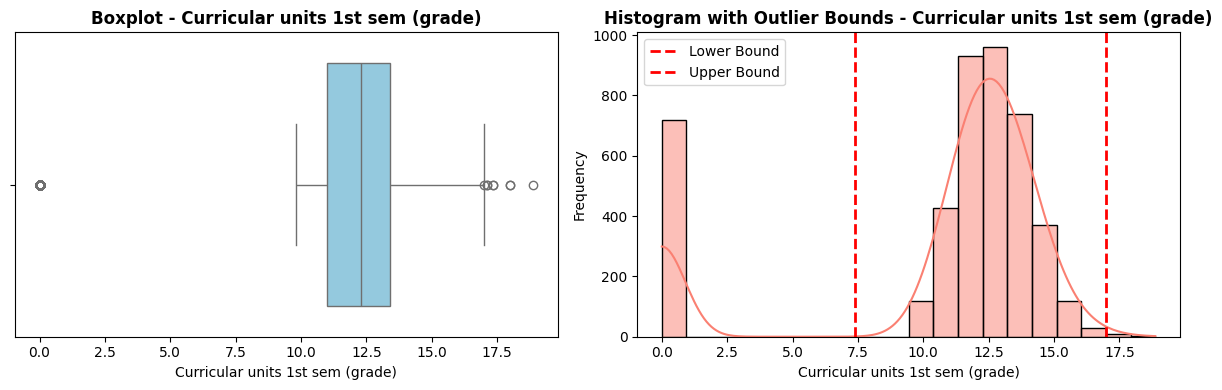

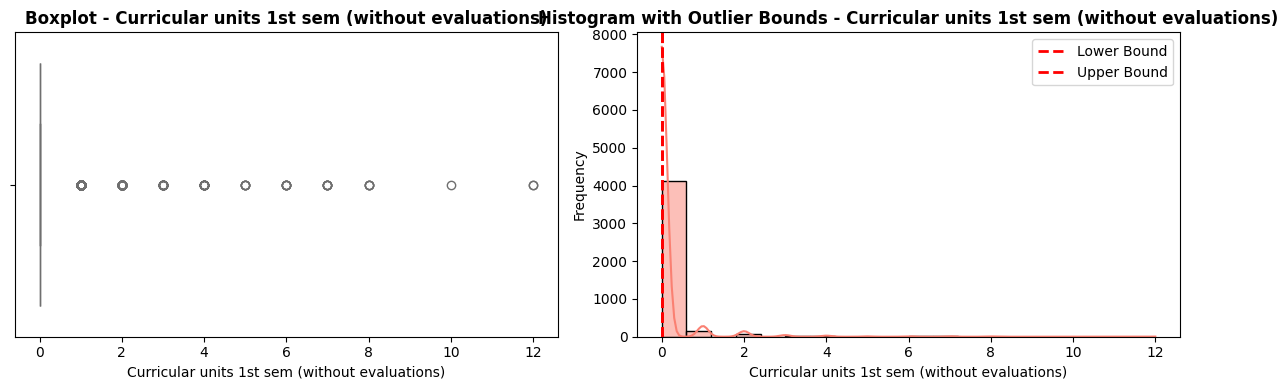

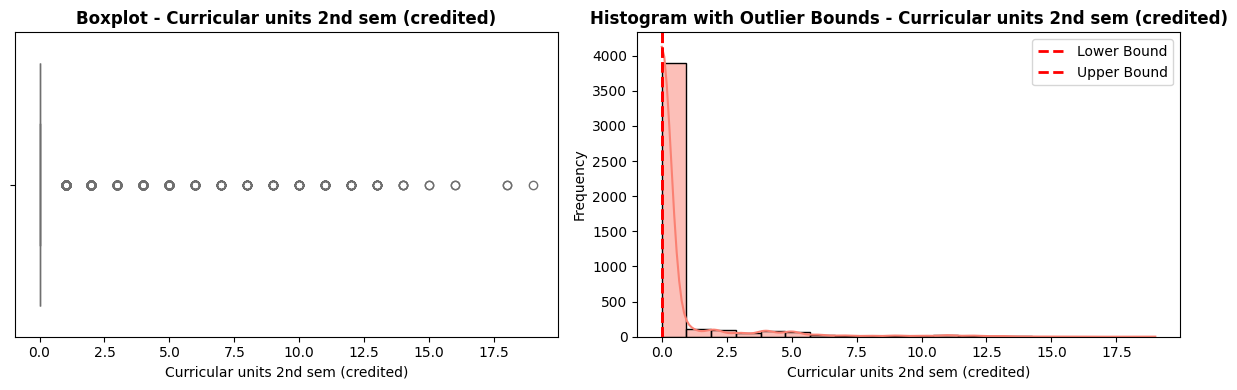

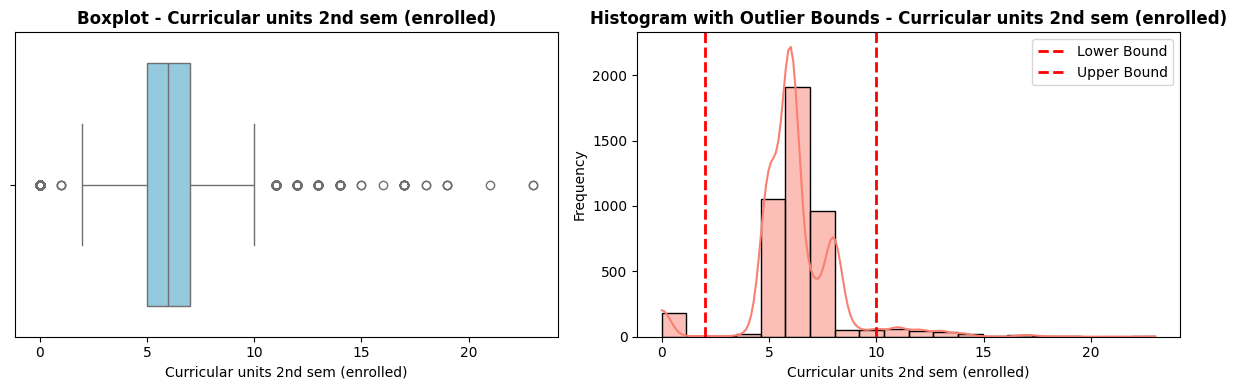

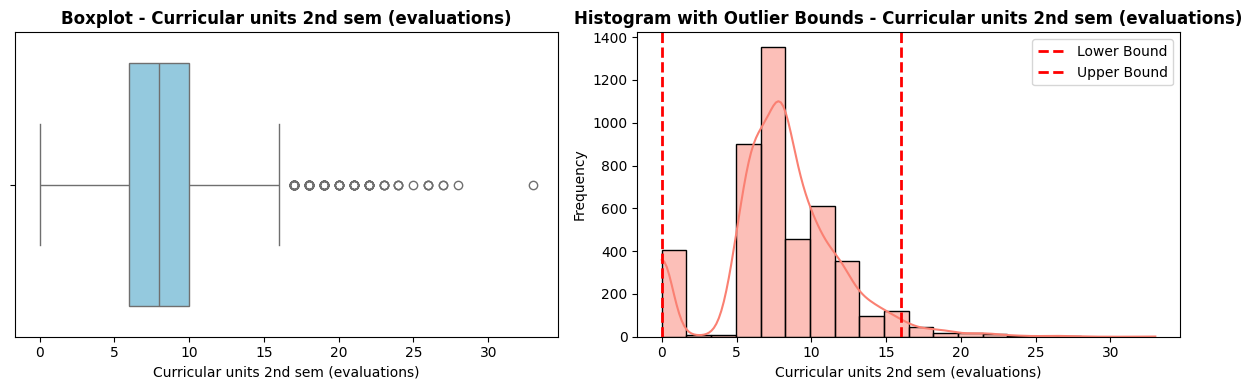

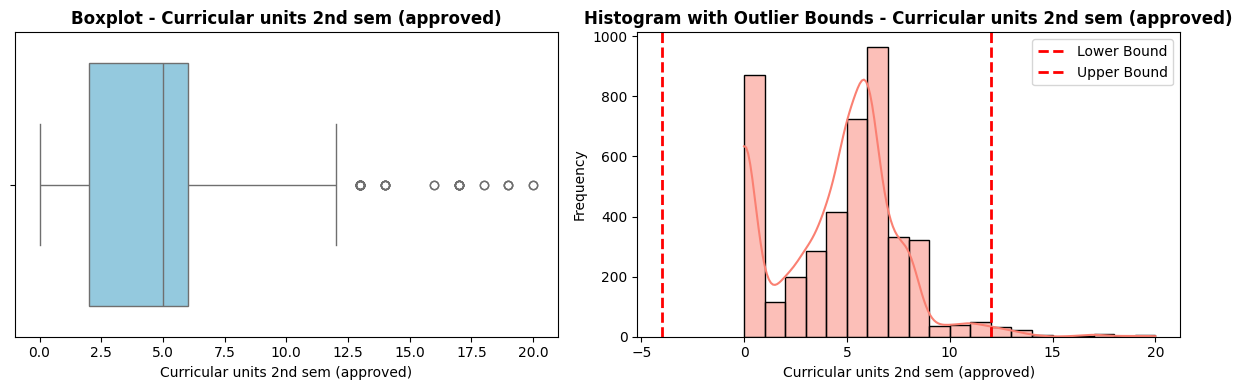

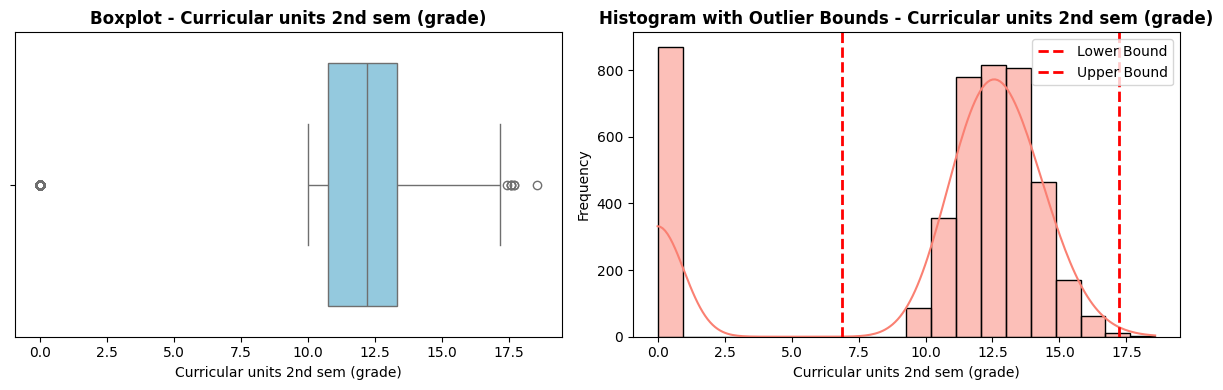

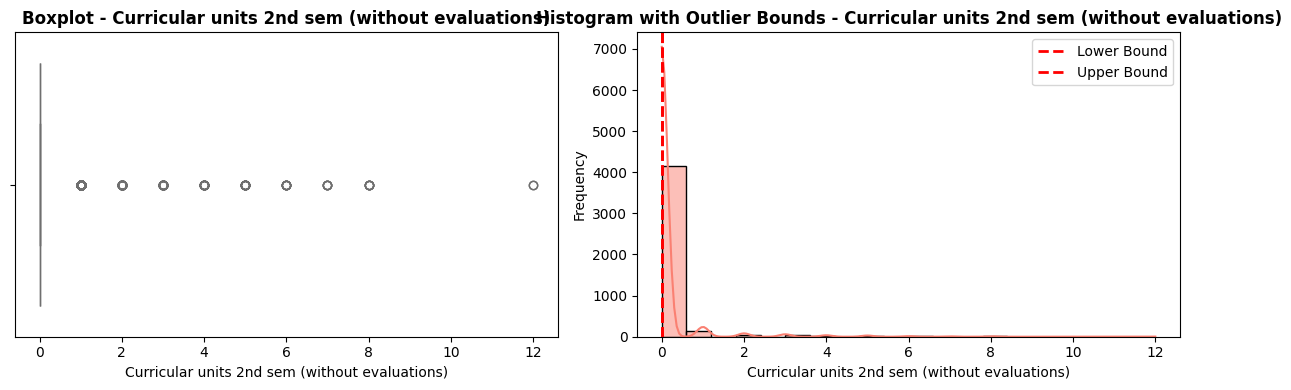

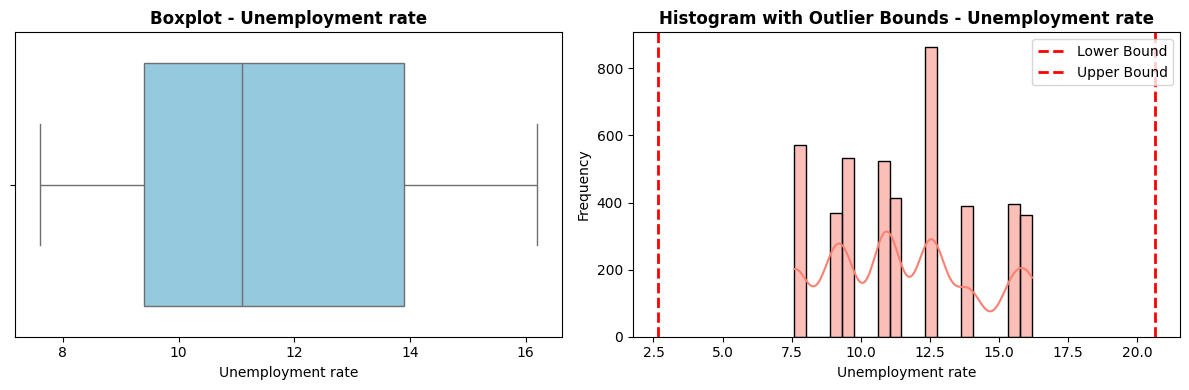

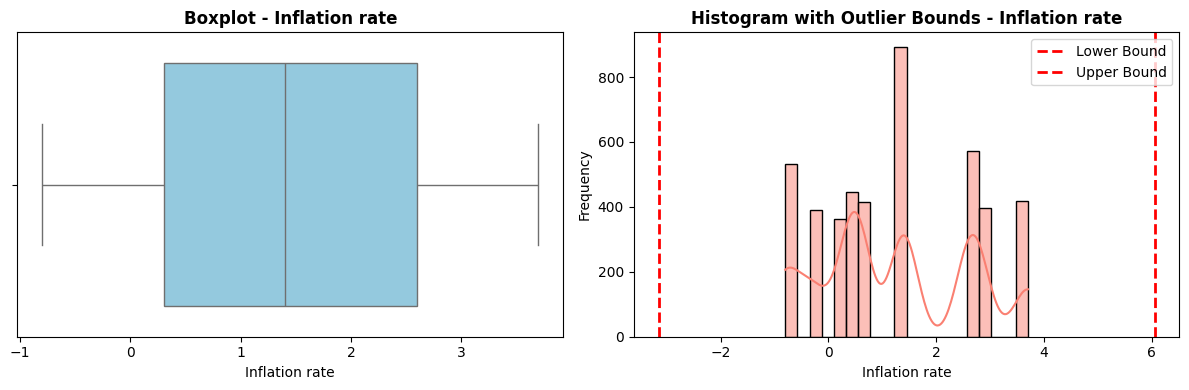

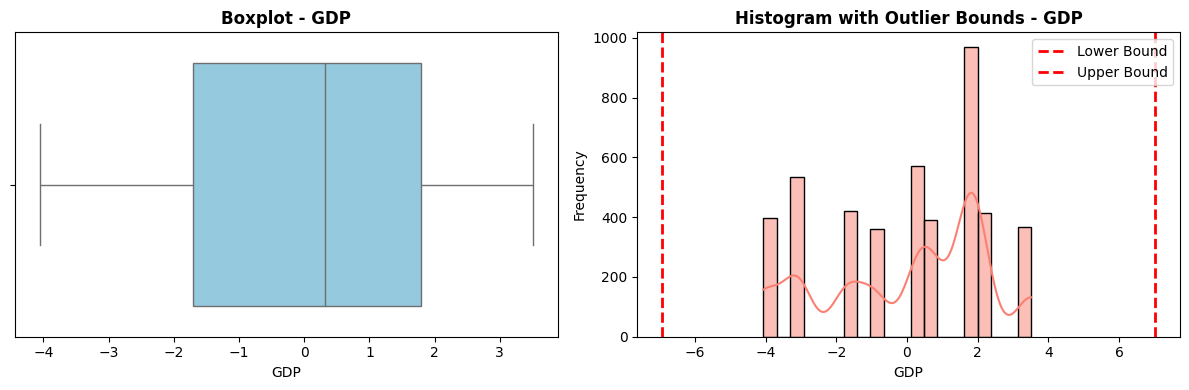


✓ Saved and displayed 18 outlier analysis plots


In [14]:
for col in numeric_cols_viz:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Boxplot
    sns.boxplot(x=df[col], color="skyblue", ax=axes[0])
    axes[0].set_title(f"Boxplot - {col}", fontsize=12, fontweight='bold')
    axes[0].set_xlabel(col, fontsize=10)
    
    # Histogram with bounds
    sns.histplot(df[col], kde=True, color="salmon", ax=axes[1], bins=20)
    axes[1].axvline(lower_bound, color='red', linestyle='--', linewidth=2, label='Lower Bound')
    axes[1].axvline(upper_bound, color='red', linestyle='--', linewidth=2, label='Upper Bound')
    axes[1].set_title(f"Histogram with Outlier Bounds - {col}", fontsize=12, fontweight='bold')
    axes[1].set_xlabel(col, fontsize=10)
    axes[1].set_ylabel('Frequency', fontsize=10)
    axes[1].legend()
    
    plt.tight_layout()
    
    # Save plot
    safe_filename = col.replace("'", "").replace(" ", "_").replace("/", "_")
    save_plot(fig, "eda_plots/outliers", f"{safe_filename}_outlier_analysis.png")
    plt.show()  # Display in notebook

print(f"\n✓ Saved and displayed {len(numeric_cols_viz)} outlier analysis plots")

## 4.0 Preprocessing for Modeling

In [15]:
import numpy as np
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
import pandas as pd

# IMPORTANT: Load original dataset again (with encoded values, not decoded text)
model_df = pd.read_csv("Original-dataset.csv")

print(f"\nOriginal encoded dataset shape: {model_df.shape[0]:,} rows × {model_df.shape[1]} columns")
print(f"\nNote: Using original encoded dataset (numeric codes, not text)")
print(f"      This is separate from the decoded dataset used for EDA")



Original encoded dataset shape: 4,424 rows × 35 columns

Note: Using original encoded dataset (numeric codes, not text)
      This is separate from the decoded dataset used for EDA


### 4.1 Encode Target Variable

In [16]:

print(f"\nOriginal Target distribution:")
print(model_df['Target'].value_counts())

# Encode target variable
le_target = LabelEncoder()
model_df['Target'] = le_target.fit_transform(model_df['Target'])

print(f"\nEncoded Target distribution:")
target_mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
for original, encoded in target_mapping.items():
    count = (model_df['Target'] == encoded).sum()
    print(f"  {original} → {encoded}: {count} records")


Original Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Encoded Target distribution:
  Dropout → 0: 1421 records
  Enrolled → 1: 794 records
  Graduate → 2: 2209 records


### 4.2 Filter Target Classes (DROPOUT vs GRADUATE ONLY)

In [17]:
print(f"\nFocusing on at-risk students who either dropout or graduate")
print(f"           Excluding 'Enrolled' students as outcome is unknown")

print(f"\nTarget distribution before filtering:")
print(model_df['Target'].value_counts())

# Remove "Enrolled" class (keeping only Dropout and Graduate)
enrolled_label = le_target.transform(['Enrolled'])[0]
rows_before = len(model_df)
model_df = model_df[model_df["Target"] != enrolled_label].copy()
rows_removed = rows_before - len(model_df)

print(f"\nRemoved {rows_removed} 'Enrolled' records ({rows_removed/rows_before*100:.2f}%)")
print(f"Remaining records: {len(model_df):,}")


Focusing on at-risk students who either dropout or graduate
           Excluding 'Enrolled' students as outcome is unknown

Target distribution before filtering:
Target
2    2209
0    1421
1     794
Name: count, dtype: int64

Removed 794 'Enrolled' records (17.95%)
Remaining records: 3,630


### 4.3 Remap Target to Binary (0 = GRADUATE, 1 = DROPOUT)

In [18]:
# Get the encoded values for Dropout and Graduate
dropout_encoded = le_target.transform(['Dropout'])[0]
graduate_encoded = le_target.transform(['Graduate'])[0]

print(f"\nOriginal encoding:")
print(f"  Dropout → {dropout_encoded}")
print(f"  Graduate → {graduate_encoded}")

# Remap to binary: Dropout=1 (At-Risk), Graduate=0 (Success)
binary_mapping = {dropout_encoded: 1, graduate_encoded: 0}
model_df['Target'] = model_df['Target'].replace(binary_mapping)

print(f"\nBinary encoding for dropout risk prediction:")
print(f"  Graduate (Success) → 0")
print(f"  Dropout (At-Risk) → 1")

print(f"\nFinal Target distribution:")
target_counts = model_df['Target'].value_counts().sort_index()
for label, count in target_counts.items():
    label_name = "Graduate (Success)" if label == 0 else "Dropout (At-Risk)"
    pct = count / len(model_df) * 100
    print(f"  {label_name}: {count:,} records ({pct:.2f}%)")

# Calculate imbalance ratio
imbalance_ratio = max(target_counts.values) / min(target_counts.values)
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 1.5:
    print("Dataset is imbalanced - will need to address during modeling")
else:
    print("✓ Dataset is relatively balanced")


Original encoding:
  Dropout → 0
  Graduate → 2

Binary encoding for dropout risk prediction:
  Graduate (Success) → 0
  Dropout (At-Risk) → 1

Final Target distribution:
  Graduate (Success): 2,209 records (60.85%)
  Dropout (At-Risk): 1,421 records (39.15%)

Class imbalance ratio: 1.55:1
Dataset is imbalanced - will need to address during modeling


### 4.4 Outlier Detection and Removal (Z-score Method)

In [19]:
print(f"\nRemoving extreme outliers that may skew model predictions")
print(f"           Using Z-score > 3 threshold (beyond 3 standard deviations)")

# Select only numeric columns for Z-score calculation
numeric_columns = model_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns.remove('Target')  # Exclude target from outlier detection

print(f"\nAnalyzing {len(numeric_columns)} numeric features for outliers")

# Calculate Z-scores
z_scores = np.abs(stats.zscore(model_df[numeric_columns]))

# Find outliers (Z-score > 3)
outlier_mask = (z_scores > 3).any(axis=1)
outlier_indices = np.where(outlier_mask)[0]

print(f"\nOutliers detected: {len(outlier_indices)} rows ({len(outlier_indices)/len(model_df)*100:.2f}%)")

# Show which columns have the most outliers
if len(outlier_indices) > 0:
    outlier_counts = (z_scores > 3).sum(axis=0)
    top_outlier_cols = pd.DataFrame({
        'Column': numeric_columns,
        'Outlier Count': outlier_counts
    }).sort_values('Outlier Count', ascending=False).head(10)
    
    print("\nTop 10 features with most outliers:")
    print(top_outlier_cols.to_string(index=False))

# Remove outliers
model_df_before = model_df.copy()
model_df = model_df.drop(model_df.index[outlier_indices]).reset_index(drop=True)
print(f"\nDataset after outlier removal: {model_df.shape[0]:,} rows × {model_df.shape[1]} columns")
print(f"Records removed: {len(model_df_before) - len(model_df):,}")


Removing extreme outliers that may skew model predictions
           Using Z-score > 3 threshold (beyond 3 standard deviations)

Analyzing 34 numeric features for outliers

Outliers detected: 714 rows (19.67%)

Top 10 features with most outliers:
                                        Column  Outlier Count
                             Application order            121
           Curricular units 1st sem (credited)            110
                                Marital status            102
           Curricular units 2nd sem (credited)             99
                             Age at enrollment             91
                                 International             86
           Curricular units 1st sem (enrolled)             79
Curricular units 2nd sem (without evaluations)             72
                                   Nationality             71
                        Previous qualification             68

Dataset after outlier removal: 2,916 rows × 35 columns
Records remove

### 4.5 Feature Selection

In [20]:
print(f"\nRationale: Identifying most predictive socioeconomic and academic indicators")

# Separate features and target
X_temp = model_df.drop(columns=['Target'], axis=1)
y_temp = model_df['Target']

# Identify numeric and categorical features
numeric_features = X_temp.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_temp.select_dtypes(include=['object']).columns.tolist()

print(f"\nFeature breakdown:")
print(f"  - Numeric features: {len(numeric_features)}")
print(f"  - Categorical features: {len(categorical_features)}")

# Check for constant features (zero variance) - for example if all students are portuguese then it provides no info for prediction
print(f"\nChecking for constant features...")
constant_features = []
for col in numeric_features:
    if X_temp[col].nunique() <= 1:
        constant_features.append(col)
        unique_val = X_temp[col].unique()[0] if len(X_temp[col].unique()) > 0 else 'N/A'
        print(f"Constant feature: {col} (value = {unique_val})")

if constant_features:
    print(f"\nFound {len(constant_features)} constant feature(s) - these will be excluded from analysis")
    numeric_features_filtered = [f for f in numeric_features if f not in constant_features]
else:
    print(f"✓ No constant features found")
    numeric_features_filtered = numeric_features

# Feature importance using ANOVA F-statistic for numeric features
if len(numeric_features_filtered) > 0:
    print(f"\nCalculating feature importance (ANOVA F-test)...")
    print(f"Analyzing {len(numeric_features_filtered)} features (excluded {len(constant_features)} constant)")
    
    selector = SelectKBest(score_func=f_classif, k='all')
    selector.fit(X_temp[numeric_features_filtered], y_temp)
    
    feature_scores = pd.DataFrame({
        'Feature': numeric_features_filtered,
        'F-Score': selector.scores_,
        'P-Value': selector.pvalues_
    }).sort_values('F-Score', ascending=False)
    
    print(f"\nTop 15 Most Predictive Features (by F-Score):")
    print("-" * 80)
    print(feature_scores.head(15).to_string(index=False))
    
    # Identify significant features
    significant_features = feature_scores[feature_scores['P-Value'] < 0.05]['Feature'].tolist()
    print(f"\nStatistically significant features (p < 0.05): {len(significant_features)}/{len(numeric_features_filtered)}")
else:
    print("No numeric features available for importance analysis")


Rationale: Identifying most predictive socioeconomic and academic indicators

Feature breakdown:
  - Numeric features: 34
  - Categorical features: 0

Checking for constant features...
Constant feature: Nationality (value = 1)
Constant feature: Educational special needs (value = 0)
Constant feature: International (value = 0)

Found 3 constant feature(s) - these will be excluded from analysis

Calculating feature importance (ANOVA F-test)...
Analyzing 31 features (excluded 3 constant)

Top 15 Most Predictive Features (by F-Score):
--------------------------------------------------------------------------------
                               Feature     F-Score       P-Value
   Curricular units 2nd sem (approved) 3071.338004  0.000000e+00
   Curricular units 1st sem (approved) 2068.767845  0.000000e+00
      Curricular units 2nd sem (grade) 1677.620131 4.622910e-290
      Curricular units 1st sem (grade) 1079.689999 1.028339e-201
               Tuition fees up to date  712.551793 1.2620

### 4.6 Prepare Final Feature Set

In [21]:
# Split features and target
X = model_df.drop(columns=['Target'], axis=1)
y = model_df['Target']

print(f"\nFinal preprocessed dataset:")
print(f"  - Total features: {X.shape[1]} columns")
print(f"  - Total samples: {X.shape[0]:,} rows")
print(f"  - Target variable: Binary (0=Graduate, 1=Dropout)")

# Categorize features by type
print(f"\n{'='*80}")
print(f"Feature categories for dropout prediction:")
print(f"{'='*80}")

socioeconomic_features = [col for col in X.columns if any(term in col.lower() 
                          for term in ['mother', 'father', 'qualification', 'occupation', 
                                       'scholarship', 'tuition', 'debtor', 'displaced'])]
academic_features = [col for col in X.columns if any(term in col.lower() 
                     for term in ['curricular', 'units', 'grade', 'approved', 'enrolled', 
                                  'evaluations', 'credited', 'previous', 'course'])]
demographic_features = [col for col in X.columns if any(term in col.lower() 
                        for term in ['age', 'gender', 'marital', 'international'])]
economic_indicators = [col for col in X.columns if any(term in col.lower()
                       for term in ['unemployment', 'inflation', 'gdp'])]

# Account for features that don't fall into above categories
categorized = socioeconomic_features + academic_features + demographic_features + economic_indicators
other_features = [col for col in X.columns if col not in categorized]

print(f"\n1️1. Academic Performance Indicators: {len(academic_features)} features")
if len(academic_features) > 0:
    for i, feat in enumerate(academic_features, 1):
        print(f"    {i:2d}. {feat}")

print(f"\n2️2. Socioeconomic Indicators: {len(socioeconomic_features)} features")
if len(socioeconomic_features) > 0:
    for i, feat in enumerate(socioeconomic_features, 1):
        print(f"    {i:2d}. {feat}")

print(f"\n3️3. Demographic Features: {len(demographic_features)} features")
if len(demographic_features) > 0:
    for i, feat in enumerate(demographic_features, 1):
        print(f"    {i:2d}. {feat}")

if len(economic_indicators) > 0:
    print(f"\n4️4. Economic Indicators: {len(economic_indicators)} features")
    for i, feat in enumerate(economic_indicators, 1):
        print(f"    {i:2d}. {feat}")

if len(other_features) > 0:
    print(f"\n5️5. Other Features: {len(other_features)} features")
    for i, feat in enumerate(other_features, 1):
        print(f"    {i:2d}. {feat}")

# Summary statistics
print(f"\n{'='*80}")
print(f"FEATURE DISTRIBUTION SUMMARY")
print(f"{'='*80}")
print(f"  Academic features:        {len(academic_features):2d} ({len(academic_features)/X.shape[1]*100:5.1f}%)")
print(f"  Socioeconomic features:   {len(socioeconomic_features):2d} ({len(socioeconomic_features)/X.shape[1]*100:5.1f}%)")
print(f"  Demographic features:     {len(demographic_features):2d} ({len(demographic_features)/X.shape[1]*100:5.1f}%)")
if len(economic_indicators) > 0:
    print(f"  Economic indicators:      {len(economic_indicators):2d} ({len(economic_indicators)/X.shape[1]*100:5.1f}%)")
if len(other_features) > 0:
    print(f"  Other features:           {len(other_features):2d} ({len(other_features)/X.shape[1]*100:5.1f}%)")
print(f"  {'─'*76}")
print(f"  Total features:           {X.shape[1]:2d} (100.0%)")


Final preprocessed dataset:
  - Total features: 34 columns
  - Total samples: 2,916 rows
  - Target variable: Binary (0=Graduate, 1=Dropout)

Feature categories for dropout prediction:

1️1. Academic Performance Indicators: 14 features
     1. Course
     2. Previous qualification
     3. Curricular units 1st sem (credited)
     4. Curricular units 1st sem (enrolled)
     5. Curricular units 1st sem (evaluations)
     6. Curricular units 1st sem (approved)
     7. Curricular units 1st sem (grade)
     8. Curricular units 1st sem (without evaluations)
     9. Curricular units 2nd sem (credited)
    10. Curricular units 2nd sem (enrolled)
    11. Curricular units 2nd sem (evaluations)
    12. Curricular units 2nd sem (approved)
    13. Curricular units 2nd sem (grade)
    14. Curricular units 2nd sem (without evaluations)

2️2. Socioeconomic Indicators: 9 features
     1. Previous qualification
     2. Mother's qualification
     3. Father's qualification
     4. Mother's occupation
   

### 4.7 Standardization

In [22]:
# Standardize only numeric features
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 0:
    scaler = StandardScaler()
    X_scaled = X.copy()
    X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])
    
    print(f"\nStandardized {len(numeric_cols)} numeric features")
    print(f"\nBefore standardization (sample statistics):")
    print(X[numeric_cols].describe().loc[['mean', 'std']].round(2).to_string())
    
    print(f"\nAfter standardization (sample statistics):")
    print(X_scaled[numeric_cols].describe().loc[['mean', 'std']].round(2).to_string())
else:
    X_scaled = X.copy()
    print("No numeric features to standardize")


Standardized 34 numeric features

Before standardization (sample statistics):
      Marital status  Application mode  Application order  Course  Daytime/evening attendance  Previous qualification  Nationality  Mother's qualification  Father's qualification  Mother's occupation  Father's occupation  Displaced  Educational special needs  Debtor  Tuition fees up to date  Gender  Scholarship holder  Age at enrollment  International  Curricular units 1st sem (credited)  Curricular units 1st sem (enrolled)  Curricular units 1st sem (evaluations)  Curricular units 1st sem (approved)  Curricular units 1st sem (grade)  Curricular units 1st sem (without evaluations)  Curricular units 2nd sem (credited)  Curricular units 2nd sem (enrolled)  Curricular units 2nd sem (evaluations)  Curricular units 2nd sem (approved)  Curricular units 2nd sem (grade)  Curricular units 2nd sem (without evaluations)  Unemployment rate  Inflation rate   GDP
mean            1.08              6.38               1.67   

### 4.8 Save Processed Dataset

In [23]:
# Check if there are any object (string) columns remaining
object_cols = X.select_dtypes(include=['object']).columns.tolist()

if len(object_cols) > 0:
    print(f"WARNING: Found {len(object_cols)} non-numeric columns:")
    for col in object_cols:
        print(f"  - {col}: {X[col].dtype}")
    
    print(f"\nEncoding remaining categorical columns...")
    
    # Encode remaining categorical columns using LabelEncoder
    X_encoded = X.copy()
    X_scaled_encoded = X_scaled.copy()
    
    for col in object_cols:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X[col].astype(str))
        X_scaled_encoded[col] = le.transform(X_scaled[col].astype(str))
        print(f"  ✓ Encoded: {col}")
    
    print(f"\n✓ All categorical columns encoded")
else:
    print("✓ All columns are already numeric")
    X_encoded = X.copy()
    X_scaled_encoded = X_scaled.copy()

# Verify all columns are numeric
print(f"\nFinal data type verification:")
print("-" * 80)
print(f"Non-numeric columns in X_encoded: {len(X_encoded.select_dtypes(include=['object']).columns)}")
print(f"Non-numeric columns in X_scaled_encoded: {len(X_scaled_encoded.select_dtypes(include=['object']).columns)}")

# Create dataframes with features and target
df_original = X_encoded.copy()
df_original['Target'] = y

df_standardized = X_scaled_encoded.copy()
df_standardized['Target'] = y

# Verify target is numeric
print(f"\nTarget data type: {df_original['Target'].dtype}")
print(f"Target unique values: {sorted(df_original['Target'].unique())}")

# Save to CSV files
df_original.to_csv("ModelReady.csv", index=False)
df_standardized.to_csv("ModelReady_Standardized.csv", index=False)

print(f"\n✓ Datasets saved successfully:")
print(f"\n1. ModelReady.csv")
print(f"   - Shape: {df_original.shape[0]:,} rows × {df_original.shape[1]} columns")

print(f"\n2. ModelReady_Standardized.csv")
print(f"   - Shape: {df_standardized.shape[0]:,} rows × {df_standardized.shape[1]} columns")

print(f"\nDataset Contents:")
print(f"  - Features: {X_encoded.shape[1]} columns (ALL NUMERIC)")
print(f"  - Target: 1 column (0=Graduate, 1=Dropout)")
print(f"  - Total samples: {len(y):,}")

# Display preview of both datasets
print(f"\nPreview of ModelReady.csv (Encoded, Original Scale):")
print("-" * 80)
print(df_original.head().to_string())

print(f"\nData types in ModelReady.csv:")
print("-" * 80)
print(df_original.dtypes.value_counts())

print(f"\nPreview of ModelReady_Standardized.csv (Encoded + Standardized):")
print("-" * 80)
print(df_standardized.head().to_string())

# Save feature names for reference
feature_info = pd.DataFrame({
    'Feature_Name': X_encoded.columns,
    'Data_Type': X_encoded.dtypes.values,
    'Category': ['Socioeconomic' if col in socioeconomic_features 
                 else 'Academic' if col in academic_features 
                 else 'Demographic' if col in demographic_features 
                 else 'Other' for col in X_encoded.columns]
})
feature_info.to_csv("Feature_Information.csv", index=False)

print(f"\n✓ Feature information saved to: Feature_Information.csv")


print("ALL DATASETS SAVED - FULLY ENCODED AND READY FOR MODELING")


✓ All columns are already numeric

Final data type verification:
--------------------------------------------------------------------------------
Non-numeric columns in X_encoded: 0
Non-numeric columns in X_scaled_encoded: 0

Target data type: int64
Target unique values: [np.int64(0), np.int64(1)]

✓ Datasets saved successfully:

1. ModelReady.csv
   - Shape: 2,916 rows × 35 columns

2. ModelReady_Standardized.csv
   - Shape: 2,916 rows × 35 columns

Dataset Contents:
  - Features: 34 columns (ALL NUMERIC)
  - Target: 1 column (0=Graduate, 1=Dropout)
  - Total samples: 2,916

Preview of ModelReady.csv (Encoded, Original Scale):
--------------------------------------------------------------------------------
   Marital status  Application mode  Application order  Course  Daytime/evening attendance  Previous qualification  Nationality  Mother's qualification  Father's qualification  Mother's occupation  Father's occupation  Displaced  Educational special needs  Debtor  Tuition fees up to

## 5.0 Modeling 

### 5.1: Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Sklearn - Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB

# XGBoost
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    print("XGBoost not installed")
    xgb_available = False

# LGBMClassifier
try:
    from lightgbm import LGBMClassifier
    lgb_available = True
except:
    print("LightGBM not installed")
    lgb_available = False

# Sklearn - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


### 5.2: Load Processed Data

In [25]:
# Load both versions of the dataset
df_original = pd.read_csv("ModelReady.csv")
df_scaled = pd.read_csv("ModelReady_Standardized.csv")

print(f"\n✓ Datasets loaded successfully")
print(f"  - ModelReady.csv: {df_original.shape}")
print(f"  - ModelReady_Standardized.csv: {df_scaled.shape}")

# Prepare features and target
X_original = df_original.drop('Target', axis=1)
X_scaled = df_scaled.drop('Target', axis=1)
y = df_original['Target']

print(f"\nDataset Summary:")
print(f"  - Total samples: {len(y):,}")
print(f"  - Features: {X_original.shape[1]}")
print(f"  - Graduate (0): {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.2f}%)")
print(f"  - Dropout (1): {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.2f}%)")
print(f"  - Imbalance ratio: {(y==0).sum()/(y==1).sum():.2f}:1")


✓ Datasets loaded successfully
  - ModelReady.csv: (2916, 35)
  - ModelReady_Standardized.csv: (2916, 35)

Dataset Summary:
  - Total samples: 2,916
  - Features: 34
  - Graduate (0): 1,799 (61.69%)
  - Dropout (1): 1,117 (38.31%)
  - Imbalance ratio: 1.61:1


### 5.3: Train-Test Split

In [26]:

# Set random state for reproducibility
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Stratified split to maintain class distribution
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_original, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=y
)

X_train_scaled, X_test_scaled, _, _ = train_test_split(
    X_scaled, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=y
)

print(f"\nTraining Set ({100-TEST_SIZE*100:.0f}%):")
print(f"  - Total samples: {len(y_train):,}")
print(f"  - Graduate (0): {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")
print(f"  - Dropout (1): {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")

print(f"\nTest Set ({TEST_SIZE*100:.0f}%):")
print(f"  - Total samples: {len(y_test):,}")
print(f"  - Graduate (0): {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.2f}%)")
print(f"  - Dropout (1): {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")

print(f"\n✓ Stratified split completed - class distribution maintained")


Training Set (80%):
  - Total samples: 2,332
  - Graduate (0): 1,439 (61.71%)
  - Dropout (1): 893 (38.29%)

Test Set (20%):
  - Total samples: 584
  - Graduate (0): 360 (61.64%)
  - Dropout (1): 224 (38.36%)

✓ Stratified split completed - class distribution maintained


###  5.4: Handle Class Imbalance with SMOTE

In [27]:
# Calculate imbalance ratio
imbalance_ratio = (y_train==0).sum() / (y_train==1).sum()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

# Apply SMOTE
print(f"\nApplying SMOTE...")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_orig_balanced, y_train_balanced = smote.fit_resample(X_train_orig, y_train)
X_train_scaled_balanced, _ = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:")
print(f"  - Total samples: {len(y_train_balanced):,} (↑ {len(y_train_balanced)-len(y_train):,} synthetic)")
print(f"  - Graduate (0): {(y_train_balanced==0).sum():,} ({(y_train_balanced==0).sum()/len(y_train_balanced)*100:.2f}%)")
print(f"  - Dropout (1): {(y_train_balanced==1).sum():,} ({(y_train_balanced==1).sum()/len(y_train_balanced)*100:.2f}%)")
print(f"  - New ratio: 1.00:1 (Perfectly balanced)")

print(f"\n✓ SMOTE applied successfully")


Imbalance Ratio: 1.61:1

Applying SMOTE...

After SMOTE:
  - Total samples: 2,878 (↑ 546 synthetic)
  - Graduate (0): 1,439 (50.00%)
  - Dropout (1): 1,439 (50.00%)
  - New ratio: 1.00:1 (Perfectly balanced)

✓ SMOTE applied successfully


### 5.5: Select 4 Models for Comparison

In [28]:
# Define 4 models with clear rationale
models_config = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        'X_train': X_train_scaled_balanced,
        'X_test': X_test_scaled,
        'rationale': 'Simple, interpretable baseline for binary classification',
        'type': 'Linear Model'
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
        'X_train': X_train_orig_balanced,
        'X_test': X_test_orig,
        'rationale': 'Handles non-linear relationships, robust to outliers',
        'type': 'Ensemble (Bagging)'
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
        'X_train': X_train_orig_balanced,
        'X_test': X_test_orig,
        'rationale': 'State-of-the-art gradient boosting, handles imbalance well',
        'type': 'Ensemble (Boosting)'
    },
    'Support Vector Machine': {
        'model': SVC(random_state=RANDOM_STATE, probability=True, kernel='rbf'),
        'X_train': X_train_scaled_balanced,
        'X_test': X_test_scaled,
        'rationale': 'Effective for high-dimensional data, finds optimal decision boundary',
        'type': 'Kernel Method'
    }
}

print("\n Model Selection Rationale:")
for idx, (name, config) in enumerate(models_config.items(), 1):
    print(f"\n{idx}. {name} ({config['type']})")
    print(f"   → {config['rationale']}")

print("\n" + "="*80)


 Model Selection Rationale:

1. Logistic Regression (Linear Model)
   → Simple, interpretable baseline for binary classification

2. Random Forest (Ensemble (Bagging))
   → Handles non-linear relationships, robust to outliers

3. XGBoost (Ensemble (Boosting))
   → State-of-the-art gradient boosting, handles imbalance well

4. Support Vector Machine (Kernel Method)
   → Effective for high-dimensional data, finds optimal decision boundary



### 5.6: Train All 4 Models

In [29]:
results = []
trained_models = {}

for idx, (name, config) in enumerate(models_config.items(), 1):
    print(f"\n[{idx}/4] Training {name}...")
    print("-" * 80)
    
    model = config['model']
    X_train = config['X_train']
    X_test = config['X_test']
    
    # Train
    print(f"  → Fitting model on {X_train.shape[0]:,} training samples...")
    model.fit(X_train, y_train_balanced)

   
    # Predict
    print(f"  → Making predictions on {X_test.shape[0]:,} test samples...")
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"  → Computing evaluation metrics...")
    print(f"\n  Results:")
    print(f"    Accuracy:  {accuracy:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall:    {recall:.4f} ⭐")
    print(f"    F1-Score:  {f1:.4f}")
    print(f"    ROC-AUC:   {roc_auc:.4f}" if roc_auc else "    ROC-AUC:   N/A")
    
    results.append({
        'Model': name,
        'Type': config['type'],
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })
    
    # Store trained model
    trained_models[name] = {
        'model': model,
        'config': config,
        'X_test': X_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'confusion_matrix': cm
    }
    
    print(f"\n  ✓ {name} training completed\n")

print("="*80)
print("ALL 4 MODELS TRAINED SUCCESSFULLY")
print("="*80)


[1/4] Training Logistic Regression...
--------------------------------------------------------------------------------
  → Fitting model on 2,878 training samples...
  → Making predictions on 584 test samples...
  → Computing evaluation metrics...

  Results:
    Accuracy:  0.9092
    Precision: 0.8904
    Recall:    0.8705 ⭐
    F1-Score:  0.8804
    ROC-AUC:   0.9589

  ✓ Logistic Regression training completed


[2/4] Training Random Forest...
--------------------------------------------------------------------------------
  → Fitting model on 2,878 training samples...
  → Making predictions on 584 test samples...
  → Computing evaluation metrics...

  Results:
    Accuracy:  0.9007
    Precision: 0.8990
    Recall:    0.8348 ⭐
    F1-Score:  0.8657
    ROC-AUC:   0.9505

  ✓ Random Forest training completed


[3/4] Training XGBoost...
--------------------------------------------------------------------------------
  → Fitting model on 2,878 training samples...
  → Making prediction

### 5.7: Compare All 4 Models

In [30]:
# Create results dataframe
results_df = pd.DataFrame(results)

# Display full comparison table
print("\n📊 Complete Performance Metrics:")
print("-" * 80)
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].to_string(index=False))

# Rank by different metrics
print("\n" + "="*80)
print("RANKINGS BY METRIC")
print("="*80)

metrics_to_rank = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for metric in metrics_to_rank:
    if results_df[metric].notna().all():
        ranked = results_df.sort_values(metric, ascending=False)
        print(f"\n🏆 Ranked by {metric}:")
        for idx, row in ranked.iterrows():
            rank_emoji = "🥇" if idx == ranked.index[0] else "🥈" if idx == ranked.index[1] else "🥉" if idx == ranked.index[2] else "  "
            print(f"  {rank_emoji} {row['Model']:<25} {row[metric]:.4f}")

# Key insights
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

best_f1 = results_df.loc[results_df['F1-Score'].idxmax()]
best_recall = results_df.loc[results_df['Recall'].idxmax()]
best_accuracy = results_df.loc[results_df['Accuracy'].idxmax()]

print(f"\n• Best Overall (F1-Score): {best_f1['Model']} ({best_f1['F1-Score']:.4f})")
print(f"• Best at Catching Dropouts (Recall): {best_recall['Model']} ({best_recall['Recall']:.4f})")
print(f"• Most Accurate: {best_accuracy['Model']} ({best_accuracy['Accuracy']:.4f})")

print(f"\n💡 For dropout prediction, we prioritize:")
print(f"   1. Recall (catching at-risk students)")
print(f"   2. F1-Score (balanced performance)")
print(f"   3. Precision (minimizing false alarms)")


📊 Complete Performance Metrics:
--------------------------------------------------------------------------------
                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
   Logistic Regression  0.909247   0.890411 0.870536  0.880361 0.958941
         Random Forest  0.900685   0.899038 0.834821  0.865741 0.950508
               XGBoost  0.914384   0.926471 0.843750  0.883178 0.943700
Support Vector Machine  0.902397   0.884793 0.857143  0.870748 0.945523

RANKINGS BY METRIC

🏆 Ranked by Accuracy:
  🥇 XGBoost                   0.9144
  🥈 Logistic Regression       0.9092
  🥉 Support Vector Machine    0.9024
     Random Forest             0.9007

🏆 Ranked by Precision:
  🥇 XGBoost                   0.9265
  🥈 Random Forest             0.8990
  🥉 Logistic Regression       0.8904
     Support Vector Machine    0.8848

🏆 Ranked by Recall:
  🥇 Logistic Regression       0.8705
  🥈 Support Vector Machine    0.8571
  🥉 XGBoost                   0.8438
     Random Forest           

### 5.8: Learning Curves for All Models (Before Tuning)


LEARNING CURVE ANALYSIS - ALL MODELS (DEFAULT PARAMETERS)
Purpose: Assess model learning behavior and detect overfitting/underfitting

Computing learning curve for: Logistic Regression
✓ Final Training Score: 0.9134
✓ Final CV Score: 0.9059
✓ Gap: 0.0075 (Good)

Computing learning curve for: Random Forest
✓ Final Training Score: 1.0000
✓ Final CV Score: 0.9171
✓ Gap: 0.0829 (Moderate)

Computing learning curve for: XGBoost
✓ Final Training Score: 1.0000
✓ Final CV Score: 0.9214
✓ Gap: 0.0786 (Moderate)

Computing learning curve for: Support Vector Machine
✓ Final Training Score: 0.9429
✓ Final CV Score: 0.9226
✓ Gap: 0.0202 (Good)


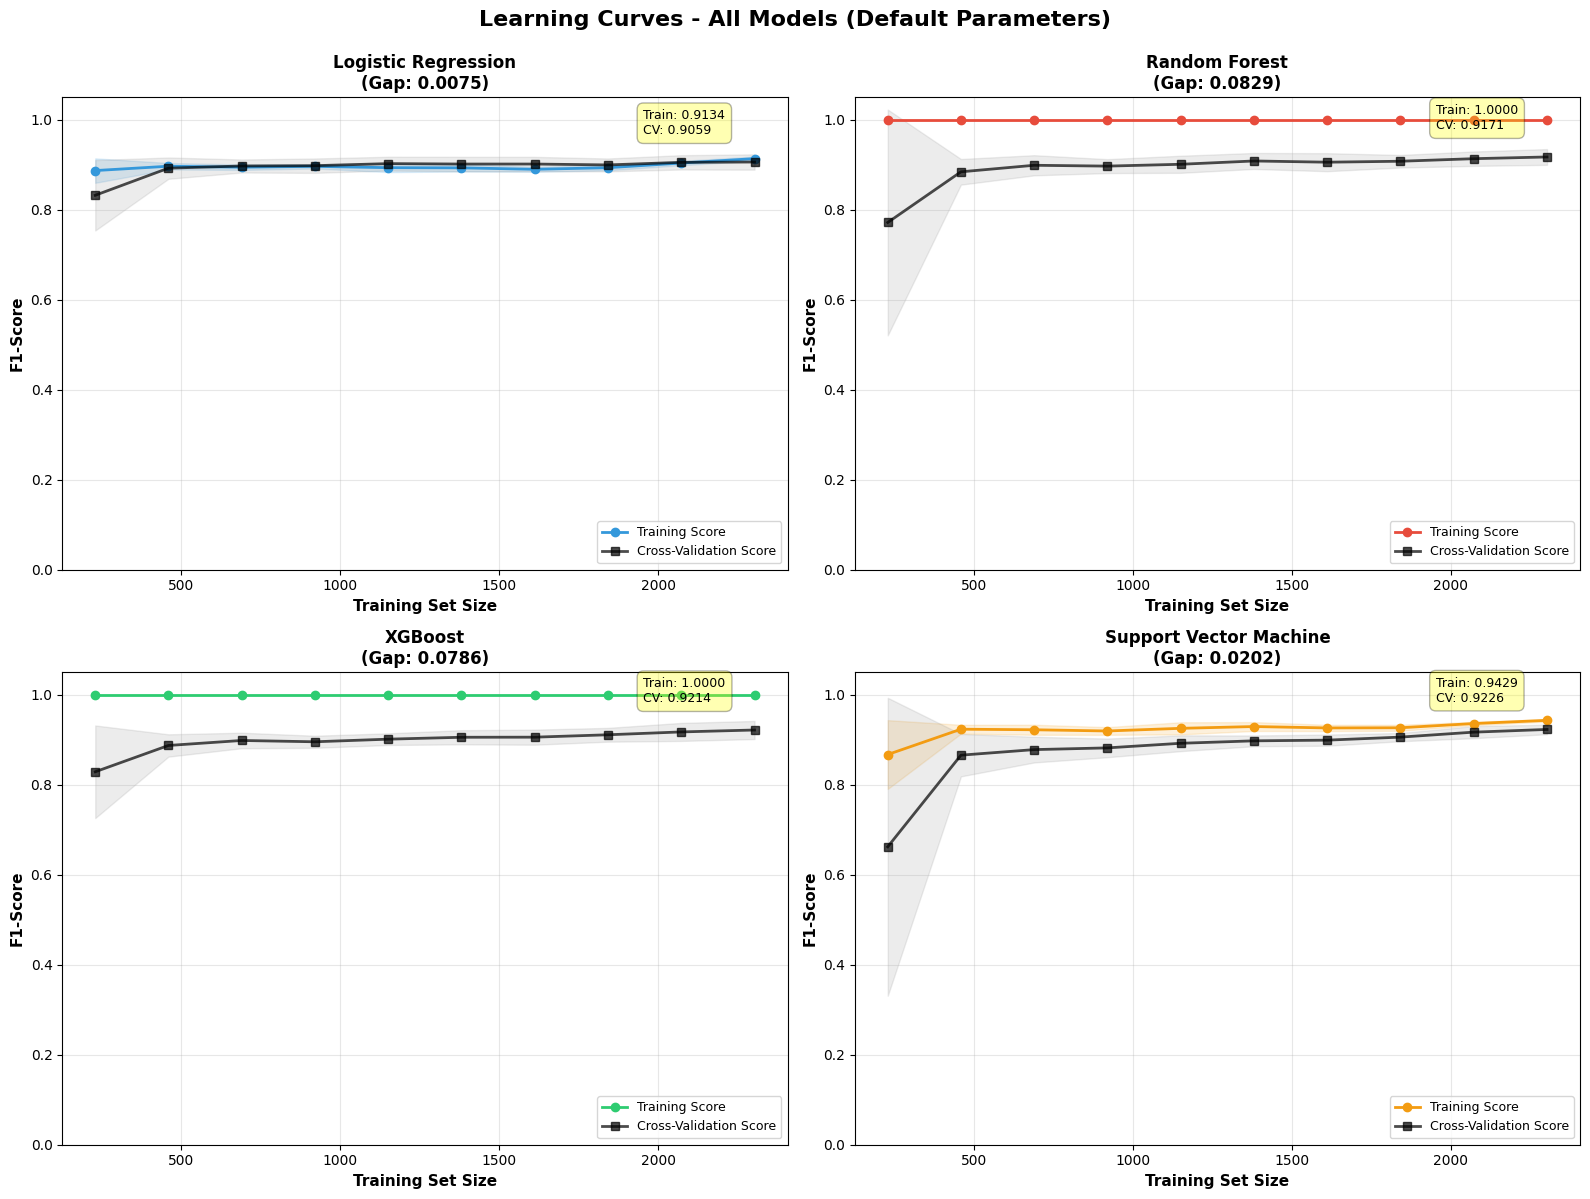


LEARNING CURVE SUMMARY
Model                          Train      CV         Gap        Assessment
--------------------------------------------------------------------------------
Logistic Regression            0.9134     0.9059     0.0075     Good
Random Forest                  1.0000     0.9171     0.0829     Moderate
XGBoost                        1.0000     0.9214     0.0786     Moderate
Support Vector Machine         0.9429     0.9226     0.0202     Good

📊 Interpretation:
  • Small gap (<0.05): Model generalizes well, no overfitting
  • Medium gap (0.05-0.10): Slight overfitting, acceptable
  • Large gap (>0.10): Significant overfitting, needs regularization

✓ Learning curve analysis completed for all models


In [31]:
from sklearn.model_selection import learning_curve

print("\n" + "="*80)
print("LEARNING CURVE ANALYSIS - ALL MODELS (DEFAULT PARAMETERS)")
print("="*80)
print("Purpose: Assess model learning behavior and detect overfitting/underfitting")

# Define training sizes for learning curve
train_sizes = np.linspace(0.1, 1.0, 10)

# Colors for each model
colors_lc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
model_names_short = ['LR', 'RF', 'XGB', 'SVM']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

learning_curve_summary = {}

for idx, (model_name, model_dict) in enumerate(trained_models.items()):
    print(f"\n{'='*80}")
    print(f"Computing learning curve for: {model_name}")
    print(f"{'='*80}")
    
    # Extract the actual model from the dictionary
    model = model_dict['model']
    
    # Determine which training data to use
    if model_name in ['Logistic Regression', 'Support Vector Machine']:
        X_train_lc = X_train_scaled_balanced
    else:
        X_train_lc = X_train_orig_balanced
    
    y_train_lc = y_train_balanced
    
    # Compute learning curve
    train_sizes_abs, train_scores, test_scores = learning_curve(
        model, X_train_lc, y_train_lc,
        train_sizes=train_sizes,
        cv=5,
        scoring='f1',
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    
    # Calculate mean and std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # Calculate final gap
    final_gap = train_mean[-1] - test_mean[-1]
    
    # Store summary
    learning_curve_summary[model_name] = {
        'final_train_score': train_mean[-1],
        'final_cv_score': test_mean[-1],
        'gap': final_gap,
        'convergence': 'Good' if final_gap < 0.05 else 'Moderate' if final_gap < 0.1 else 'Poor'
    }
    
    # Plot learning curve
    ax = axes[idx]
    
    # Plot training score
    ax.plot(train_sizes_abs, train_mean, 'o-', color=colors_lc[idx], 
            label='Training Score', linewidth=2, markersize=6)
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, 
                     alpha=0.15, color=colors_lc[idx])
    
    # Plot cross-validation score
    ax.plot(train_sizes_abs, test_mean, 's-', color='black', 
            label='Cross-Validation Score', linewidth=2, markersize=6, alpha=0.7)
    ax.fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std, 
                     alpha=0.15, color='gray')
    
    # Formatting
    ax.set_xlabel('Training Set Size', fontsize=11, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}\n(Gap: {final_gap:.4f})', 
                fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1.05])
    
    # Add annotation for final scores
    ax.annotate(f'Train: {train_mean[-1]:.4f}\nCV: {test_mean[-1]:.4f}',
               xy=(train_sizes_abs[-1], test_mean[-1]),
               xytext=(-80, 20), textcoords='offset points',
               fontsize=9, bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3))
    
    print(f"✓ Final Training Score: {train_mean[-1]:.4f}")
    print(f"✓ Final CV Score: {test_mean[-1]:.4f}")
    print(f"✓ Gap: {final_gap:.4f} ({learning_curve_summary[model_name]['convergence']})")

plt.suptitle('Learning Curves - All Models (Default Parameters)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
# plt.savefig("model_results/learning_curves_all_models.png", dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "="*80)
print("LEARNING CURVE SUMMARY")
print("="*80)
print(f"{'Model':<30} {'Train':<10} {'CV':<10} {'Gap':<10} {'Assessment'}")
print("-" * 80)
for model_name, summary in learning_curve_summary.items():
    print(f"{model_name:<30} {summary['final_train_score']:.4f}     "
          f"{summary['final_cv_score']:.4f}     {summary['gap']:.4f}     "
          f"{summary['convergence']}")

print("\n📊 Interpretation:")
print("  • Small gap (<0.05): Model generalizes well, no overfitting")
print("  • Medium gap (0.05-0.10): Slight overfitting, acceptable")
print("  • Large gap (>0.10): Significant overfitting, needs regularization")
print("\n✓ Learning curve analysis completed for all models")

### 5.9: Classification Reports & Confusion Matrices for All 4 Models


CLASSIFICATION REPORTS - ALL MODELS (DEFAULT PARAMETERS)
Detailed performance breakdown for each class (Graduate vs Dropout)


LOGISTIC REGRESSION
              precision    recall  f1-score   support

Graduate (0)     0.9205    0.9333    0.9269       360
 Dropout (1)     0.8904    0.8705    0.8804       224

    accuracy                         0.9092       584
   macro avg     0.9055    0.9019    0.9036       584
weighted avg     0.9090    0.9092    0.9090       584


Model Summary:
  Overall Accuracy: 0.9092
  Macro Avg F1-Score: 0.8804
  ROC-AUC Score: 0.9589

RANDOM FOREST
              precision    recall  f1-score   support

Graduate (0)     0.9016    0.9417    0.9212       360
 Dropout (1)     0.8990    0.8348    0.8657       224

    accuracy                         0.9007       584
   macro avg     0.9003    0.8882    0.8935       584
weighted avg     0.9006    0.9007    0.8999       584


Model Summary:
  Overall Accuracy: 0.9007
  Macro Avg F1-Score: 0.8657
  ROC-AUC Score

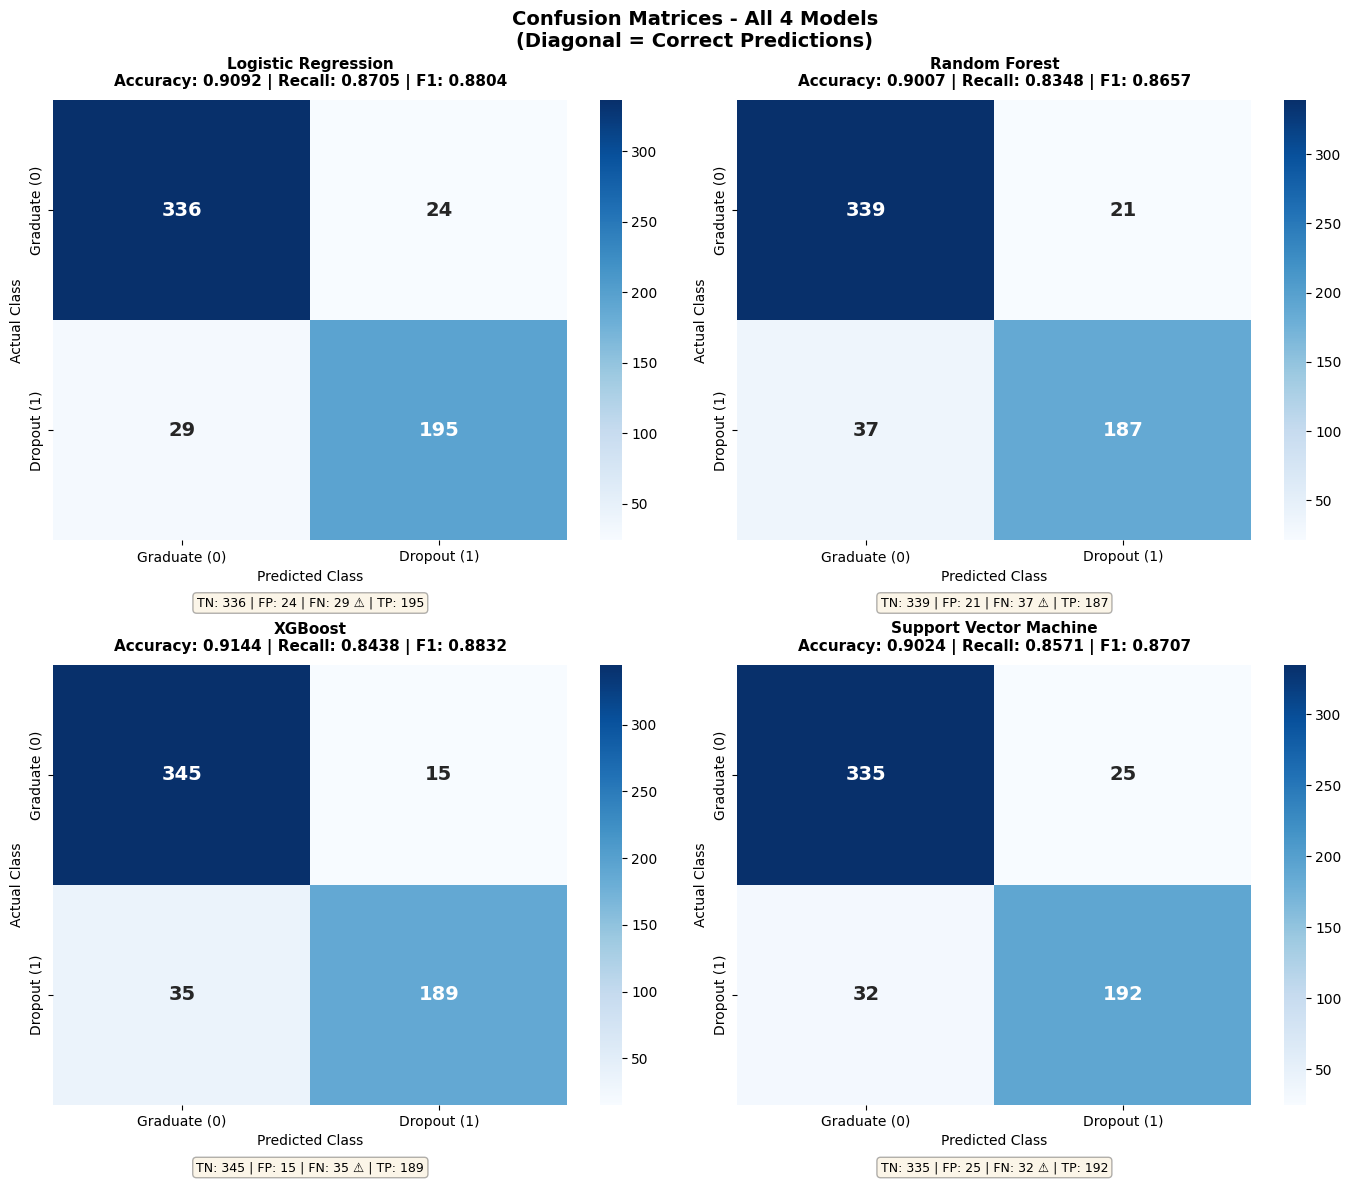


Confusion Matrix Interpretation:
--------------------------------------------------------------------------------

Logistic Regression:
  Graduate Predictions:
    ✓ Correctly identified: 336/360 (93.3%)
    ✗ Misclassified as Dropout: 24/360 (6.7%)
  Dropout Predictions:
    ✓ Correctly identified: 195/224 (87.1%)
    ✗ Missed (False Negative): 29/224 (12.9%) ⚠️

Random Forest:
  Graduate Predictions:
    ✓ Correctly identified: 339/360 (94.2%)
    ✗ Misclassified as Dropout: 21/360 (5.8%)
  Dropout Predictions:
    ✓ Correctly identified: 187/224 (83.5%)
    ✗ Missed (False Negative): 37/224 (16.5%) ⚠️

XGBoost:
  Graduate Predictions:
    ✓ Correctly identified: 345/360 (95.8%)
    ✗ Misclassified as Dropout: 15/360 (4.2%)
  Dropout Predictions:
    ✓ Correctly identified: 189/224 (84.4%)
    ✗ Missed (False Negative): 35/224 (15.6%) ⚠️

Support Vector Machine:
  Graduate Predictions:
    ✓ Correctly identified: 335/360 (93.1%)
    ✗ Misclassified as Dropout: 25/360 (6.9%)
  Dropou

In [32]:
# Print classification reports for all models
print("\n" + "="*80)
print("CLASSIFICATION REPORTS - ALL MODELS (DEFAULT PARAMETERS)")
print("="*80)
print("Detailed performance breakdown for each class (Graduate vs Dropout)\n")

for model_name in trained_models.keys():
    print("\n" + "="*80)
    print(f"{model_name.upper()}")
    print("="*80)
    
    # Get predictions for this model
    model_data = results_df[results_df['Model'] == model_name].iloc[0]
    y_pred = trained_models[model_name]['y_pred']
    
    # Print classification report
    print(classification_report(y_test, y_pred, 
                               target_names=['Graduate (0)', 'Dropout (1)'],
                               digits=4))
    
    # Add model summary
    print(f"\nModel Summary:")
    print(f"  Overall Accuracy: {model_data['Accuracy']:.4f}")
    print(f"  Macro Avg F1-Score: {model_data['F1-Score']:.4f}")
    print(f"  ROC-AUC Score: {model_data['ROC-AUC']:.4f}")

print("\n" + "="*80)
print("KEY METRICS EXPLANATION")
print("="*80)
print("• Precision: Of all predicted dropouts, how many are actually dropouts?")
print("• Recall: Of all actual dropouts, how many did we catch?")
print("• F1-Score: Harmonic mean of precision and recall (balanced measure)")
print("• Support: Number of actual occurrences of each class in test set")
print("\n✓ Classification reports generated for all models\n")

# Visualize confusion matrices
print("="*80)
print("CONFUSION MATRICES VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (model_name, data) in enumerate(trained_models.items()):
    cm = data['confusion_matrix']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Graduate (0)', 'Dropout (1)'],
                yticklabels=['Graduate (0)', 'Dropout (1)'],
                ax=axes[idx], cbar=True, 
                annot_kws={'size': 14, 'weight': 'bold'})
    
    # Get metrics for title
    model_results = results_df[results_df['Model'] == model_name].iloc[0]
    
    axes[idx].set_title(f'{model_name}\n' + 
                       f'Accuracy: {model_results["Accuracy"]:.4f} | ' +
                       f'Recall: {model_results["Recall"]:.4f} | ' +
                       f'F1: {model_results["F1-Score"]:.4f}', 
                       fontsize=11, fontweight='bold', pad=10)
    axes[idx].set_ylabel('Actual Class', fontsize=10)
    axes[idx].set_xlabel('Predicted Class', fontsize=10)
    
    # Add text annotations for interpretation
    tn, fp, fn, tp = cm.ravel()
    
    # Add percentage annotations
    total = cm.sum()
    axes[idx].text(0.5, -0.15, 
                  f'TN: {tn} | FP: {fp} | FN: {fn} ⚠️ | TP: {tp}', 
                  transform=axes[idx].transAxes, ha='center', fontsize=9,
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Confusion Matrices - All 4 Models\n(Diagonal = Correct Predictions)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig("model_results/all_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

# Print detailed breakdown
print("\nConfusion Matrix Interpretation:")
print("-" * 80)
for model_name in trained_models.keys():
    model_results = results_df[results_df['Model'] == model_name].iloc[0]
    cm = trained_models[model_name]['confusion_matrix']
    tn, fp, fn, tp = cm.ravel()
    
    total_dropouts = tp + fn
    total_graduates = tn + fp
    
    print(f"\n{model_name}:")
    print(f"  Graduate Predictions:")
    print(f"    ✓ Correctly identified: {tn}/{total_graduates} ({tn/total_graduates*100:.1f}%)")
    print(f"    ✗ Misclassified as Dropout: {fp}/{total_graduates} ({fp/total_graduates*100:.1f}%)")
    print(f"  Dropout Predictions:")
    print(f"    ✓ Correctly identified: {tp}/{total_dropouts} ({tp/total_dropouts*100:.1f}%)")
    print(f"    ✗ Missed (False Negative): {fn}/{total_dropouts} ({fn/total_dropouts*100:.1f}%) ⚠️")

print("\n" + "="*80)

### 5.10: ROC Curves for All 4 Models

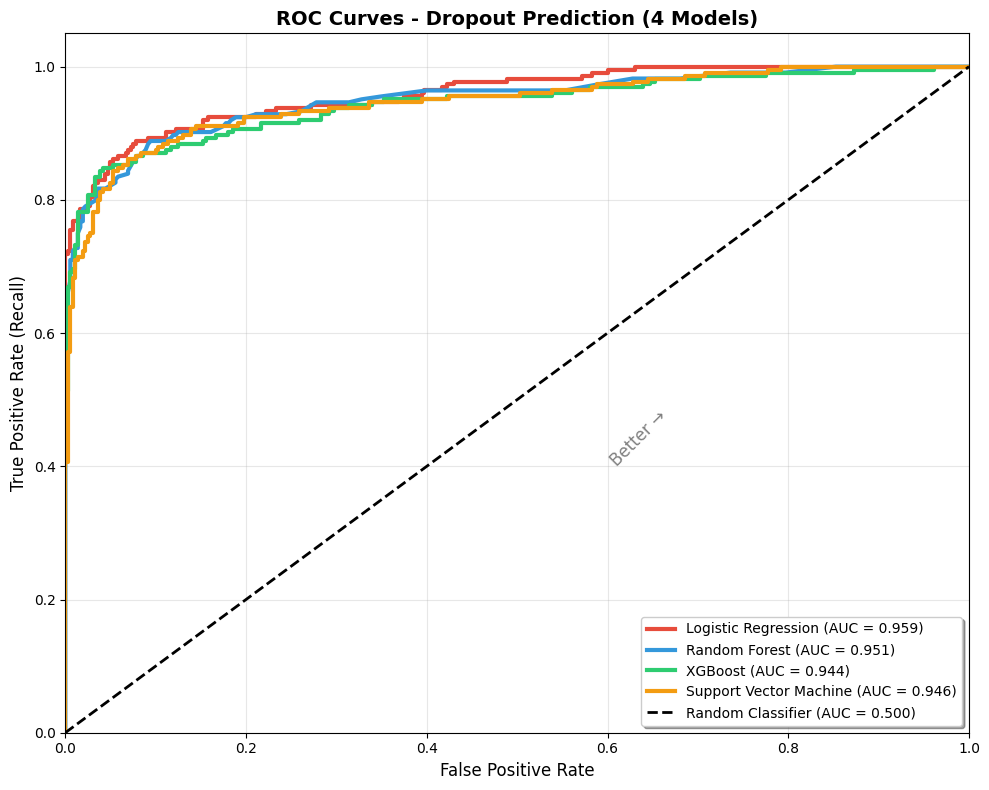


✓ ROC curves generated for all 4 models

💡 Interpretation: Higher AUC = Better overall discrimination ability


In [33]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for idx, (model_name, data) in enumerate(trained_models.items()):
    if data['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, data['y_pred_proba'])
        roc_auc = roc_auc_score(y_test, data['y_pred_proba'])
        ax.plot(fpr, tpr, lw=3, label=f'{model_name} (AUC = {roc_auc:.3f})', 
               color=colors[idx])

# Random classifier line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves - Dropout Prediction (4 Models)', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10, frameon=True, shadow=True)
ax.grid(alpha=0.3)

# Add diagonal reference line annotation
ax.text(0.6, 0.4, 'Better →', fontsize=12, color='gray', rotation=45)

plt.tight_layout()
#plt.savefig("model_results/roc_curves_four_models.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ ROC curves generated for all 4 models")
print("\n💡 Interpretation: Higher AUC = Better overall discrimination ability")

### 5.11: SELECT BEST MODEL

In [34]:
# Selection criteria
print("\nSelection Criteria:")
print("-" * 80)
print("  Primary:   F1-Score (Balance between Precision and Recall)")
print("  Secondary: Recall (Ability to catch at-risk students)")
print("  Tertiary:  ROC-AUC (Overall discrimination ability)")

# Manually select Logistic Regression as best model
best_model_name = 'Logistic Regression'
print(f"\nMANUAL SELECTION: Using {best_model_name} ")
best_model_data = trained_models[best_model_name]
best_model = best_model_data['model']
best_results = results_df[results_df['Model'] == best_model_name].iloc[0]

print(f"\n" + "="*80)
print(f" SELECTED BEST MODEL: {best_model_name}")
print("="*80)

print(f"\nModel Type: {best_results['Type']}")
print(f"Rationale: {models_config[best_model_name]['rationale']}")

print(f"\n Performance Metrics:")
print("-" * 80)
print(f"  Accuracy:  {best_results['Accuracy']:.4f} ({best_results['Accuracy']*100:.2f}%)")
print(f"  Precision: {best_results['Precision']:.4f} ({best_results['Precision']*100:.2f}%)")
print(f"  Recall:    {best_results['Recall']:.4f} ({best_results['Recall']*100:.2f}%) ⭐")
print(f"  F1-Score:  {best_results['F1-Score']:.4f}")
print(f"  ROC-AUC:   {best_results['ROC-AUC']:.4f}")

print(f"\n Confusion Matrix Breakdown:")
print("-" * 80)
cm = best_model_data['confusion_matrix']
tn, fp, fn, tp = cm.ravel()

print(f"  True Negatives  (TN): {tn:>4} - Correctly predicted Graduates")
print(f"  False Positives (FP): {fp:>4} - Graduates wrongly flagged as Dropouts")
print(f"  False Negatives (FN): {fn:>4} - Dropouts missed by the model ⚠️ CRITICAL")
print(f"  True Positives  (TP): {tp:>4} - Correctly identified Dropouts")

print(f"\n Real-World Interpretation:")
print("-" * 80)
total_actual_dropouts = tp + fn
total_actual_graduates = tn + fp

print(f"  Of {total_actual_dropouts} actual dropout students:")
print(f"    → {tp} were correctly identified ({tp/total_actual_dropouts*100:.1f}%)")
print(f"    → {fn} were missed ({fn/total_actual_dropouts*100:.1f}%)")

print(f"\n  Of {total_actual_graduates} actual graduates:")
print(f"    → {tn} were correctly identified ({tn/total_actual_graduates*100:.1f}%)")
print(f"    → {fp} were falsely flagged as at-risk ({fp/total_actual_graduates*100:.1f}%)")

print(f"\n Model Decision:")
print("-" * 80)
print(f"  • For every 100 at-risk students, this model will catch {int(best_results['Recall']*100)}")
print(f"  • Out of students flagged as at-risk, {int(best_results['Precision']*100)}% actually are")

# Save best model
import joblib
import os
os.makedirs("model_results", exist_ok=True)
model_filename = f"best_model_{best_model_name.replace(' ', '_').lower()}.pkl"
joblib.dump(best_model, f"model_results/{model_filename}")

print(f"\n✓ Best model saved to: model_results/{model_filename}")

print("\n" + "="*80)



Selection Criteria:
--------------------------------------------------------------------------------
  Primary:   F1-Score (Balance between Precision and Recall)
  Secondary: Recall (Ability to catch at-risk students)
  Tertiary:  ROC-AUC (Overall discrimination ability)

MANUAL SELECTION: Using Logistic Regression 

 SELECTED BEST MODEL: Logistic Regression

Model Type: Linear Model
Rationale: Simple, interpretable baseline for binary classification

 Performance Metrics:
--------------------------------------------------------------------------------
  Accuracy:  0.9092 (90.92%)
  Precision: 0.8904 (89.04%)
  Recall:    0.8705 (87.05%) ⭐
  F1-Score:  0.8804
  ROC-AUC:   0.9589

 Confusion Matrix Breakdown:
--------------------------------------------------------------------------------
  True Negatives  (TN):  336 - Correctly predicted Graduates
  False Positives (FP):   24 - Graduates wrongly flagged as Dropouts
  False Negatives (FN):   29 - Dropouts missed by the model ⚠️ CRITICA

## 6.0: Model Optimization and Validation

### 6.1: MODEL COMPARISON WITH DEFAULT PARAMETERS

In [35]:
# ============================================================================
# 6.1: MODEL COMPARISON WITH DEFAULT PARAMETERS
# ============================================================================

print("\n" + "="*80)
print("INITIAL MODEL COMPARISON (DEFAULT PARAMETERS)")
print("="*80)
print("Purpose: Identify which models show promise before hyperparameter tuning")

# Convert results list to dictionary for easier access
results_dict = {result['Model']: result for result in results}

# Display initial results
print("\n Initial Model Performance (Default Parameters):")
print("-" * 80)
print(f"{'Model':<30} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 80)

for model_name, metrics in results_dict.items():
    print(f"{model_name:<30} {metrics['Accuracy']:.4f}       {metrics['Precision']:.4f}       {metrics['Recall']:.4f}       {metrics['F1-Score']:.4f}")




INITIAL MODEL COMPARISON (DEFAULT PARAMETERS)
Purpose: Identify which models show promise before hyperparameter tuning

 Initial Model Performance (Default Parameters):
--------------------------------------------------------------------------------
Model                          Accuracy     Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
Logistic Regression            0.9092       0.8904       0.8705       0.8804
Random Forest                  0.9007       0.8990       0.8348       0.8657
XGBoost                        0.9144       0.9265       0.8438       0.8832
Support Vector Machine         0.9024       0.8848       0.8571       0.8707


### 6.2: Hyperparameter Tuning - Grid Search

In [36]:
print("Optimize all models to find the truly best performer")

# Define parameter grids for each model
param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'],
        'class_weight': [None, 'balanced']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': [None, 'balanced']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.3],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'scale_pos_weight': [1, 2, 3]
    },
    # 'XGBoost': {
    #     'n_estimators': [200, 300],
    #     'max_depth': [3, 4, 5],
    #     'learning_rate': [0.03, 0.05, 0.1],
    #     'subsample': [0.7, 0.8, 0.9],
    #     'colsample_bytree': [0.7, 0.8, 0.9],
    #     'min_child_weight': [3, 5, 8],
    #     'gamma': [0, 0.1, 0.3],
    #     'reg_alpha': [0, 0.1],
    #     'reg_lambda': [1, 1.5, 2.0],
    #     'scale_pos_weight': [1, 2, 3]
    # },
    'Support Vector Machine': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'kernel': ['rbf', 'linear'],
        'class_weight': [None, 'balanced']
    }
}

# Dictionary to store tuned models and their results
tuned_models = {}
tuning_results = {}

# Tune each model
for model_name in param_grids.keys():
    print(f"\n{'='*80}")
    print(f"Tuning: {model_name}")
    print(f"{'='*80}")
    
    param_grid = param_grids[model_name]
    
    # Calculate total combinations
    total_combinations = np.prod([len(v) for v in param_grid.values()])
    print(f"Total combinations: {total_combinations}")
    print(f"With 5-fold CV: {total_combinations * 5} model fits")
    
    # Create base model
    if model_name == 'Logistic Regression':
        base_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    elif model_name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=RANDOM_STATE)
    elif model_name == 'XGBoost':
        base_model = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False)
    elif model_name == 'Support Vector Machine':
        base_model = SVC(random_state=RANDOM_STATE, probability=True)
    
    # Grid Search with cross-validation
    print(f"\nRunning Grid Search...")
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1',
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )
    
    # Get appropriate training data based on model type
    if model_name == 'Logistic Regression' or model_name == 'Support Vector Machine':
        X_train_tune = X_train_scaled_balanced
    else:  # Random Forest, XGBoost
        X_train_tune = X_train_orig_balanced
    
    # Fit grid search
    grid_search.fit(X_train_tune, y_train_balanced)
    
    print(f"✓ Completed!")
    
    # Store results
    tuned_models[model_name] = grid_search.best_estimator_
    tuning_results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'std_score': grid_search.cv_results_['std_test_score'][grid_search.best_index_],
        'grid_search': grid_search
    }
    
    print(f"\nBest Parameters:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")
    print(f"\nBest CV F1-Score: {grid_search.best_score_:.4f} ±{tuning_results[model_name]['std_score']:.4f}")

# Compare all tuned models
print("\n" + "="*80)
print("COMPARISON: TUNED MODELS")
print("="*80)
print(f"{'Model':<30} {'CV F1-Score':<20} {'Best Parameters (sample)':<30}")
print("-"*80)

for model_name, result in tuning_results.items():
    # Show first 2 best params as sample
    params_sample = list(result['best_params'].items())[:2]
    params_str = ', '.join([f"{k}={v}" for k, v in params_sample])
    print(f"{model_name:<30} {result['best_score']:.4f} ±{result['std_score']:.4f}      {params_str}...")

# Manually select Logistic Regression as best tuned model
best_tuned_model_name = 'Logistic Regression'
print(f"\n⚠️  MANUAL SELECTION: Using {best_tuned_model_name} (overriding automatic selection)")
best_tuned_model = tuned_models[best_tuned_model_name]
best_tuned_score = tuning_results[best_tuned_model_name]['best_score']

print("\n" + "="*80)
print(f"BEST TUNED MODEL: {best_tuned_model_name}")
print(f"   Cross-Validated F1-Score: {best_tuned_score:.4f}")
print("="*80)

# Compare with original best model
print("\n" + "="*80)
print("BEFORE vs AFTER TUNING COMPARISON")
print("="*80)
print(f"Original Best Model (Default): {best_model_name} - F1: {best_results['F1-Score']:.4f}")
print(f"After Tuning Best Model:       {best_tuned_model_name} - F1: {best_tuned_score:.4f}")

if best_model_name == best_tuned_model_name:
    print("\n✓ Same model remained the best after tuning")
else:
    print("\nDifferent model became the best after tuning!")

# ============================================================================
# COMPREHENSIVE COMPARISON: ALL MODELS - BEFORE vs AFTER TUNING
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE METRICS COMPARISON - ALL MODELS")
print("="*80)
print("Evaluating all tuned models on test set to compare with default models...")

# Dictionary to store all test results
all_tuned_test_metrics = {}

# Evaluate each tuned model on test set
for model_name, model in tuned_models.items():
    # Get appropriate test data
    if model_name == 'Logistic Regression' or model_name == 'Support Vector Machine':
        X_test_eval = X_test_scaled
    else:  # Random Forest, XGBoost
        X_test_eval = X_test_orig
    
    # Make predictions
    y_pred = model.predict(X_test_eval)
    y_pred_proba = model.predict_proba(X_test_eval)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate all metrics
    all_tuned_test_metrics[model_name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    }

# Create comparison dataframes
print("\n" + "="*80)
print("BEFORE TUNING (Default Parameters) - Test Set Performance")
print("="*80)

# Get default model metrics from results_df
default_metrics_comparison = {}
for model_name in tuned_models.keys():
    # Find the row in results_df for this model
    model_row = results_df[results_df['Model'] == model_name]
    if not model_row.empty:
        default_metrics_comparison[model_name] = {
            'Accuracy': model_row.iloc[0]['Accuracy'],
            'Precision': model_row.iloc[0]['Precision'],
            'Recall': model_row.iloc[0]['Recall'],
            'F1-Score': model_row.iloc[0]['F1-Score'],
            'ROC-AUC': model_row.iloc[0]['ROC-AUC']
        }

default_df = pd.DataFrame(default_metrics_comparison).T
default_df = default_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].round(4)
print("\n" + default_df.to_string())

print("\n" + "="*80)
print("AFTER TUNING (Optimized Parameters) - Test Set Performance")
print("="*80)

tuned_df = pd.DataFrame(all_tuned_test_metrics).T
tuned_df = tuned_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].round(4)
print("\n" + tuned_df.to_string())

# Calculate improvement
print("\n" + "="*80)
print("IMPROVEMENT ANALYSIS (After Tuning - Before Tuning)")
print("="*80)

improvement_df = tuned_df - default_df
improvement_df = improvement_df.round(4)
print("\n" + improvement_df.to_string())

# Summary statistics
print("\n" + "="*80)
print("SUMMARY: BEST PERFORMERS")
print("="*80)

metrics_to_compare = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for metric in metrics_to_compare:
    best_before = default_df[metric].idxmax()
    best_before_score = default_df.loc[best_before, metric]
    
    best_after = tuned_df[metric].idxmax()
    best_after_score = tuned_df.loc[best_after, metric]
    
    improvement = best_after_score - best_before_score
    improvement_pct = (improvement / best_before_score) * 100 if best_before_score > 0 else 0
    
    print(f"\n{metric}:")
    print(f"  Before: {best_before:<30} {best_before_score:.4f}")
    print(f"  After:  {best_after:<30} {best_after_score:.4f}")
    print(f"  Improvement: {improvement:+.4f} ({improvement_pct:+.2f}%)")

# Overall ranking by F1-Score
print("\n" + "="*80)
print("OVERALL RANKING BY F1-SCORE")
print("="*80)

print("\nBefore Tuning:")
before_ranked = default_df.sort_values('F1-Score', ascending=False)
for i, (model, row) in enumerate(before_ranked.iterrows(), 1):
    print(f"  {model:<30} F1: {row['F1-Score']:.4f}")

print("\nAfter Tuning:")
after_ranked = tuned_df.sort_values('F1-Score', ascending=False)
for i, (model, row) in enumerate(after_ranked.iterrows(), 1):
    improvement_val = improvement_df.loc[model, 'F1-Score']
    print(f" {model:<30} F1: {row['F1-Score']:.4f} (Δ {improvement_val:+.4f})")

# Save comparison results
comparison_results = {
    'before_tuning': default_df.to_dict(),
    'after_tuning': tuned_df.to_dict(),
    'improvement': improvement_df.to_dict()
}

# import json
# with open('model_results/before_after_tuning_metrics.json', 'w') as f:
#     json.dump(comparison_results, f, indent=2)

# print("\n✅ Comparison metrics saved to: model_results/before_after_tuning_metrics.json")
print("\n✓ Hyperparameter tuning completed for all models")

Optimize all models to find the truly best performer

Tuning: Logistic Regression
Total combinations: 48
With 5-fold CV: 240 model fits

Running Grid Search...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
✓ Completed!

Best Parameters:
  C: 0.1
  class_weight: balanced
  penalty: l1
  solver: liblinear

Best CV F1-Score: 0.9095 ±0.0087

Tuning: Random Forest
Total combinations: 216
With 5-fold CV: 1080 model fits

Running Grid Search...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
✓ Completed!

Best Parameters:
  class_weight: balanced
  max_depth: 20
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 300

Best CV F1-Score: 0.9242 ±0.0082

Tuning: XGBoost
Total combinations: 1296
With 5-fold CV: 6480 model fits

Running Grid Search...
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
✓ Completed!

Best Parameters:
  colsample_bytree: 0.9
  learning_rate: 0.1
  max_depth: 7
  n_estimators: 300
  scale_pos_weight: 2
  subsample

### 6.3: Classification Reports & Confusion Matrices for All Tuned Models


CLASSIFICATION REPORTS - ALL TUNED MODELS (AFTER HYPERPARAMETER TUNING)
Detailed performance breakdown for each class (Graduate vs Dropout)


LOGISTIC REGRESSION (TUNED)
              precision    recall  f1-score   support

Graduate (0)     0.9160    0.9389    0.9273       360
 Dropout (1)     0.8977    0.8616    0.8793       224

    accuracy                         0.9092       584
   macro avg     0.9068    0.9002    0.9033       584
weighted avg     0.9090    0.9092    0.9089       584


Model Summary:
  Overall Accuracy: 0.9092
  Macro Avg F1-Score: 0.8793
  ROC-AUC Score: 0.9564

RANDOM FOREST (TUNED)
              precision    recall  f1-score   support

Graduate (0)     0.9113    0.9417    0.9262       360
 Dropout (1)     0.9009    0.8527    0.8761       224

    accuracy                         0.9075       584
   macro avg     0.9061    0.8972    0.9012       584
weighted avg     0.9073    0.9075    0.9070       584


Model Summary:
  Overall Accuracy: 0.9075
  Macro Avg F

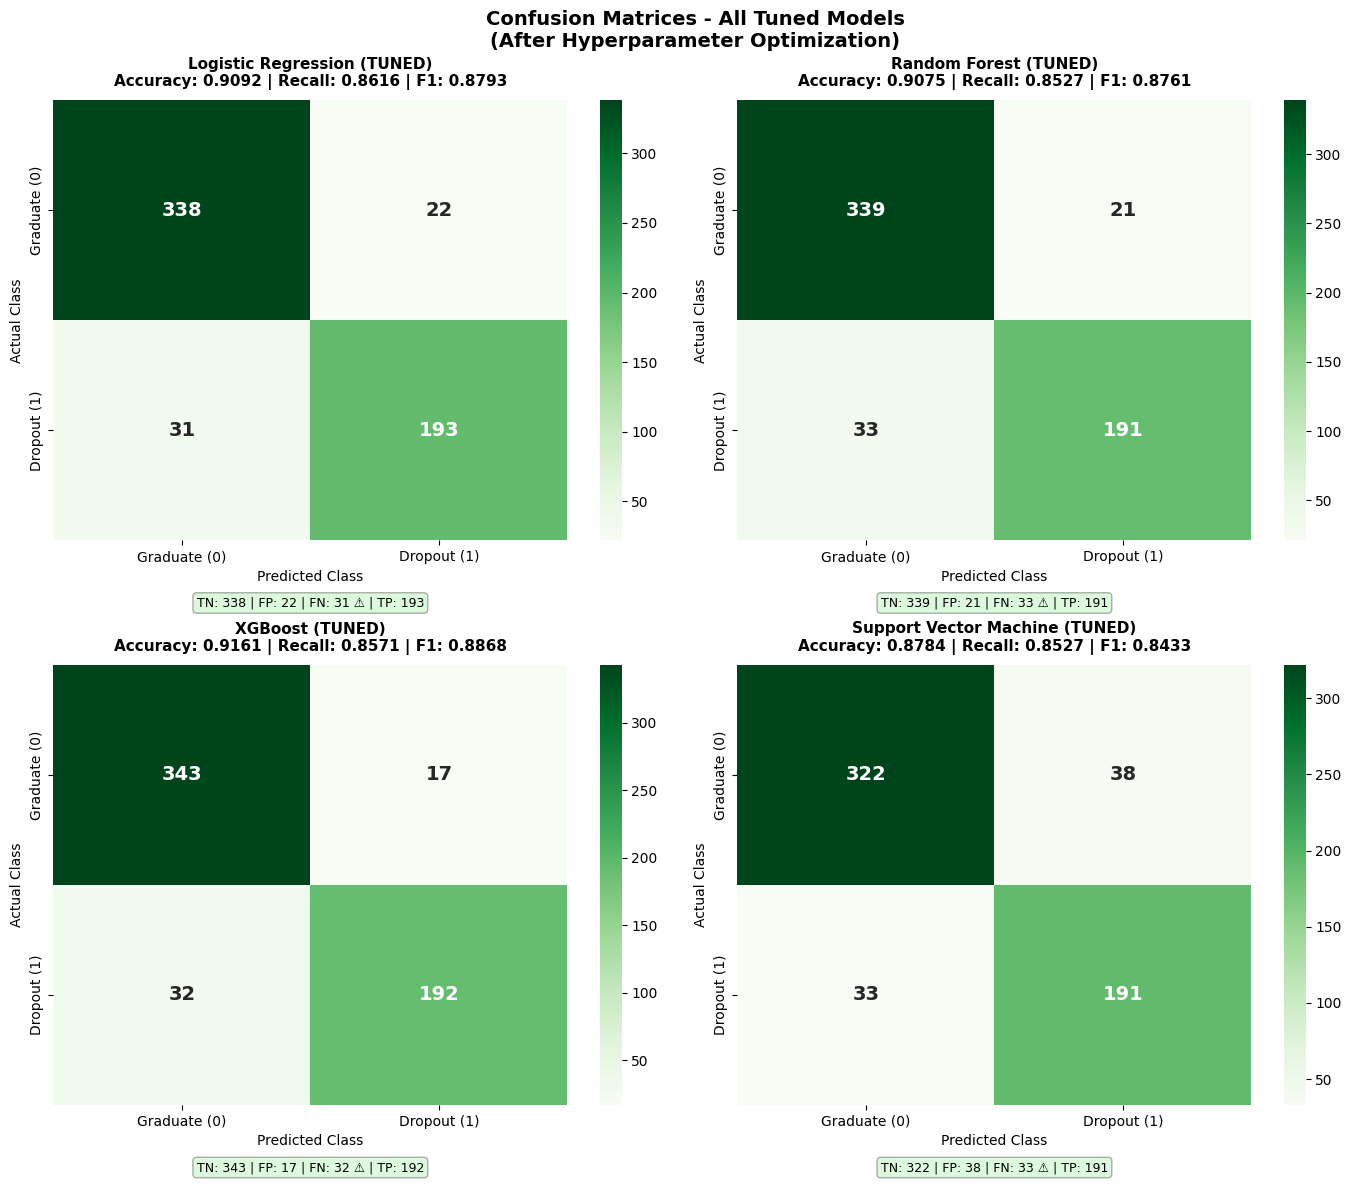


Confusion Matrix Interpretation (Tuned Models):
--------------------------------------------------------------------------------

Logistic Regression (TUNED):
  Graduate Predictions:
    ✓ Correctly identified: 338/360 (93.9%)
    ✗ Misclassified as Dropout: 22/360 (6.1%)
  Dropout Predictions:
    ✓ Correctly identified: 193/224 (86.2%)
    ✗ Missed (False Negative): 31/224 (13.8%) ⚠️

Random Forest (TUNED):
  Graduate Predictions:
    ✓ Correctly identified: 339/360 (94.2%)
    ✗ Misclassified as Dropout: 21/360 (5.8%)
  Dropout Predictions:
    ✓ Correctly identified: 191/224 (85.3%)
    ✗ Missed (False Negative): 33/224 (14.7%) ⚠️

XGBoost (TUNED):
  Graduate Predictions:
    ✓ Correctly identified: 343/360 (95.3%)
    ✗ Misclassified as Dropout: 17/360 (4.7%)
  Dropout Predictions:
    ✓ Correctly identified: 192/224 (85.7%)
    ✗ Missed (False Negative): 32/224 (14.3%) ⚠️

Support Vector Machine (TUNED):
  Graduate Predictions:
    ✓ Correctly identified: 322/360 (89.4%)
    ✗ M

In [37]:
# ============================================================================
# 6.3: CLASSIFICATION REPORTS & CONFUSION MATRICES - ALL TUNED MODELS
# ============================================================================

# Print classification reports for all tuned models
print("\n" + "="*80)
print("CLASSIFICATION REPORTS - ALL TUNED MODELS (AFTER HYPERPARAMETER TUNING)")
print("="*80)
print("Detailed performance breakdown for each class (Graduate vs Dropout)\n")

# Store predictions for all tuned models
tuned_predictions = {}

for model_name, model in tuned_models.items():
    print("\n" + "="*80)
    print(f"{model_name.upper()} (TUNED)")
    print("="*80)
    
    # Determine which test data to use
    if model_name in ['Logistic Regression', 'Support Vector Machine']:
        X_test_eval = X_test_scaled
    else:
        X_test_eval = X_test_orig
    
    # Make predictions
    y_pred = model.predict(X_test_eval)
    tuned_predictions[model_name] = {
        'y_pred': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    
    # Print classification report
    print(classification_report(y_test, y_pred, 
                               target_names=['Graduate (0)', 'Dropout (1)'],
                               digits=4))
    
    # Get metrics from all_tuned_test_metrics
    model_metrics = all_tuned_test_metrics[model_name]
    print(f"\nModel Summary:")
    print(f"  Overall Accuracy: {model_metrics['Accuracy']:.4f}")
    print(f"  Macro Avg F1-Score: {model_metrics['F1-Score']:.4f}")
    print(f"  ROC-AUC Score: {model_metrics['ROC-AUC']:.4f}")

print("\n" + "="*80)
print("KEY METRICS EXPLANATION")
print("="*80)
print("• Precision: Of all predicted dropouts, how many are actually dropouts?")
print("• Recall: Of all actual dropouts, how many did we catch?")
print("• F1-Score: Harmonic mean of precision and recall (balanced measure)")
print("• Support: Number of actual occurrences of each class in test set")
print("\n✓ Classification reports generated for all tuned models\n")

# Visualize confusion matrices for all tuned models
print("="*80)
print("CONFUSION MATRICES VISUALIZATION - ALL TUNED MODELS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (model_name, data) in enumerate(tuned_predictions.items()):
    cm = data['confusion_matrix']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Graduate (0)', 'Dropout (1)'],
                yticklabels=['Graduate (0)', 'Dropout (1)'],
                ax=axes[idx], cbar=True, 
                annot_kws={'size': 14, 'weight': 'bold'})
    
    # Get metrics for title
    model_metrics = all_tuned_test_metrics[model_name]
    
    axes[idx].set_title(f'{model_name} (TUNED)\n' + 
                       f'Accuracy: {model_metrics["Accuracy"]:.4f} | ' +
                       f'Recall: {model_metrics["Recall"]:.4f} | ' +
                       f'F1: {model_metrics["F1-Score"]:.4f}', 
                       fontsize=11, fontweight='bold', pad=10)
    axes[idx].set_ylabel('Actual Class', fontsize=10)
    axes[idx].set_xlabel('Predicted Class', fontsize=10)
    
    # Add text annotations
    tn, fp, fn, tp = cm.ravel()
    axes[idx].text(0.5, -0.15, 
                  f'TN: {tn} | FP: {fp} | FN: {fn} ⚠️ | TP: {tp}', 
                  transform=axes[idx].transAxes, ha='center', fontsize=9,
                  bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

plt.suptitle('Confusion Matrices - All Tuned Models\n(After Hyperparameter Optimization)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("model_results/all_tuned_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

# Print detailed breakdown
print("\nConfusion Matrix Interpretation (Tuned Models):")
print("-" * 80)
for model_name, data in tuned_predictions.items():
    model_metrics = all_tuned_test_metrics[model_name]
    cm = data['confusion_matrix']
    tn, fp, fn, tp = cm.ravel()
    
    total_dropouts = tp + fn
    total_graduates = tn + fp
    
    print(f"\n{model_name} (TUNED):")
    print(f"  Graduate Predictions:")
    print(f"    ✓ Correctly identified: {tn}/{total_graduates} ({tn/total_graduates*100:.1f}%)")
    print(f"    ✗ Misclassified as Dropout: {fp}/{total_graduates} ({fp/total_graduates*100:.1f}%)")
    print(f"  Dropout Predictions:")
    print(f"    ✓ Correctly identified: {tp}/{total_dropouts} ({tp/total_dropouts*100:.1f}%)")
    print(f"    ✗ Missed (False Negative): {fn}/{total_dropouts} ({fn/total_dropouts*100:.1f}%) ⚠️")

print("\n" + "="*80)
print("\n✓ Classification reports and confusion matrices completed for all tuned models")

### 6.4: Final Model Selection


CROSS-VALIDATION: Logistic Regression
Purpose: Assess model stability and generalization capability
Using scaled balanced training data for Logistic Regression

Running cross-validation...

📊 Cross-Validation Results (5-Fold):
--------------------------------------------------------------------------------
Metric       Mean       Std Dev    Min        Max       
--------------------------------------------------------------------------------
Accuracy     0.9124     ±0.0081     0.8976     0.9219
Precision    0.9413     ±0.0084     0.9288     0.9545
Recall       0.8798     ±0.0125     0.8611     0.8993
F1           0.9095     ±0.0087     0.8937     0.9201
Roc_auc      0.9584     ±0.0067     0.9468     0.9646


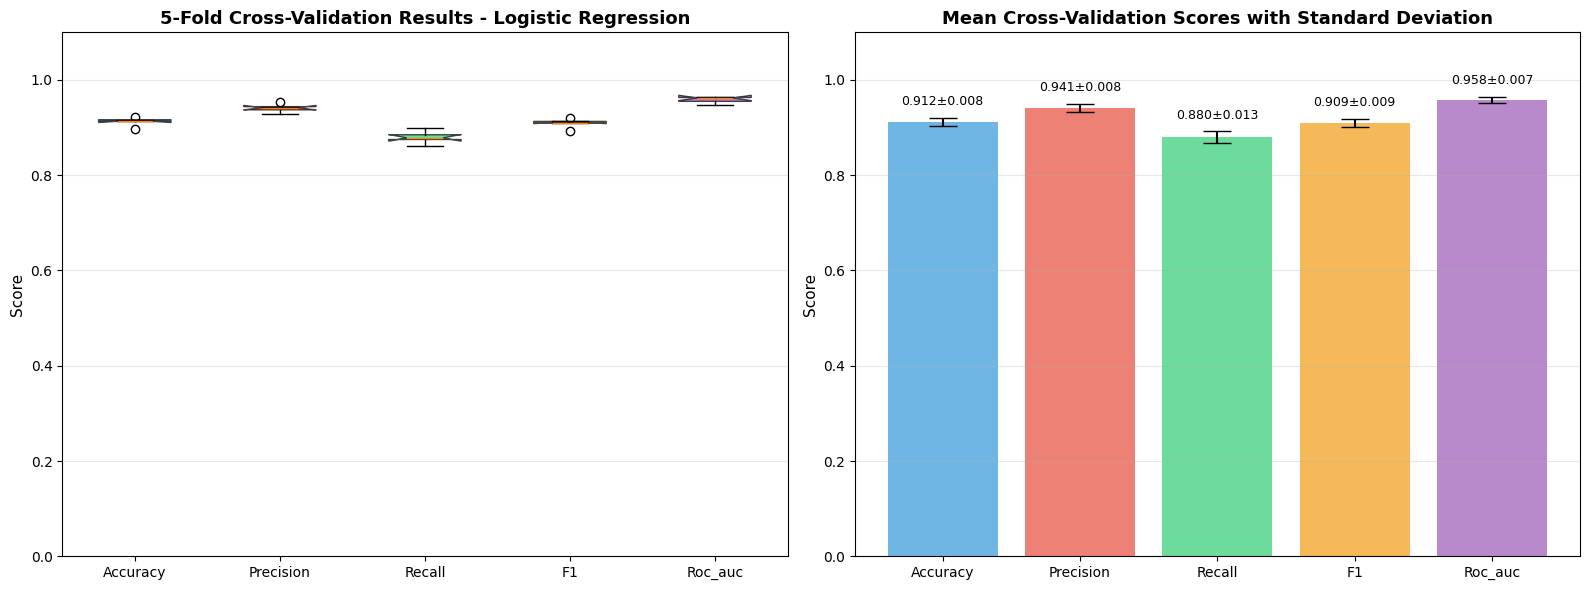


💡 Model Stability Assessment:
--------------------------------------------------------------------------------
  ✅ Average standard deviation: 0.0089
  ✅ Stability: Excellent

✓ Cross-validation completed successfully


In [38]:
# ============================================================================
# 6.4: CROSS-VALIDATION OF BEST TUNED MODEL
# ============================================================================

print("\n" + "="*80)
print(f"CROSS-VALIDATION: {best_tuned_model_name}")
print("="*80)
print("Purpose: Assess model stability and generalization capability")

# Get appropriate training data (matching what was used in grid search)
if best_tuned_model_name == 'Logistic Regression' or best_tuned_model_name == 'Support Vector Machine':
    X_train_cv = X_train_scaled_balanced
    print(f"Using scaled balanced training data for {best_tuned_model_name}")
else:  # Random Forest, XGBoost
    X_train_cv = X_train_orig_balanced
    print(f"Using original balanced training data for {best_tuned_model_name}")

y_train_cv = y_train_balanced

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Calculate scores for multiple metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print("\nRunning cross-validation...")
cv_results = {}

for metric_name, scorer in scoring.items():
    scores = cross_val_score(best_tuned_model, X_train_cv, y_train_cv, 
                            cv=cv, scoring=scorer, n_jobs=-1)
    cv_results[metric_name] = {
        'scores': scores,
        'mean': scores.mean(),
        'std': scores.std(),
        'min': scores.min(),
        'max': scores.max()
    }

# Display results
print("\n📊 Cross-Validation Results (5-Fold):")
print("-" * 80)
print(f"{'Metric':<12} {'Mean':<10} {'Std Dev':<10} {'Min':<10} {'Max':<10}")
print("-" * 80)
for metric, result in cv_results.items():
    print(f"{metric.capitalize():<12} {result['mean']:.4f}     ±{result['std']:.4f}     {result['min']:.4f}     {result['max']:.4f}")

# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Box plot of CV scores
ax1 = axes[0]
cv_data = [result['scores'] for result in cv_results.values()]
bp = ax1.boxplot(cv_data, labels=[m.capitalize() for m in cv_results.keys()], 
                 patch_artist=True, notch=True)

# Color the boxes
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_ylabel('Score', fontsize=11)
ax1.set_title(f'5-Fold Cross-Validation Results - {best_tuned_model_name}', 
             fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.1])

# Plot 2: Mean scores with error bars
ax2 = axes[1]
metrics = list(cv_results.keys())
means = [cv_results[m]['mean'] for m in metrics]
stds = [cv_results[m]['std'] for m in metrics]

bars = ax2.bar(range(len(metrics)), means, yerr=stds, 
              align='center', alpha=0.7, ecolor='black', capsize=10, 
              color=colors)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_xticks(range(len(metrics)))
ax2.set_xticklabels([m.capitalize() for m in metrics])
ax2.set_title('Mean Cross-Validation Scores with Standard Deviation', 
             fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1.1])

# Add value labels
for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + std + 0.02,
            f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("model_results/cross_validation_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Stability assessment
print("\n💡 Model Stability Assessment:")
print("-" * 80)
avg_std = np.mean([result['std'] for result in cv_results.values()])
if avg_std < 0.05:
    stability = "Excellent"
    emoji = "✅"
elif avg_std < 0.10:
    stability = "Good"
    emoji = "👍"
else:
    stability = "Moderate - Consider more data or simpler model"
    emoji = "⚠️"

print(f"  {emoji} Average standard deviation: {avg_std:.4f}")
print(f"  {emoji} Stability: {stability}")

print("\n✓ Cross-validation completed successfully")

### 6.5: Feature Importance (Final Model)


FEATURE IMPORTANCE ANALYSIS: Logistic Regression

Extracting coefficients from Logistic Regression...

📊 Top 20 Features by Coefficient Magnitude:
--------------------------------------------------------------------------------
                               Feature  Coefficient  Abs_Coefficient
   Curricular units 2nd sem (approved)    -2.754628         2.754628
   Curricular units 2nd sem (enrolled)     1.217143         1.217143
   Curricular units 1st sem (approved)    -1.014096         1.014096
               Tuition fees up to date    -0.577211         0.577211
                                Debtor     0.462370         0.462370
                                Course     0.360933         0.360933
                    Scholarship holder    -0.300991         0.300991
   Curricular units 1st sem (credited)     0.280817         0.280817
                                Gender     0.221293         0.221293
Curricular units 2nd sem (evaluations)     0.185818         0.185818
            

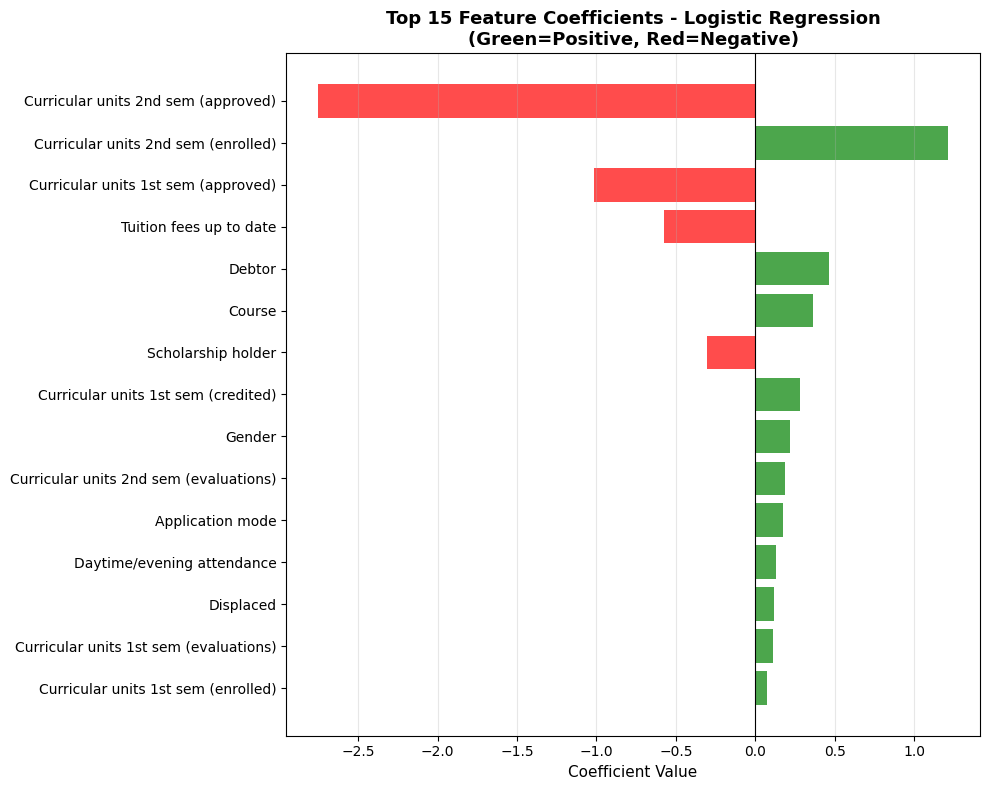


✓ Feature coefficients analysis completed


In [39]:
# ============================================================================
# 6.5: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print(f"FEATURE IMPORTANCE ANALYSIS: {best_tuned_model_name}")
print("="*80)

if hasattr(best_tuned_model, 'feature_importances_'):
    print(f"\nExtracting feature importance from {best_tuned_model_name}...")
    
    # Get feature names (use original feature names)
    feature_names = X_train_orig.columns
    
    # Get importances
    importances = best_tuned_model.feature_importances_
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\n Top 20 Most Important Features:")
    print("-" * 80)
    print(importance_df.head(20).to_string(index=False))
    
    # Categorize features
    socioeconomic = []
    academic = []
    demographic = []
    
    for feat in importance_df['Feature']:
        if any(term in feat.lower() for term in ['mother', 'father', 'qualification', 'occupation', 'scholarship', 'tuition', 'debtor']):
            socioeconomic.append(feat)
        elif any(term in feat.lower() for term in ['curricular', 'units', 'grade', 'approved', 'enrolled', 'evaluations']):
            academic.append(feat)
        elif any(term in feat.lower() for term in ['age', 'gender', 'marital', 'displaced', 'international']):
            demographic.append(feat)
    
    print(f"\n📋 Feature Importance by Category:")
    print("-" * 80)
    print(f"  Top Socioeconomic: {socioeconomic[:3] if len(socioeconomic) >= 3 else socioeconomic}")
    print(f"  Top Academic: {academic[:3] if len(academic) >= 3 else academic}")
    print(f"  Top Demographic: {demographic[:3] if len(demographic) >= 3 else demographic}")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Top 15 feature importances
    top_15 = importance_df.head(15)
    axes[0].barh(top_15['Feature'], top_15['Importance'], color='steelblue', alpha=0.8)
    axes[0].set_xlabel('Importance Score', fontsize=11)
    axes[0].set_title(f'Top 15 Feature Importances - {best_tuned_model_name}', 
                     fontsize=13, fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)
    
    # Cumulative importance
    importance_df['Cumulative'] = importance_df['Importance'].cumsum()
    axes[1].plot(range(1, len(importance_df)+1), importance_df['Cumulative'], 
                marker='o', linewidth=2, markersize=4)
    axes[1].axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
    axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% threshold')
    axes[1].set_xlabel('Number of Features', fontsize=11)
    axes[1].set_ylabel('Cumulative Importance', fontsize=11)
    axes[1].set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("model_results/feature_importance.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Save to CSV
    importance_df.to_csv("model_results/feature_importance.csv", index=False)
    
    print("\n✓ Feature importance analysis completed")
    
elif hasattr(best_tuned_model, 'coef_'):
    print(f"\nExtracting coefficients from {best_tuned_model_name}...")
    
    # Get feature names
    feature_names = X_train_scaled.columns
    
    # Get coefficients
    coefficients = best_tuned_model.coef_[0]
    
    # Create dataframe
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        'Abs_Coefficient': np.abs(coefficients)
    }).sort_values('Abs_Coefficient', ascending=False)
    
    print("\n📊 Top 20 Features by Coefficient Magnitude:")
    print("-" * 80)
    print(coef_df.head(20).to_string(index=False))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 8))
    top_15 = coef_df.head(15)
    colors_coef = ['red' if x < 0 else 'green' for x in top_15['Coefficient']]
    ax.barh(top_15['Feature'], top_15['Coefficient'], color=colors_coef, alpha=0.7)
    ax.set_xlabel('Coefficient Value', fontsize=11)
    ax.set_title(f'Top 15 Feature Coefficients - {best_tuned_model_name}\n(Green=Positive, Red=Negative)', 
                fontsize=13, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig("model_results/feature_coefficients.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Save to CSV
    coef_df.to_csv("model_results/feature_coefficients.csv", index=False)
    
    # Rename for consistency
    importance_df = coef_df.rename(columns={'Abs_Coefficient': 'Importance'})
    
    print("\n✓ Feature coefficients analysis completed")

else:
    print(f"\n⚠️  {best_tuned_model_name} does not provide feature importance or coefficients")
    importance_df = None

### 6.6: Learning Curves Analysis


LEARNING CURVE COMPARISON: ALL TUNED MODELS

Calculating learning curves for Logistic Regression...

Calculating learning curves for Support Vector Machine...

Calculating learning curves for Random Forest...

Calculating learning curves for XGBoost...


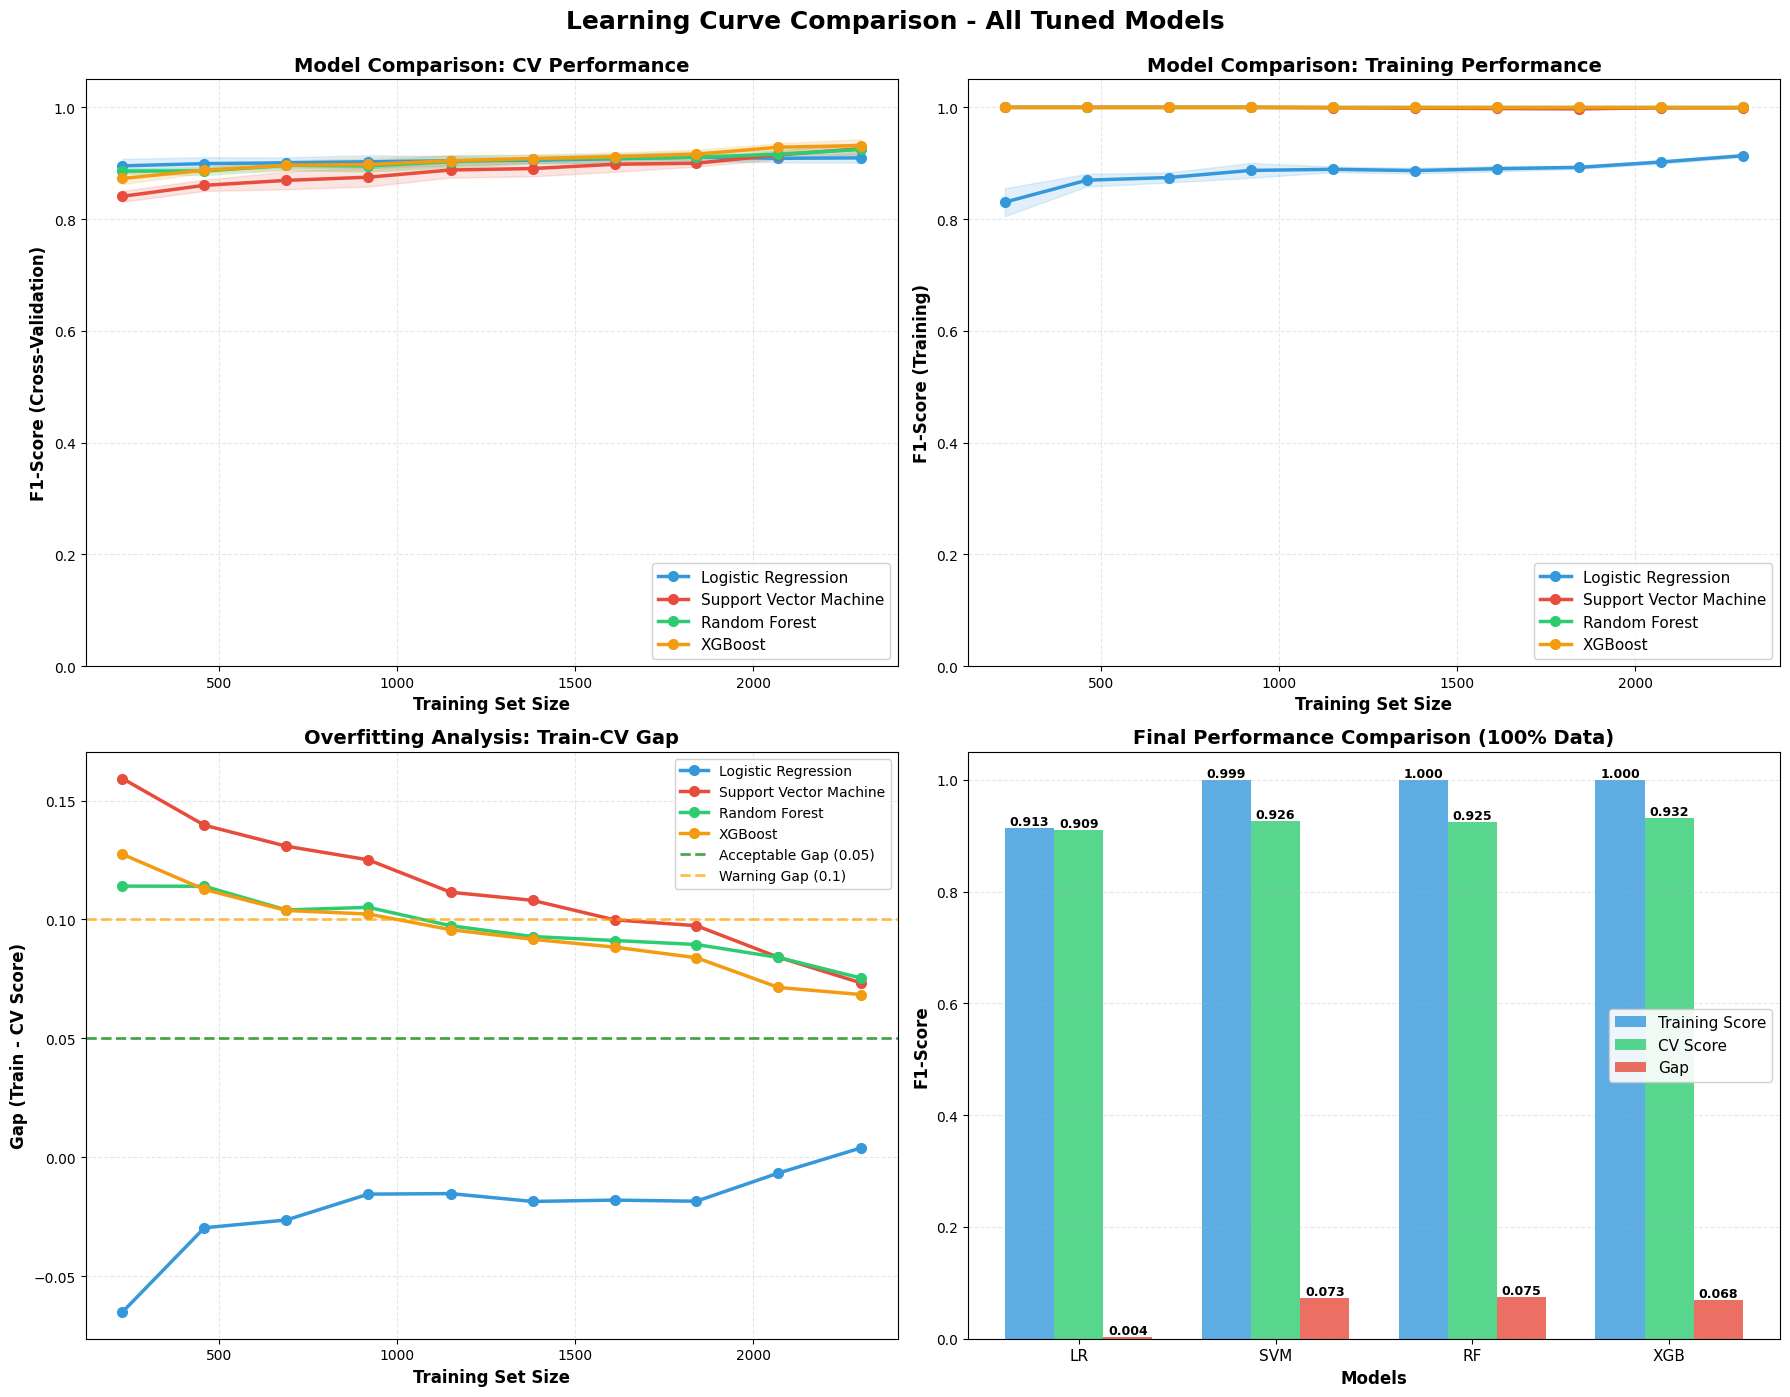

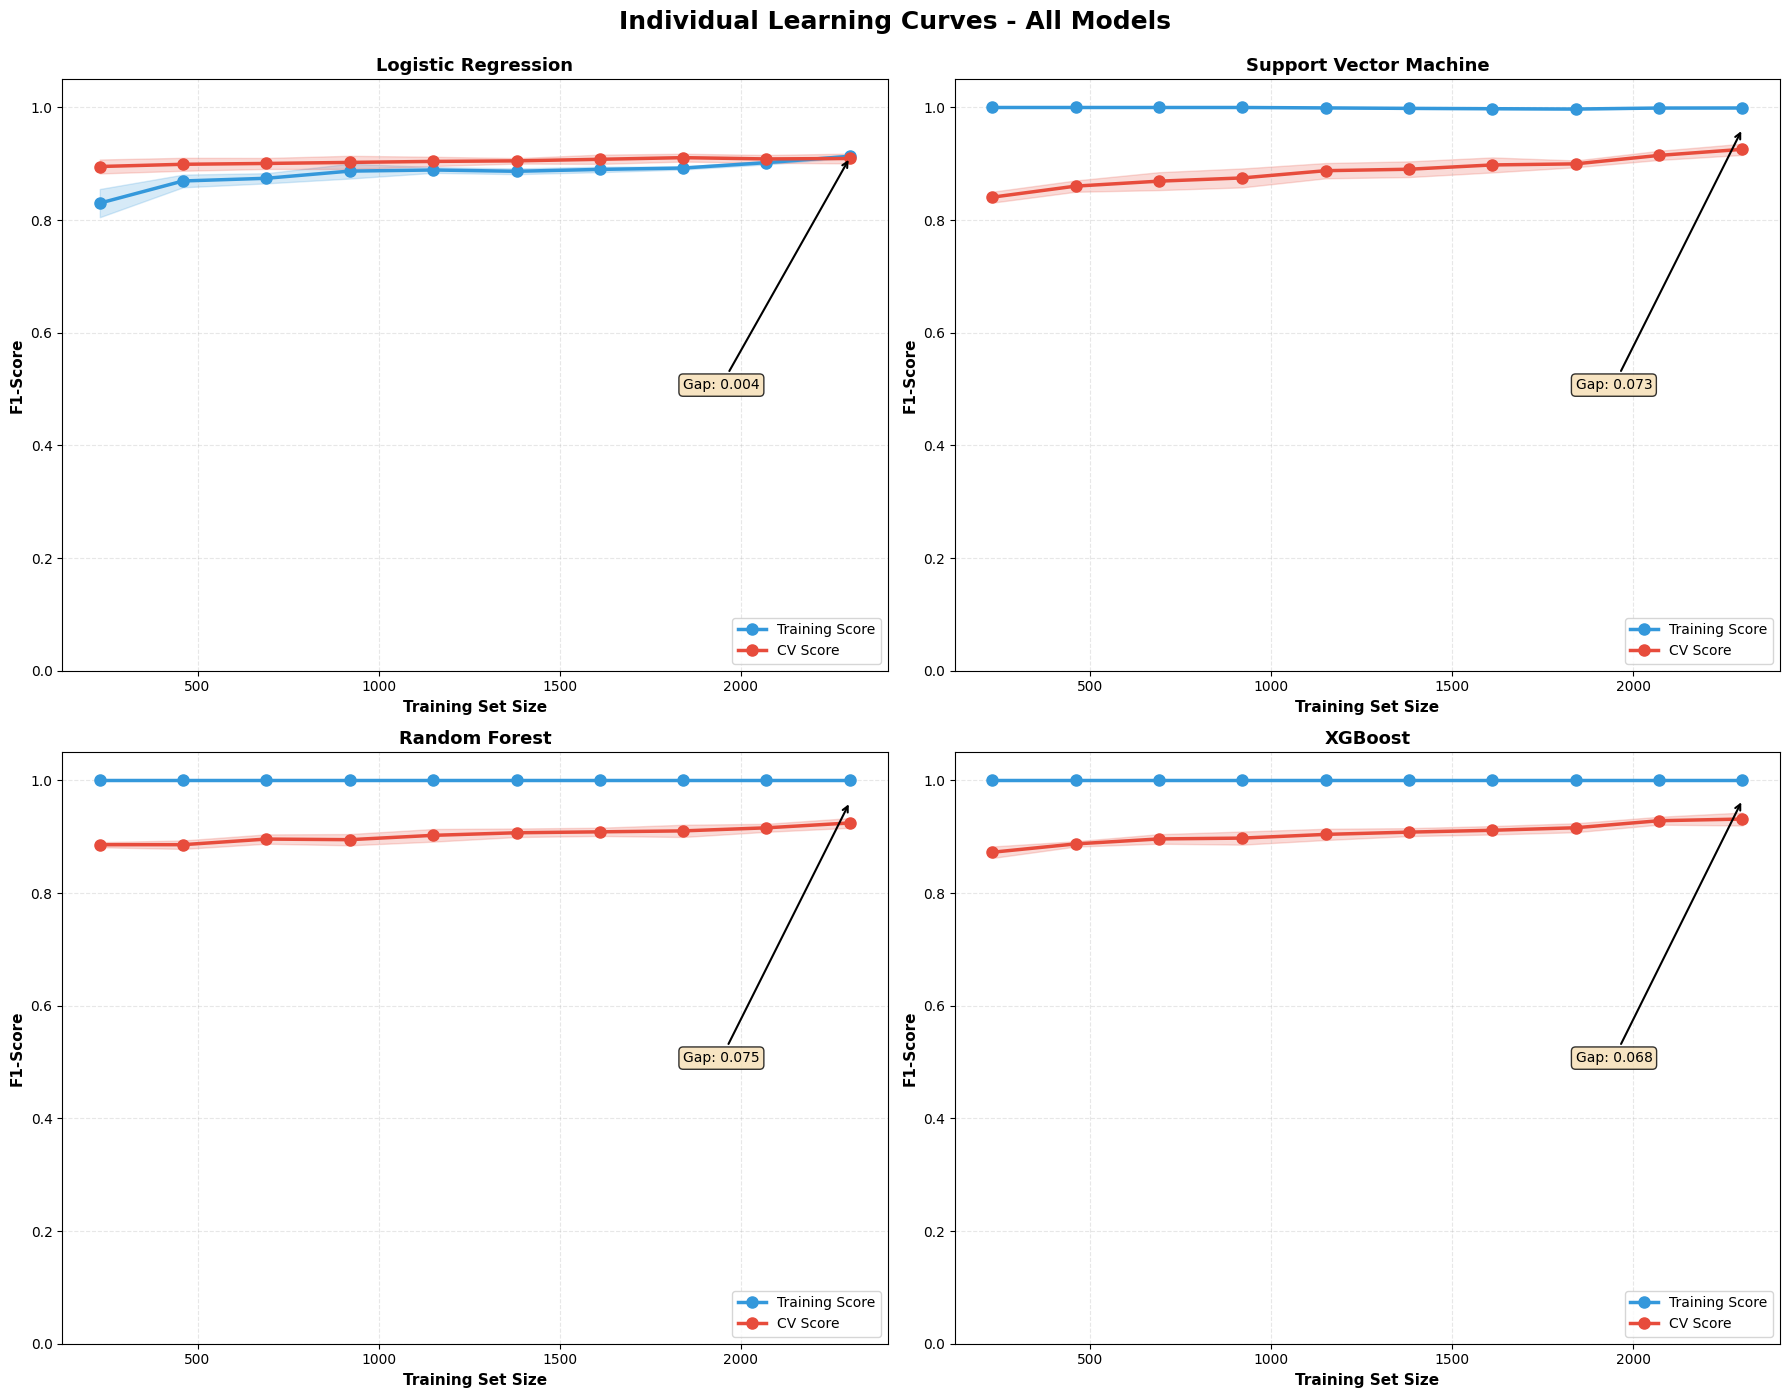


LEARNING CURVE STATISTICS - ALL MODELS

 Model Comparison Summary:
--------------------------------------------------------------------------------
                 Model  Final Train Score  Final CV Score  Train-CV Gap  Score Improvement Converged Overfitting
   Logistic Regression           0.913394        0.909455      0.003939           0.014230     ✅ Yes   Excellent
Support Vector Machine           0.999130        0.925747      0.073384           0.084994      ⏳ No        Good
         Random Forest           1.000000        0.924603      0.075397           0.038615     ✅ Yes        Good
               XGBoost           1.000000        0.931572      0.068428           0.058966     ✅ Yes        Good

BEST MODELS BY LEARNING CHARACTERISTICS

 Best CV Performance:
   Model: XGBoost
   Final CV Score: 0.9316

 Best Generalization (Lowest Gap):
   Model: Logistic Regression
   Train-CV Gap: 0.0039

 Best Learning Curve (Most Improvement):
   Model: Support Vector Machine
   Score Impr

In [40]:
# ============================================================================
# 6.6: LEARNING CURVE COMPARISON - ALL TUNED MODELS
# ============================================================================

print("\n" + "="*80)
print("LEARNING CURVE COMPARISON: ALL TUNED MODELS")
print("="*80)


# Dictionary to store results
learning_curve_comparison = {}

# Define training set sizes
train_sizes = np.linspace(0.1, 1.0, 10)

models_to_compare = {
    'Logistic Regression': (tuned_models['Logistic Regression'], X_train_scaled_balanced),
    'Support Vector Machine': (tuned_models['Support Vector Machine'], X_train_scaled_balanced),
    'Random Forest': (tuned_models['Random Forest'], X_train_orig_balanced),
    'XGBoost': (tuned_models['XGBoost'], X_train_orig_balanced)
}

# Calculate learning curves for each model
for model_name, (model, X_train_data) in models_to_compare.items():
    print(f"\nCalculating learning curves for {model_name}...")
    
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X_train_data,
        y=y_train_balanced,
        train_sizes=train_sizes,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1',
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    
    # Store results
    learning_curve_comparison[model_name] = {
        'train_sizes': train_sizes_abs,
        'train_scores': train_scores,
        'test_scores': test_scores,
        'train_mean': np.mean(train_scores, axis=1),
        'train_std': np.std(train_scores, axis=1),
        'test_mean': np.mean(test_scores, axis=1),
        'test_std': np.std(test_scores, axis=1)
    }

# ============================================================================
# VISUALIZATION 1: Combined Learning Curves
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Learning Curve Comparison - All Tuned Models', 
             fontsize=18, fontweight='bold', y=0.995)

colors = {
    'Logistic Regression': '#3498db',
    'Support Vector Machine': '#e74c3c',
    'Random Forest': '#2ecc71',
    'XGBoost': '#f39c12'
}

# Plot 1: Cross-Validation Scores Comparison
ax1 = axes[0, 0]
for model_name, results in learning_curve_comparison.items():
    ax1.plot(results['train_sizes'], results['test_mean'], 'o-', 
            color=colors[model_name], label=model_name, 
            linewidth=2.5, markersize=7)
    ax1.fill_between(results['train_sizes'], 
                     results['test_mean'] - results['test_std'],
                     results['test_mean'] + results['test_std'],
                     alpha=0.15, color=colors[model_name])

ax1.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
ax1.set_ylabel('F1-Score (Cross-Validation)', fontsize=12, fontweight='bold')
ax1.set_title('Model Comparison: CV Performance', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylim([0, 1.05])

# Plot 2: Training Scores Comparison
ax2 = axes[0, 1]
for model_name, results in learning_curve_comparison.items():
    ax2.plot(results['train_sizes'], results['train_mean'], 'o-', 
            color=colors[model_name], label=model_name, 
            linewidth=2.5, markersize=7)
    ax2.fill_between(results['train_sizes'], 
                     results['train_mean'] - results['train_std'],
                     results['train_mean'] + results['train_std'],
                     alpha=0.15, color=colors[model_name])

ax2.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1-Score (Training)', fontsize=12, fontweight='bold')
ax2.set_title('Model Comparison: Training Performance', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax2.grid(alpha=0.3, linestyle='--')
ax2.set_ylim([0, 1.05])

# Plot 3: Overfitting Gap Analysis
ax3 = axes[1, 0]
for model_name, results in learning_curve_comparison.items():
    gap = results['train_mean'] - results['test_mean']
    ax3.plot(results['train_sizes'], gap, 'o-', 
            color=colors[model_name], label=model_name, 
            linewidth=2.5, markersize=7)

ax3.axhline(y=0.05, color='green', linestyle='--', 
           label='Acceptable Gap (0.05)', linewidth=2, alpha=0.7)
ax3.axhline(y=0.1, color='orange', linestyle='--', 
           label='Warning Gap (0.1)', linewidth=2, alpha=0.7)
ax3.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
ax3.set_ylabel('Gap (Train - CV Score)', fontsize=12, fontweight='bold')
ax3.set_title('Overfitting Analysis: Train-CV Gap', fontsize=14, fontweight='bold')
ax3.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax3.grid(alpha=0.3, linestyle='--')

# Plot 4: Final Performance Comparison (Bar Chart)
ax4 = axes[1, 1]

model_names_short = ['LR', 'SVM', 'RF', 'XGB']
final_cv_scores = [learning_curve_comparison[name]['test_mean'][-1] 
                   for name in learning_curve_comparison.keys()]
final_train_scores = [learning_curve_comparison[name]['train_mean'][-1] 
                      for name in learning_curve_comparison.keys()]
final_gaps = [t - c for t, c in zip(final_train_scores, final_cv_scores)]

x = np.arange(len(model_names_short))
width = 0.25

bars1 = ax4.bar(x - width, final_train_scores, width, 
               label='Training Score', color='#3498db', alpha=0.8)
bars2 = ax4.bar(x, final_cv_scores, width, 
               label='CV Score', color='#2ecc71', alpha=0.8)
bars3 = ax4.bar(x + width, final_gaps, width, 
               label='Gap', color='#e74c3c', alpha=0.8)

ax4.set_xlabel('Models', fontsize=12, fontweight='bold')
ax4.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax4.set_title('Final Performance Comparison (100% Data)', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(model_names_short, fontsize=11)
ax4.legend(fontsize=11, framealpha=0.9)
ax4.grid(alpha=0.3, axis='y', linestyle='--')
ax4.set_ylim([0, 1.05])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("model_results/learning_curves_comparison_all_models.png", 
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 2: Individual Model Subplots (2x2 Grid)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Individual Learning Curves - All Models', 
             fontsize=18, fontweight='bold', y=0.995)

for idx, (model_name, results) in enumerate(learning_curve_comparison.items()):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Training curve
    ax.plot(results['train_sizes'], results['train_mean'], 'o-', 
           color='#3498db', label='Training Score', 
           linewidth=2.5, markersize=8)
    ax.fill_between(results['train_sizes'], 
                    results['train_mean'] - results['train_std'],
                    results['train_mean'] + results['train_std'],
                    alpha=0.2, color='#3498db')
    
    # CV curve
    ax.plot(results['train_sizes'], results['test_mean'], 'o-', 
           color='#e74c3c', label='CV Score', 
           linewidth=2.5, markersize=8)
    ax.fill_between(results['train_sizes'], 
                    results['test_mean'] - results['test_std'],
                    results['test_mean'] + results['test_std'],
                    alpha=0.2, color='#e74c3c')
    
    # Styling
    ax.set_xlabel('Training Set Size', fontsize=11, fontweight='bold')
    ax.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.05])
    
    # Add final gap annotation
    final_gap = results['train_mean'][-1] - results['test_mean'][-1]
    ax.annotate(f'Gap: {final_gap:.3f}', 
               xy=(results['train_sizes'][-1], 
                   (results['train_mean'][-1] + results['test_mean'][-1])/2),
               xytext=(results['train_sizes'][-3], 0.5),
               arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
               fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig("model_results/learning_curves_individual_all_models.png", 
            dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# STATISTICAL COMPARISON TABLE
# ============================================================================

print("\n" + "="*80)
print("LEARNING CURVE STATISTICS - ALL MODELS")
print("="*80)

comparison_data = []
for model_name, results in learning_curve_comparison.items():
    final_train = results['train_mean'][-1]
    final_cv = results['test_mean'][-1]
    final_gap = final_train - final_cv
    initial_cv = results['test_mean'][0]
    improvement = final_cv - initial_cv
    
    # Convergence check (if last two points differ by less than 0.01)
    converged = abs(results['test_mean'][-1] - results['test_mean'][-2]) < 0.01
    
    # Overfitting status
    if final_gap < 0.05:
        overfit_status = " Excellent"
    elif final_gap < 0.1:
        overfit_status = " Good"
    else:
        overfit_status = "  High"
    
    comparison_data.append({
        'Model': model_name,
        'Final Train Score': final_train,
        'Final CV Score': final_cv,
        'Train-CV Gap': final_gap,
        'Score Improvement': improvement,
        'Converged': '✅ Yes' if converged else '⏳ No',
        'Overfitting': overfit_status
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n Model Comparison Summary:")
print("-" * 80)
print(comparison_df.to_string(index=False))

# Determine best model based on learning curve characteristics
best_cv_score = comparison_df.loc[comparison_df['Final CV Score'].idxmax()]
best_generalization = comparison_df.loc[comparison_df['Train-CV Gap'].idxmin()]
best_improvement = comparison_df.loc[comparison_df['Score Improvement'].idxmax()]

print("\n" + "="*80)
print("BEST MODELS BY LEARNING CHARACTERISTICS")
print("="*80)

print(f"\n Best CV Performance:")
print(f"   Model: {best_cv_score['Model']}")
print(f"   Final CV Score: {best_cv_score['Final CV Score']:.4f}")

print(f"\n Best Generalization (Lowest Gap):")
print(f"   Model: {best_generalization['Model']}")
print(f"   Train-CV Gap: {best_generalization['Train-CV Gap']:.4f}")

print(f"\n Best Learning Curve (Most Improvement):")
print(f"   Model: {best_improvement['Model']}")
print(f"   Score Improvement: {best_improvement['Score Improvement']:.4f}")

# Overall recommendation
print("\n" + "="*80)
print("OVERALL RECOMMENDATION")
print("="*80)

# Calculate a composite score
comparison_df['Composite Score'] = (
    comparison_df['Final CV Score'] * 0.5 +  # 50% weight on CV performance
    (1 - comparison_df['Train-CV Gap']) * 0.3 +  # 30% weight on generalization
    comparison_df['Score Improvement'] * 0.2  # 20% weight on improvement
)

best_overall = comparison_df.loc[comparison_df['Composite Score'].idxmax()]

print(f"\nBest Overall Model (Composite Scoring):")
print(f"   Model: {best_overall['Model']}")
print(f"   Final CV Score: {best_overall['Final CV Score']:.4f}")
print(f"   Train-CV Gap: {best_overall['Train-CV Gap']:.4f}")
print(f"   Improvement: {best_overall['Score Improvement']:.4f}")
print(f"   Composite Score: {best_overall['Composite Score']:.4f}")

print("\n✓ Learning curve comparison completed")

# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save comparison data
comparison_df.to_csv('model_results/learning_curve_comparison.csv', index=False)
print("\n Learning curve comparison saved to 'model_results/learning_curve_comparison.csv'")

# Save detailed results as JSON
learning_curve_summary = {}
for model_name, results in learning_curve_comparison.items():
    learning_curve_summary[model_name] = {
        'final_train_score': float(results['train_mean'][-1]),
        'final_cv_score': float(results['test_mean'][-1]),
        'train_cv_gap': float(results['train_mean'][-1] - results['test_mean'][-1]),
        'score_improvement': float(results['test_mean'][-1] - results['test_mean'][0]),
        'converged': bool(abs(results['test_mean'][-1] - results['test_mean'][-2]) < 0.01)
    }

import json
with open('model_results/learning_curve_summary.json', 'w') as f:
    json.dump(learning_curve_summary, f, indent=2)

print(" Learning curve summary saved to 'model_results/learning_curve_summary.json'")

In [41]:
# ============================================================================
# 6.7: SAVE MODEL AND COMPREHENSIVE METRICS FOR STREAMLIT DEPLOYMENT
# ============================================================================

import joblib
import json
import numpy as np

print("\n" + "="*80)
print("SAVING MODEL AND METRICS FOR STREAMLIT DEPLOYMENT")
print("="*80)
print("FYP Topic: Predicting University Student Dropout Risk Using")
print("           Socioeconomic and Academic Performance Indicators")
print("="*80)

# Create directory if it doesn't exist
os.makedirs("model_results", exist_ok=True)

# ============================================================================
# 1. SAVE THE FINAL MODEL
# ============================================================================
model_filename = f"model_results/final_dropout_prediction_model.pkl"
joblib.dump(best_tuned_model, model_filename)
print(f"\n✓ Model saved: {model_filename}")

# ============================================================================
# 2. SAVE MODEL INFORMATION & METADATA
# ============================================================================
model_info = {
    'model_name': best_tuned_model_name,
    'model_type': 'tuned',
    'best_hyperparameters': tuning_results[best_tuned_model_name]['best_params'],
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'random_state': RANDOM_STATE,
    'cv_folds': 5,
    'scoring_metric': 'f1'
}

with open('model_results/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print(f"✓ Model info saved: model_results/model_info.json")

# ============================================================================
# 3. SAVE COMPREHENSIVE PERFORMANCE METRICS
# ============================================================================
# Get metrics for the best tuned model
tuned_test_metrics = all_tuned_test_metrics[best_tuned_model_name]

performance_metrics = {
    # Test Set Performance
    'test_performance': {
        'accuracy': float(tuned_test_metrics['Accuracy']),
        'precision': float(tuned_test_metrics['Precision']),
        'recall': float(tuned_test_metrics['Recall']),
        'f1_score': float(tuned_test_metrics['F1-Score']),
        'roc_auc': float(tuned_test_metrics['ROC-AUC']) if tuned_test_metrics['ROC-AUC'] else None
    },
    
    # Cross-Validation Performance
    'cv_performance': {
        'accuracy': {'mean': float(cv_results['accuracy']['mean']), 'std': float(cv_results['accuracy']['std'])},
        'precision': {'mean': float(cv_results['precision']['mean']), 'std': float(cv_results['precision']['std'])},
        'recall': {'mean': float(cv_results['recall']['mean']), 'std': float(cv_results['recall']['std'])},
        'f1_score': {'mean': float(cv_results['f1']['mean']), 'std': float(cv_results['f1']['std'])},
        'roc_auc': {'mean': float(cv_results['roc_auc']['mean']), 'std': float(cv_results['roc_auc']['std'])}
    },
    
    # Model Stability
    'stability': {
        'avg_std_deviation': float(np.mean([cv_results[m]['std'] for m in cv_results.keys()])),
        'stability_rating': 'Excellent' if np.mean([cv_results[m]['std'] for m in cv_results.keys()]) < 0.05 else 'Good' if np.mean([cv_results[m]['std'] for m in cv_results.keys()]) < 0.10 else 'Moderate'
    }
}

with open('model_results/performance_metrics.json', 'w') as f:
    json.dump(performance_metrics, f, indent=4)
print(f"✓ Performance metrics saved: model_results/performance_metrics.json")

# ============================================================================
# 4. SAVE CONFUSION MATRIX DATA
# ============================================================================
# Generate confusion matrix for the best tuned model
if best_tuned_model_name in ['Logistic Regression', 'Support Vector Machine']:
    y_pred_final = best_tuned_model.predict(X_test_scaled)
else:
    y_pred_final = best_tuned_model.predict(X_test_orig)

cm_tuned = confusion_matrix(y_test, y_pred_final)
tn_f, fp_f, fn_f, tp_f = cm_tuned.ravel()

confusion_matrix_data = {
    'true_negatives': int(tn_f),
    'false_positives': int(fp_f),
    'false_negatives': int(fn_f),
    'true_positives': int(tp_f),
    'total_samples': int(len(y_test)),
    'dropout_rate': float(tp_f / (tp_f + fn_f)) if (tp_f + fn_f) > 0 else 0,
    'graduate_rate': float(tn_f / (tn_f + fp_f)) if (tn_f + fp_f) > 0 else 0
}

with open('model_results/confusion_matrix.json', 'w') as f:
    json.dump(confusion_matrix_data, f, indent=4)
print(f"✓ Confusion matrix saved: model_results/confusion_matrix.json")

# ============================================================================
# 5. SAVE FEATURE INFORMATION
# ============================================================================
# Feature names
feature_names_list = list(X_train_orig.columns)
with open('model_results/feature_names.json', 'w') as f:
    json.dump(feature_names_list, f, indent=4)
print(f"✓ Feature names saved: model_results/feature_names.json")

# Feature importance (if available)
if importance_df is not None:
    # Save full feature importance
    importance_df.to_csv('model_results/feature_importance_full.csv', index=False)
    
    # Save top features for quick access
    top_features = {
        'top_10_features': importance_df.head(10)[['Feature', 'Importance']].to_dict('records'),
        'top_socioeconomic': [],
        'top_academic': [],
        'top_demographic': []
    }
    
    # Categorize top features
    for _, row in importance_df.iterrows():
        feat = row['Feature']
        imp = float(row['Importance'])
        
        if any(term in feat.lower() for term in ['mother', 'father', 'qualification', 'occupation', 'scholarship', 'tuition', 'debtor']):
            if len(top_features['top_socioeconomic']) < 5:
                top_features['top_socioeconomic'].append({'feature': feat, 'importance': imp})
        elif any(term in feat.lower() for term in ['curricular', 'units', 'grade', 'approved', 'enrolled', 'evaluations']):
            if len(top_features['top_academic']) < 5:
                top_features['top_academic'].append({'feature': feat, 'importance': imp})
        elif any(term in feat.lower() for term in ['age', 'gender', 'marital', 'displaced', 'international']):
            if len(top_features['top_demographic']) < 5:
                top_features['top_demographic'].append({'feature': feat, 'importance': imp})
    
    with open('model_results/top_features.json', 'w') as f:
        json.dump(top_features, f, indent=4)
    print(f"✓ Feature importance saved: model_results/feature_importance_full.csv")
    print(f"✓ Top features saved: model_results/top_features.json")

# ============================================================================
# 6. SAVE RISK THRESHOLDS FOR INTERVENTION STRATEGIES
# ============================================================================
# Calculate risk probability thresholds based on predictions
# Use ENTIRE dataset (all students) instead of just test set for risk distribution
if hasattr(best_tuned_model, 'predict_proba'):
    # Determine which dataset to use based on model type
    if best_tuned_model_name in ['Logistic Regression', 'Support Vector Machine']:
        # Use scaled data for these models
        X_all_students = X_scaled
    else:
        # Use original encoded data for tree-based models
        X_all_students = X_encoded
    
    # Predict on ALL students to get complete risk distribution
    y_pred_proba_all = best_tuned_model.predict_proba(X_all_students)[:, 1]
    
    risk_thresholds = {
        'low_risk': {
            'threshold': 0.3,
            'description': 'Students with dropout probability < 30%',
            'intervention': 'Standard support - Regular monitoring',
            'color': 'green'
        },
        'medium_risk': {
            'threshold': 0.6,
            'description': 'Students with dropout probability 30-60%',
            'intervention': 'Enhanced support - Academic counseling, tutoring',
            'color': 'orange'
        },
        'high_risk': {
            'threshold': 1.0,
            'description': 'Students with dropout probability > 60%',
            'intervention': 'Intensive intervention - Financial aid, mentoring, immediate action',
            'color': 'red'
        }
    }
    
    # Calculate distribution across risk levels
    low_risk_count = np.sum(y_pred_proba_all < 0.3)
    medium_risk_count = np.sum((y_pred_proba_all >= 0.3) & (y_pred_proba_all < 0.6))
    high_risk_count = np.sum(y_pred_proba_all >= 0.6)
    
    risk_thresholds['distribution'] = {
        'low_risk_count': int(low_risk_count),
        'medium_risk_count': int(medium_risk_count),
        'high_risk_count': int(high_risk_count),
        'low_risk_percentage': float(low_risk_count / len(y_pred_proba_all) * 100),
        'medium_risk_percentage': float(medium_risk_count / len(y_pred_proba_all) * 100),
        'high_risk_percentage': float(high_risk_count / len(y_pred_proba_all) * 100)
    }
    
    with open('model_results/risk_thresholds.json', 'w') as f:
        json.dump(risk_thresholds, f, indent=4)
    print(f"✓ Risk thresholds saved: model_results/risk_thresholds.json")

# ============================================================================
# 7. SAVE INTERVENTION RECOMMENDATIONS
# ============================================================================
intervention_strategies = {
    'academic_factors': {
        'poor_grades': [
            'Provide free tutoring services',
            'Connect with peer study groups',
            'Offer supplemental instruction',
            'Schedule regular check-ins with academic advisors'
        ],
        'low_attendance': [
            'Send automated attendance alerts',
            'Schedule meeting with counselor',
            'Identify and address underlying issues',
            'Offer flexible learning options'
        ],
        'failed_units': [
            'Provide academic recovery plan',
            'Reduce course load if necessary',
            'Offer course retake with additional support',
            'Connect with subject matter experts'
        ]
    },
    'socioeconomic_factors': {
        'financial_difficulty': [
            'Connect with financial aid office',
            'Provide scholarship opportunities',
            'Offer emergency grants',
            'Help find part-time employment',
            'Waive late payment fees'
        ],
        'tuition_debt': [
            'Set up payment plans',
            'Connect with debt counseling',
            'Provide budgeting workshops',
            'Offer work-study programs'
        ],
        'low_parental_education': [
            'Assign first-generation student mentor',
            'Provide family orientation programs',
            'Offer additional academic guidance',
            'Connect with first-gen student groups'
        ]
    },
    'demographic_factors': {
        'international_student': [
            'Provide cultural adjustment support',
            'Connect with international student office',
            'Offer language support services',
            'Facilitate peer buddy system'
        ],
        'older_student': [
            'Offer flexible scheduling',
            'Provide online course options',
            'Connect with adult learner resources',
            'Offer childcare information'
        ],
        'displaced_student': [
            'Provide housing assistance',
            'Connect with local resources',
            'Offer transportation support',
            'Facilitate community connections'
        ]
    }
}

with open('model_results/intervention_strategies.json', 'w') as f:
    json.dump(intervention_strategies, f, indent=4)
print(f"✓ Intervention strategies saved: model_results/intervention_strategies.json")

# ============================================================================
# 8. CREATE SUMMARY REPORT
# ============================================================================
summary_report = {
    'project_info': {
        'title': 'Predicting University Student Dropout Risk',
        'subtitle': 'Using Socioeconomic and Academic Performance Indicators',
        'date': pd.Timestamp.now().strftime('%Y-%m-%d'),
        'model': best_tuned_model_name
    },
    'key_findings': {
        'best_model': best_tuned_model_name,
        'test_f1_score': float(tuned_test_metrics['F1-Score']),
        'test_accuracy': float(tuned_test_metrics['Accuracy']),
        'dropout_recall': float(tuned_test_metrics['Recall']),
        'model_stability': performance_metrics['stability']['stability_rating']
    },
    'file_locations': {
        'model': model_filename,
        'metrics': 'model_results/performance_metrics.json',
        'features': 'model_results/feature_importance_full.csv',
        'risk_thresholds': 'model_results/risk_thresholds.json',
        'interventions': 'model_results/intervention_strategies.json'
    }
}

with open('model_results/summary_report.json', 'w') as f:
    json.dump(summary_report, f, indent=4)
print(f"✓ Summary report saved: model_results/summary_report.json")

# ============================================================================
# FINAL OUTPUT
# ============================================================================
print("\n" + "="*80)
print("ALL FILES SAVED FOR STREAMLIT DEPLOYMENT")
print("="*80)

print("\n📁 Files created for Streamlit App:")
print("-" * 80)
print("  CORE FILES:")
print("    1. final_dropout_prediction_model.pkl    - Trained model")
print("    2. model_info.json                       - Model metadata")
print("    3. performance_metrics.json              - Comprehensive metrics")
print("    4. confusion_matrix.json                 - Confusion matrix data")
print("    5. feature_names.json                    - Feature list")
print("\n  FEATURE ANALYSIS:")
print("    6. feature_importance_full.csv           - All feature importances")
print("    7. top_features.json                     - Top features by category")
print("\n  INTERVENTION SYSTEM:")
print("    8. risk_thresholds.json                  - Risk level definitions")
print("    9. intervention_strategies.json          - Actionable recommendations")
print("\n  REPORTING:")
print("   10. summary_report.json                   - Executive summary")

print("\n" + "="*80)
print("✅ READY FOR STREAMLIT DEPLOYMENT!")
print("="*80)

print("\n📊 Recommended Streamlit Features:")
print("-" * 80)
print("  1. Individual Student Risk Prediction")
print("     • Input student features → Get dropout probability")
print("     • Visual risk gauge (Low/Medium/High)")
print("     • Personalized intervention recommendations")
print("\n  2. Batch Student Analysis")
print("     • Upload CSV of multiple students")
print("     • Generate risk reports for entire cohort")
print("     • Export results with recommendations")
print("\n  3. Feature Importance Dashboard")
print("     • Interactive charts showing key dropout factors")
print("     • Category breakdown (Academic/Socioeconomic/Demographic)")
print("     • Insights on which factors matter most")
print("\n  4. Model Performance Metrics")
print("     • Confusion matrix visualization")
print("     • ROC curve and performance metrics")
print("     • Model confidence and stability indicators")
print("\n  5. Intervention Strategy Guide")
print("     • Risk-based intervention recommendations")
print("     • Factor-specific support strategies")
print("     • Resource allocation suggestions")
print("\n  6. Data Insights & Trends")
print("     • Historical dropout trends")
print("     • Risk distribution across student population")
print("     • Demographic and academic patterns")

print("\n💡 Additional Features to Consider:")
print("-" * 80)
print("  • What-if analysis: See how changing factors affects risk")
print("  • Early warning alerts for high-risk students")
print("  • Comparison tool: Compare multiple students side-by-side")
print("  • Export reports: Download PDFs for counselors/administrators")
print("  • Data filters: View by department, year, demographic group")
print("  • Success stories: Show intervention effectiveness")

print("\n✓ All data saved and ready for Streamlit implementation!")


SAVING MODEL AND METRICS FOR STREAMLIT DEPLOYMENT
FYP Topic: Predicting University Student Dropout Risk Using
           Socioeconomic and Academic Performance Indicators

✓ Model saved: model_results/final_dropout_prediction_model.pkl
✓ Model info saved: model_results/model_info.json
✓ Performance metrics saved: model_results/performance_metrics.json
✓ Confusion matrix saved: model_results/confusion_matrix.json
✓ Feature names saved: model_results/feature_names.json
✓ Feature importance saved: model_results/feature_importance_full.csv
✓ Top features saved: model_results/top_features.json
✓ Risk thresholds saved: model_results/risk_thresholds.json
✓ Intervention strategies saved: model_results/intervention_strategies.json
✓ Summary report saved: model_results/summary_report.json

ALL FILES SAVED FOR STREAMLIT DEPLOYMENT

📁 Files created for Streamlit App:
--------------------------------------------------------------------------------
  CORE FILES:
    1. final_dropout_prediction_mode